# Описание Проекта - Клиенты telecom-оператора

**Аннотация**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. Ставится задача — обучить на этих данных модель для прогноза оттока клиентов.

---
**Задачи исследования**

- Создать модель ML для предсказания оттока клиентов telecom-оператора.
- Решается задача бинарной классификации (класс 0/1), на выходе модели будет предсказываться вероятность оттока клиентов (вероятность принадлежности клиента к классу 1 - клиент уйдет к конкурентам).

---
**Описание исходных данных**

Данные хранятся в Sqlite — СУБД, в которой база данных представлена одним файлом. Она состоит из нескольких таблиц:
- `contract` — информация о договорах;
- `personal` — персональные данные клиентов;
- `internet` — информация об интернет-услугах;
- `phone` — информация об услугах телефонии.


*Краткое описание таблиц*

1. <u>Таблица `contract`</u>:
  - `customerID` — ID абонента;
  - `BeginDate` — дата начала действия договора;
  - `EndDate` — дата окончания действия договора;
  - `Type` — тип оплаты: раз в год-два или ежемесячно;
  - `PaperlessBilling` — электронный расчётный лист;
  - `PaymentMethod` — тип платежа;
  - `MonthlyCharges` — расходы за месяц;
  - `TotalCharges` — общие расходы абонента.

2. <u>Таблица `personal`</u>:
  - `customerID` — ID пользователя;
  - `gender` — пол;
  - `SeniorCitizen` — является ли абонент пенсионером;
  - `Partner` — есть ли у абонента супруг или супруга;
  - `Dependents` — есть ли у абонента дети.

3. <u>Таблица `internet`</u>:
  - `customerID` — ID пользователя;
  - `InternetService` — тип подключения;
  - `OnlineSecurity` — блокировка опасных сайтов;
  - `OnlineBackup` — облачное хранилище файлов для резервного копирования данных;
  - `DeviceProtection` — антивирус;
  - `TechSupport` — выделенная линия технической поддержки;
  - `StreamingTV` — стриминговое телевидение;
  - `StreamingMovies` — каталог фильмов.

4. <u>Таблица `phone`</u>:
  - `customerID` — ID пользователя;
  - `MultipleLines` — подключение телефона к нескольким линиям одновременно.

*ВАЖНО*:
Информация о договорах актуальна на 1 февраля 2020.

---
**Ход исследования**:

1. О качестве данных ничего не известно, поэтому перед тем как приступать к исследованию, проводится общий обзор данных. Проводится проверка данных на ошибки/аномалии. На этапе предобработки данных анализируются возможности исправить ошибки/аномалии в данных, так, чтобы это не привело к искажению результатов исследования.

2. Производится исследовательский и статистический анализ данных, анализируются наличие "выбросов" в данных и/или другие особенности. Производится анализ данных, по итогам которого будет сформирован набор входных признаков для моделей машинного обучения.

3. Построение модели ML: 
- построение нескольких моделей прогноза используя машинное обучение (ML):
  - случайный лес;
  - бустинг;
  - полносвязная нейронная сеть;
- целевая метрика качества задана: `ROC_AUC`, минимальный порог на валидации `0.85`;
- сравнение результатов работы моделей и выбор лучшей модели;
- выбор модели:
  - проверка/тестирование лучшей модели ML;
  - если необходимо: улучшения/доработки лучшей модели ML.

4. Анализ важности входных признаков: 
- проведение анализа важностим входных признаков;
- дополнительный анализ/визуализации по выбранному признаку.

5. Итоги и выводы:

- на лучшей модели ML предсказывается токсичность комментариев на тестовой выборке;
- делаются выводы и рекомендации, в том числе:
  - способы улучшения модели ML;
  - рекомендации для бизнеса.

---
**Таким образом, исследование будет содержать следующие шаги**:

- Загрузка данных, общий обзор таблиц;
- Предобработка данных;
- Исследовательский анализ данных (EDA);
- Формирование новых входных признаков;
- Формирование набора признаков для ML;
- Построение модели машинного обучения для предсказания вероятности ухода клиентов telecom-оператора;
- Итоговые выводы, рекомендации, мнение аналитика.

# Импорт библиотек

## Параметры окружения

In [3]:
# Выполнять ПЕРВЫМ! после запуска - перезупустить ядро.

import importlib.util

# Проверяем наличие пакетов без их импорта
tf_installed = importlib.util.find_spec("tensorflow") is not None
keras_installed = importlib.util.find_spec("keras") is not None

if tf_installed and keras_installed:
    # Оба пакета установлены — просто показываем версии
    print("TensorFlow и Keras уже установлены.")
    #print(f"   TensorFlow: {tf.__version__}")
    #print(f"   Keras:      {keras.__version__}")
    print("Можно запускать следующие ячейки с импортами.")
else:
    # Хотя бы один пакет не установлен — устанавливаем
    print("TensorFlow и/или Keras не найдены. Устанавливаем...")
    %pip install -q tensorflow keras
    print("ВНИМАНИЕ!")
    print("Пакеты только что установлены.")
    print("Чтобы Python их увидел, НУЖНО ПЕРЕЗАПУСТИТЬ ЯДРО:")
    print("  → Kernel → Restart Kernel  (или кнопка ⟳ сверху)")
    print("После перезапуска запустите эту ячейку снова")
    print("и переходите к импортам.")

TensorFlow и Keras уже установлены.
Можно запускать следующие ячейки с импортами.


## Блок импортов

In [186]:
# ---1--- общие импорты
import os
import requests
import pandas as pd
import seaborn as sns
import numpy as np
import re
import scipy.stats as stats
import warnings
import time

# Подавляем предупреждения (включая специфичные для pandas 2.0+ и phik)
warnings.filterwarnings("ignore", message=".*observed=False.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from matplotlib import pyplot as plt

# Настройка отображения float в pandas
pd.options.display.float_format = '{:,.3f}'.format

from IPython.display import HTML, display
from sqlalchemy import create_engine

print("✅ Блок 1: Общие импорты загружены успешно.")

# ---2--- импорты для моделей ML
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, make_scorer, fbeta_score, accuracy_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay, recall_score, precision_score)
from sklearn.utils.class_weight import compute_class_weight

from sklearn.ensemble import RandomForestClassifier

from sklearn.dummy import DummyClassifier

from catboost import CatBoostClassifier

# Подавляем предупреждения TensorFlow ДО его импорта
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf

# Импортируем напрямую из keras, а не из tensorflow.keras
import keras
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.optimizers import AdamW
from keras.callbacks import Callback
from keras.regularizers import l2

# Отключаем избыточные логи TensorFlow для чистоты вывода
tf.get_logger().setLevel('ERROR')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("✅ Блок 2: ML импорты загружены успешно.")
print(f"   Версия TensorFlow: {tf.__version__}")
print(f"   Версия Keras: {keras.__version__}")
print(f"   Версия NumPy: {np.__version__}")
print(f"   Версия Scikit-learn: {__import__('sklearn').__version__}")

# ---3--- прочие импорты
from phik import significance_matrix

print("✅ Блок 3: Прочие импорты (phik) загружены успешно.")

# ---4--- константы проекта
RANDOM_STATE = 170826  # фиксируем для воспроизводимости (задано в ТЗ - из даты начала проекта)
TEST_SIZE = 0.25       # размер тестовой выборки (задано в ТЗ)
# валидационной выборки нет, т.к. при обучении моделей будет применяться кросс-валидация
DATE_ACTUAL = '2020-02-01'  # дата актуальности данных в базе
DATE_PLUG = '2026-08-17'    # "заглушка" даты для действующих договоров - как дата начала проекта

print("✅ Блок 4: Константы загружены.")
print(f"   RANDOM_STATE: {RANDOM_STATE}")
print(f"   TEST_SIZE: {TEST_SIZE}")

✅ Блок 1: Общие импорты загружены успешно.
✅ Блок 2: ML импорты загружены успешно.
   Версия TensorFlow: 2.21.0
   Версия Keras: 3.15.1
   Версия NumPy: 2.5.1
   Версия Scikit-learn: 1.7.2
✅ Блок 3: Прочие импорты (phik) загружены успешно.
✅ Блок 4: Константы загружены.
   RANDOM_STATE: 170826
   TEST_SIZE: 0.25


# Вспомогательные фукнции

## Функции: анализ датасета

In [5]:
def camel_to_snake(name):
    """
    Преобразует строку из CamelCase в snake_case с помощью регулярных выражений.
    """
    # Вставляем подчеркивание перед заглавными буквами,
    # которые идут после строчных или цифр
    s1 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', name)
    # Приводим к нижнему регистру
    return s1.lower()

In [6]:
# фукнция для вывода общих данных по таблице
def get_data_summary(df):
    """
    Создает сводную таблицу с информацией о данных в DataFrame.

    Вход:
    df (pd.DataFrame): Входной DataFrame

    Выход:
    pd.DataFrame: Таблица с информацией о каждом столбце:
                  - Название поля
                  - Количество пропущенных значений
                  - Процент пропущенных значений
                  - Количество уникальных значений
                  - Тип данных
    """
    summary = pd.DataFrame(
        {
            "Название поля": df.columns,
            "Пропуски в данных, шт.": [df[col].isna().sum() for col in df.columns],
            "% пропусков": [
                (df[col].isna().sum() / len(df) * 100).round(2) for col in df.columns
            ],
            "Уникальных значений, шт.": [df[col].nunique() for col in df.columns],
            "Тип данных": [df[col].dtype for col in df.columns],
        }
    )
    return summary

In [7]:
# фукнция для первичного просмотра и анализа данных в таблице
def df_data_first_view(df,
                       head_tail=True,
                       n_head=3,
                       n_tail=3,
                       duplicates=True,
                       sub_set_exclude=None,
                       summary=True,
                       unique_non_numeric=True):
    """
    Анализирует общие данные в DataFrame

    Вход:
    df : pd.DataFrame
        DataFrame для анализа
    head_tail : bool, default=True
        Маркер вывода первых и последних строк df
    n_head, n_tail: int, default=3
        Число ваыводимых строк с начала и конца df
    duplicates : bool, default=True
        Маркер анализа и вывода статистики по явным дубликатам в df
    sub_set_exclude : list, default=None
        Списк полей, которые нужно исключить при анализе явных дубликатов в df
    summary : bool, default=True
        Маркер анализа и вывода общей статистики числовым по полям в df
    unique_non_numeric : bool, default=True
        Маркер анализа и вывода уникальных значений по нечисловым полям в df

    Возвращает:
    None (выводит отчет в Jupyter Notebook)
    """

    if head_tail:
        # первые и последние строки датасета
        n_head = max(n_head, 3)
        n_tail = max(n_tail, 3)

        print(f"Первые {n_head} и последние {n_tail} строк датасета")
        display(pd.concat([df.head(n_head), df.tail(n_tail)]))

    if summary:
        # создаем расширенную информацию о данных
        total_rows = len(df)
        non_null_counts = df.count()
        missing_counts = total_rows - non_null_counts
        unique_counts = df.nunique(dropna=False)
        dtypes_data = df.dtypes

        # итоговая таблица с информацией о данных
        extended_info = pd.DataFrame({
            'column': df.columns,
            'non-null_count': non_null_counts.values,
            'missing_count': missing_counts.values,
            'unique_count': unique_counts.values,
            'data_type': dtypes_data.values})

        # вывод расширенной информации о данных
        print('Информация о данных')
        display(extended_info)

    exclude_set = set(sub_set_exclude) if sub_set_exclude is not None else set()
    sub_set = [col for col in df.columns if col not in exclude_set]

    if duplicates:
        # подсчет числа и вывод на экран явных дубликатов
        total_duplicates = df.duplicated(subset=sub_set).sum()

        # считаем все строки, которые являются дубликатами (повторяются 2 и более раз)
        mask = df.duplicated(subset=sub_set, keep=False)
        total_duplicate_rows = mask.sum()

        if total_duplicates == 0:
            print(f'Явных дубликатов без учета полей {sub_set_exclude} нет')
        else:
            print(f'Анализ на дубликаты ВНЕ набора {sub_set_exclude}:')
            print(f'Число дубликатов (для для возможного удаления)             : {total_duplicates} шт.')
            print(f'Общее число дублирующихся строк (повторяются 2 и более раз): {total_duplicate_rows} шт.')

    # блок для вывода уникальных значений по нечисловым полям
    if unique_non_numeric:
        print("\n--- Уникальные значения для нечисловых полей ---")
        non_numeric_columns = df.select_dtypes(
            exclude=["number", "datetime", "timedelta"]
        ).columns
        if len(non_numeric_columns) == 0:
            print("Нечисловые столбцы отсутствуют.")
        else:
            for col in non_numeric_columns:
                unique_values = df[col].unique()
                print(f"\nСтолбец: '{col}'")
                print(f"Количество уникальных значений: {len(unique_values)}")
                missing_count = df[col].isna().sum()
                print(f"Число пропусков: {missing_count} шт.")
                print(f"Уникальные значения: {list(unique_values)}")
                result = df[col].value_counts(dropna=False).reset_index()
                result.columns = ['уникальное значение', 'число таких значений']
                result["% от общего числа записей"] = (
                    result["число таких значений"]
                    / result["число таких значений"].sum()
                    * 100
                ).round(2)
                display(result)
    return

In [8]:
# анализ пропусков в датасете
def analyze_missing_values(df,
                           show_only_missing=True,
                           cmap='Reds',
                           round_percent=2,
                           caption='Отчет о пропущенных значениях'):
    """
    Анализирует и визуализирует пропущенные значения в DataFrame

    Вход:
    df : pd.DataFrame
        DataFrame для анализа
    show_only_missing : bool, default=True
        Показывать только колонки с пропусками
    cmap : str, default='Reds'
        Цветовая карта для градиентного оформления
    round_percent : int, default=2
        Количество знаков после запятой для процентов
    caption : str, default='Отчет о пропущенных значениях'
        Заголовок таблицы

    Возвращает:
    None (выводит отчет в Jupyter Notebook)
    """
    # Подсчет пропущенных значений
    missing_data = df.isna().sum().sort_values(ascending=False)
    missing_percent = (missing_data / len(df)) * 100

    # Создание отчета
    missing_report = pd.DataFrame({
        'Пропущено, шт': missing_data,
        'Доля пропусков, %': missing_percent.round(round_percent)
    })

    # Фильтрация колонок с пропусками (если нужно)
    if show_only_missing:
        missing_report = missing_report[missing_report['Пропущено, шт'] > 0]
        if missing_report.empty:
            print("✅ Пропущенных значений не обнаружено!")
            return

    # Форматирование вывода
    print(f"Всего строк в датасете: {len(df):,}")
    print(f"Всего колонок: {df.shape[1]}")

    # Вывод в виде таблицы с сортировкой по убыванию процента пропусков
    display(
        missing_report.style.format(
            {
                "Пропущено, шт": "{:,.0f}",
                "Доля пропусков, %": f"{{:.{round_percent}f}}%",
            }
        )
        .background_gradient(cmap=cmap, subset=["Доля пропусков, %"])
        .set_caption(f"<b>{caption}</b>")
        .set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("color", "darkgreen"),
                        ("font-size", "12px"),
                        ("font-weight", "bold"),
                        ("text-align", "left"),
                    ],
                },
                {"selector": "th", "props": [("text-align", "right")]},
                {"selector": "td", "props": [("text-align", "right")]},
            ]
        )
    )
    return

In [9]:
def show_category_stats(df,
                        column,
                        title="Имя категории",
                        dropna=False,
                        return_df=False,
                        n_top=None,
                        min_share=None,
                        cumulative_threshold=None):
    """
    Функция для анализа категориальных данных
    с возможностью отсечки малозначимых категорий.

    Параметры:
    -----------
    df : pd.DataFrame
        Исходный датафрейм
    column : str
        Имя анализируемой колонки
    title : str, optional (default="Имя категории")
        Заголовок таблицы результата
    dropna : bool, optional (default=False)
        Учитывать ли пропущенные значения (NaN) как отдельную категорию
    return_df : bool, optional (default=False)
        Возвращать ли DataFrame вместо отображения таблицы на экране
    n_top : int, optional (default=None)
        Максимальное количество строк для отображения (ТОП-N)
    min_share : float, optional (default=None)
        Минимальная доля категории для отображения (0-1)
    cumulative_threshold : float, optional (default=None)
        Порог накопленной доли (0-1), после достижения которого остальные категории объединяются

    Возвращает:
    ------------
    pd.DataFrame или None
        DataFrame с результатами (если return_df=True),
        иначе выводит таблицу с результатами

    Примечание:
    -----------
    Можно использовать только один параметр отсечки одновременно
    (n_top, min_share или cumulative_threshold).
    Если задано несколько параметров отсечки, будет использован первый приоритетный
    (n_top > min_share > cumulative_threshold).
    """
    # Проверка существования колонки
    if column not in df.columns:
        raise ValueError(f"Колонка '{column}' не найдена в датафрейме")

    # Проверка конфликта параметров отсечки
    cut_methods = [n_top, min_share, cumulative_threshold]
    if sum(x is not None for x in cut_methods) > 1:
        print("Внимание: задано несколько параметров отсечки. Используется приоритет: n_top > min_share > cumulative_threshold")

    # Расчет статистики с учетом параметра dropna
    stats = (
        df[column]
        .value_counts(normalize=True, dropna=dropna)
        .sort_values(ascending=False)
        .to_frame('Доля')
    )
    stats['Накопленная доля'] = stats['Доля'].cumsum()

    # Применение отсечки (если задано)
    if n_top is not None:
        if n_top < 1:
            raise ValueError("n_top должно быть положительным целым числом")
        if len(stats) > n_top:
            top_stats = stats.iloc[:n_top]
            others_share = stats.iloc[n_top:]['Доля'].sum()
            # Создаем строку all_others
            others_row = pd.DataFrame({
                'Доля': [others_share],
                'Накопленная доля': [top_stats['Накопленная доля'].iloc[-1] + others_share]
            }, index=['all_others'])
            stats = pd.concat([top_stats, others_row])

    elif min_share is not None:
        if not (0 <= min_share <= 1):
            raise ValueError("min_share должен быть в диапазоне от 0 до 1")
        mask = stats['Доля'] >= min_share
        if mask.any():
            top_stats = stats[mask]
            others_share = stats[~mask]['Доля'].sum()
            if others_share > 0:
                last_cumulative = top_stats['Накопленная доля'].iloc[-1]
                others_row = pd.DataFrame({
                    'Доля': [others_share],
                    'Накопленная доля': [last_cumulative + others_share]
                }, index=['all_others'])
                stats = pd.concat([top_stats, others_row])
            else:
                stats = top_stats

    elif cumulative_threshold is not None:
        if not (0 <= cumulative_threshold <= 1):
            raise ValueError("cumulative_threshold должен быть в диапазоне от 0 до 1")
        mask = stats['Накопленная доля'] <= cumulative_threshold
        if mask.any():
            top_stats = stats[mask]
            others_share = stats[~mask]['Доля'].sum()
            if others_share > 0:
                last_cumulative = top_stats['Накопленная доля'].iloc[-1]
                others_row = pd.DataFrame({
                    'Доля': [others_share],
                    'Накопленная доля': [last_cumulative + others_share]
                }, index=['all_others'])
                stats = pd.concat([top_stats, others_row])
            else:
                stats = top_stats

    # Форматирование и отображение
    styled = stats.style.format({
        'Доля': '{:.2%}',
        'Накопленная доля': '{:.2%}'
    }).set_caption(f"Статистика по {title}")

    if return_df:
        return stats
    else:
        display(styled)
        return None

## Функции: визуализации данных

In [10]:
def plot_cat_freq(df, cols, figsize=(6, 4)):
    """
    Отображает распределение категориальных переменных через seaborn

    Параметры:
    df : DataFrame - данные
    cols : list - список категориальных колонок в df для анализа
    figsize : tuple - размер графика
    """
    for col in cols:
        # Заменяем пропуски на строку 'N/A' перед подсчетом
        df_plot = df.copy()
        df_plot[col] = df_plot[col].fillna('N/A')

        plt.figure(figsize=figsize)
        counts = df_plot[col].value_counts()  #считаем из измененного df
        total = counts.sum()

        ax = sns.countplot(
            data=df_plot,  # измененный df
            y=col,
            order=counts.index,
            color='skyblue',
            edgecolor='grey'
        )

        # Увеличиваем предел оси X на 25% для размещения процентов
        max_count = counts.max()
        ax.set_xlim(0, max_count * 1.25)

        # Добавляем проценты к каждому бару
        for p in ax.patches:
            width = p.get_width()
            percent = (width / total) * 100
            ax.text(
                width * 1.02,  # Позиционируем относительно ширины бара
                p.get_y() + p.get_height()/2,
                f'{percent:.1f}%',
                ha='left',
                va='center',
                fontsize=7
            )

        plt.title(f'Распределение переменной:\n{col}', fontsize=9)
        plt.xlabel('Количество, шт.', fontsize=8)
        plt.ylabel('')
        plt.yticks(fontsize=7)
        plt.xticks(fontsize=7)
        plt.tight_layout(rect=[0.2, 0, 1, 0.95])
        plt.show()

In [11]:
def hist_kde_box_show_new(
    df_name, df, col, bins=50, g_h=3, g1_w=3, g2_w=2, units=None, fontsize=10
):
    """
    Строит два совмещенных графика: гистограмму плотности с KDE и boxplot.

    Параметры:
    -----------
    df_name : str
        Название таблицы для отображения в заголовке
    df : pd.DataFrame
        Исходный датафрейм с данными
    col : str
        Имя колонки для анализа
    bins : int или str, optional (default=50)
        Количество бинов для гистограммы. Если None - рассчитывается автоматически
    g_h : float, optional (default=3)
        Высота всего графического окна
    g1_w : float, optional (default=3)
        Ширина левого графика (гистограмма с KDE)
    g2_w : float, optional (default=2)
        Ширина правого графика (boxplot)
    units : str, optional (default=None)
        Единицы измерения для осей координат
    fontsize : int, optional (default=10)
        Базовый размер шрифта для текстовых элементов

    Возвращает:
    ------------
    None
        Отображает график
    """
    # Построим сетку для графиков
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(g1_w + g2_w, g_h),
        gridspec_kw={'width_ratios': [g1_w, g2_w]}
    )

    # Очищаем данные от NaN
    ser = df[col]
    clean_data = ser.dropna()
    if len(clean_data) == 0:
        print("Нет данных для отображения.")
        return

    num_unique = clean_data.nunique(dropna=True)

    # Единообразный расчет бинов на основе уникальных значений
    if num_unique <= 25:
        bins = num_unique  # Дискретные данные - бины = уникальным значениям
    elif num_unique <= 100:
        bins = max(2, num_unique // 5)  # Для умеренного числа уникальных
    else:
        if bins is None:
            bins = 'auto'  # Автоматический расчет для непрерывных данных

    my_font_size = fontsize

    # Левый график - гистограмма с KDE через seaborn
    kde_show = (num_unique > 30) and (len(clean_data) > 1)

    # Построение гистограммы средствами seaborn
    sns.histplot(
        clean_data,
        ax=ax1,
        stat='density',
        bins=bins,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )

    # KDE строим отдельно через kdeplot
    if kde_show:
        sns.kdeplot(
            clean_data,
            ax=ax1,
            color='navy',
            linewidth=1.5,
            label='KDE'
        )

    # Добавляем медиану
    median_val = np.median(clean_data)
    ax1.axvline(median_val, color='g', linestyle='--', linewidth=1.5,
                label=f'Медиана = {median_val:.1f}')

    ax1.set_title('Распределение', fontsize=my_font_size-1)
    ax1.set_xlabel(units, fontsize=my_font_size-1)
    ax1.set_ylabel('Плотность', fontsize=my_font_size-1)
    ax1.tick_params(axis='both', which='major', labelsize=my_font_size-3)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=my_font_size-3, framealpha=0.7)

    # Правый график - боксплот
    ax2.boxplot(clean_data, vert=False, showfliers=True)
    ax2.set_title('BoxPlot', fontsize=my_font_size-1)
    ax2.set_yticklabels([])
    ax2.set_xlabel(units, fontsize=my_font_size-1)
    ax2.tick_params(axis='both', which='major', labelsize=my_font_size-3)
    ax2.grid(True, alpha=0.3)

    fig.suptitle(f"Таблица: {df_name}\nПеременная: {col}", fontsize=my_font_size)

    plt.tight_layout()
    plt.show()
    return

In [12]:
def plot_bar_and_line_chart(df, x_col, bar_y_col, line_y_col,
                            title, bar_y_label, line_y_label, x_label,
                            x_rot=0, decimals=0, line_decimals=0, line_offset=0.01,
                            figsize=(6, 4)):
    """
    Строит столбчатую диаграмму с частотами и линейный график с долями на одном графике.

    Вход:
    - df: DataFrame с данными (должен содержать x_col, bar_y_col, line_y_col).
    - x_col: Название столбца для оси X (категории).
    - bar_y_col: Название столбца для значений оси Y для столбцов (частоты).
    - line_y_col: Название столбца для значений оси Y для линии (доли).
    - title: Заголовок графика.
    - bar_y_label: Подпись оси Y для столбцов.
    - line_y_label: Подпись оси Y для линии.
    - x_label: Подпись оси X.
    - x_rot: Угол поворота подписей для оси X.
    - decimals: Число знаков после запятой для подписей значений столбцов.
    - line_decimals: Число знаков после запятой для подписей значений линии.
    - line_offset: Смещение подписей линии по вертикали вверх относительно точек.
    - figsize: Размер фигуры (ширина, высота).

    Выход:
    - Строит двойной график (столбцы и линия) с подписями значений.
    """
    fig, ax1 = plt.subplots(figsize=figsize)

    # Цвета
    bar_color = 'steelblue'
    line_color = 'darkred'

    x_values = df[x_col].astype(str)

    # Построение баров
    bars = ax1.bar(x_values, df[bar_y_col], alpha=0.7,
                   color=bar_color, label=bar_y_label)
    ax1.set_xlabel(x_label, fontsize=8)
    ax1.set_ylabel(bar_y_label, fontsize=8)
    ax1.tick_params(axis='x', rotation=x_rot, labelsize=7)
    ax1.tick_params(axis='y', labelsize=7)
    ax1.set_ylim(0, 1.0)

    # Подписи значений над барами (чуть выше горизонтальной оси)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2., 0.005,
                 f'{bar.get_height():.{decimals}f}',
                 ha='center', va='bottom', fontsize=7)

    # Создание второй оси Y для линейного графика
    ax2 = ax1.twinx()
    # ИЗМЕНЕНИЕ: используем x_values вместо df[x_col]
    line_points = ax2.plot(x_values, df[line_y_col], color=line_color,
                           marker='o', linestyle='-',
                           label=line_y_label, markersize=3)
    ax2.set_ylabel(line_y_label, fontsize=8)
    ax2.tick_params(axis='y', labelsize=7)
    ax2.set_ylim(0, 0.5)

    # Подписи значений точек линии с вертикальным смещением
    for i, (x_pos, y_val) in enumerate(zip(x_values, df[line_y_col])):
        ax2.text(i, y_val + line_offset, f'{y_val:.{line_decimals}f}',
                 ha='center', va='bottom', fontsize=7, color=line_color)


    # Настройка заголовка
    plt.title(title, fontsize=9)

    # Сетка только для левой оси Y (ax1)
    ax1.grid(axis='y', linestyle='-', alpha=0.3)

    # Легенда сверху справа за пределами графика
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # Объединяем линии/элементы для общей легенды
    all_lines = lines_1 + lines_2
    all_labels = labels_1 + labels_2
    # Размещаем легенду сверху справа
    ax1.legend(all_lines, all_labels, loc='upper left',
               bbox_to_anchor=(1.1, 1.05), fontsize=7)

    # Увеличиваем отступ справа и сверху, чтобы вместить легенду
    plt.subplots_adjust(right=0.8, top=0.95)

    plt.tight_layout()
    plt.show()

## Функции: анализ корреляций

In [13]:
# функция вывода матрицы - тепловая карта
def heatmap_show(df, graph_title, figsize=(10, 8), font_size=8,
                 cmap='Reds', show_upper_triangle=False,
                 vmin=0, vmax=1):
    plt.figure(figsize=figsize)

    # Создаем маску для верхней треугольной части
    if not show_upper_triangle:
        mask = np.triu(np.ones_like(df, dtype=bool), k=1)
    else:
        mask = None

    sns.heatmap(
        df,
        annot=True,
        cmap=cmap,
        fmt='.2f',
        linewidths=0.5,
        annot_kws={"size": font_size},
        cbar_kws={"shrink": 0.8},
        mask=mask,
        vmin=vmin,   # минимальное значение шкалы
        vmax=vmax    # максимальное значение шкалы
    )
    plt.title(graph_title, fontsize=font_size+4)
    plt.xticks(fontsize=font_size, rotation=90, ha='right')
    plt.yticks(fontsize=font_size)
    plt.tight_layout()
    plt.show()

In [14]:
# функция интерпретации корреляций и p-value
def corr_interpretation (row):
    corr = row['phi_k']
    p_value = row['p_value']
    if corr < 0.1:
        dependence = 'очень слабая'
    elif corr < 0.3:
        dependence = 'слабая'
    elif corr < 0.5:
        dependence = 'умеренная'
    elif corr < 0.7:
        dependence = 'сильная'
    elif corr < 1.0:
        dependence = 'очень сильная'
    else:
        dependence = 'функциональная'
    significance = 'значимая' if p_value < 0.05 else 'не значимая'
    return dependence, significance

## Функции: визуализации качества прогноза

In [15]:
def class_quality_analize(
    y_true, y_pred_proba, opt_threshold,
    figsize=(12, 4), suptitle_y=1.0,
    suptitle='Метрики качества модели'
):
    """
    Строит основные графики качества модели классификации.

    Параметры:
    -----------
    y_true : array-like
        Истинные метки классов для валидационной выборки.
    y_pred_proba : array-like
        Предсказанные вероятности положительного класса (class 1).
    figsize : tuple, optional (по умолчанию (12, 4))
        Размер общего холста (ширина, высота) для всех трех графиков.
    suptitle_y : float, optional (по умолчанию 1.0)
        Вертикальное положение общего заголовка фигуры.
    suptitle : str, optional
        Текст общего заголовка фигуры.

    Возвращаемое значение:
    ----------------------
    None
        Функция выводит matplotlib-график.
    """
    # Подготовка данных
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    roc_auc_val = auc(fpr, tpr)

    y_pred_binary = (y_pred_proba >= opt_threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_binary)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_pred_proba)
    avg_prec = average_precision_score(y_true, y_pred_proba)

    # Создание фигуры с тремя подграфиками
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=figsize)

    # 1. ROC-кривая
    ax1 = axes[0]
    ax1.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC-кривая (AUC = {roc_auc_val:.4f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2,
             linestyle='--', label='Случайная классификация')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('Доля ложно-положительных\n(FPR)', fontsize=8)
    ax1.set_ylabel('Доля истинно-положительных\n(TPR)', fontsize=8)
    ax1.set_title('ROC-кривая', fontsize=10)
    ax1.legend(loc="lower right", fontsize=7)
    ax1.grid(True)

    # 2. Нормализованная матрица ошибок
    ax2 = axes[1]
    disp_percent = ConfusionMatrixDisplay(confusion_matrix=cm_percent,
                                          display_labels=['0', '1'])
    disp_percent.plot(ax=ax2, cmap=plt.cm.Blues, values_format='.1%')
    for text in ax2.texts:
        if any(c.isdigit() or c == '.' for c in text.get_text()):
            text.set_fontsize(8)
    ax2.set_title('Нормализованная матрица ошибок', fontsize=10)
    ax2.set_xlabel('Предсказанный класс', fontsize=8)
    ax2.set_ylabel('Истинный класс', fontsize=8)

    # 3. Кривая Precision-Recall
    ax3 = axes[2]
    ax3.step(recall, precision, color='b', alpha=0.2,
             where='post', label=f'PR-кривая (AP = {avg_prec:.4f})')
    ax3.fill_between(recall, precision, step='post', alpha=0.2, color='navy')
    ax3.set_xlabel('Recall', fontsize=8)
    ax3.set_ylabel('Precision', fontsize=8)
    ax3.set_title('Кривая Precision-Recall', fontsize=10)
    ax3.legend(fontsize=7)
    ax3.grid(True)

    # Общий заголовок
    fig.suptitle(suptitle, fontsize=12, y=suptitle_y)

    plt.tight_layout()
    plt.show()

# Общий обзор базы данных

## Подключение к базе

In [16]:
# Определяем путь к файлу базы данных
db_filename = 'ds-plus-final.db'
directory = 'dbase/'
path_to_db = os.path.join(directory, db_filename)

# Проверяем, существует ли файл в директории /dbase
if not os.path.exists(path_to_db):
    print(f"Файл {db_filename} не найден в директории {directory}.")
    print("Загружаем файл...")

    url = 'https://code.s3.yandex.net/data-scientist/ds-plus-final.db'
    response = requests.get(url)

    if response.status_code == 200:
        # Сохраняем файл в текущую директорию (как в вашем исходном коде)
        with open(db_filename, 'wb') as f:
            f.write(response.content)

        # Обновляем путь к файлу в текущей директории
        path_to_db = db_filename

        # === КРИТИЧЕСКАЯ ПРОВЕРКА ===
        file_size = os.path.getsize(path_to_db)
        print(f"Файл успешно загружен. Размер: {file_size} байт.")

        if file_size < 5000:  # Настоящая БД весит значительно больше
            print("\nВНИМАНИЕ: Размер файла подозрительно мал!")
            print("Скорее всего, вместо базы данных скачалась HTML-страница с ошибкой.")
            print("Начало содержимого файла:")
            with open(path_to_db, 'r', encoding='utf-8', errors='ignore') as f:
                print(f.read(300))  # Покажем первые 300 символов
    else:
        print(f"❌ Ошибка загрузки! Код ответа сервера: {response.status_code}")
        print("Проверьте правильность ссылки или доступность ресурса.")
else:
    print(f"Файл {db_filename} найден в директории {directory}. Используем существующий файл.")

# Создаем движок для подключения к базе данных
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)
print(f"\nСоздан движок для подключения к базе по адресу: sqlite:///{path_to_db}")

Файл ds-plus-final.db не найден в директории dbase/.
Загружаем файл...
Файл успешно загружен. Размер: 3588096 байт.

Создан движок для подключения к базе по адресу: sqlite:///ds-plus-final.db


Выведем список таблиц в базе данных

In [17]:
# Запрос для получения списка таблиц в SQLite
try:
    user_tables_df = pd.read_sql_query(
        "SELECT name AS table_name FROM sqlite_master WHERE type='table';",
        con=engine
    )
    user_tables_list = user_tables_df['table_name'].tolist()
    print(f"Список названий таблиц в базе данных:\n{user_tables_list}")

    if not user_tables_list:
        print("\nСписок таблиц пуст. Файл поврежден или не является валидной SQLite базой.")
except Exception as e:
    print(f"\nОшибка при чтении базы данных: {e}")

Список названий таблиц в базе данных:
['data_arc', 'data_bulk', 'data_bulk_time', 'data_wire_time', 'contract', 'personal', 'phone', 'internet', 'data_gas', 'data_temp', 'data_wire']


Как видим:
- в базе данных 11 таблиц;
- нас интересуют только 4 таблицы из 11: 'contract', 'personal', 'phone', 'internet'.

Посмотрим на список внешних ключей в нужных нам таблицах.

In [18]:
# список нужных таблиц
tables_work = ['contract', 'personal', 'phone', 'internet']

# словарь для хранения информации о внешних ключах
foreign_keys_info = {}

for table in tables_work:
    # Запрос для получения информации о внешних ключах для каждой таблицы
    fk_query = f"""
    PRAGMA foreign_key_list(`{table}`);
    """
    try:
        fk_df = pd.read_sql_query(fk_query, con=engine)
        if not fk_df.empty:
            foreign_keys_info[table] = fk_df
            print(f"Внешние ключи в таблице '{table}':")
            print(fk_df.to_string(index=False))
        else:
            print(f"В таблице '{table}' нет внешних ключей.")
    except Exception as e:
        print(f"Ошибка при получении внешних ключей для таблицы '{table}': {e}")

В таблице 'contract' нет внешних ключей.
В таблице 'personal' нет внешних ключей.
В таблице 'phone' нет внешних ключей.
В таблице 'internet' нет внешних ключей.


Теперь выводим список полей их типы и прочие данные по нужным нам таблицам.

In [19]:
# выводим данные по каждой таблице
for table_name in tables_work:
    try:
        # Запрос к sqlite_master для получения информации о столбцах
        query = f"PRAGMA table_info(`{table_name}`);"
        pragma_df = pd.read_sql_query(query, con=engine)

        # Создаем DataFrame для текущей таблицы, основываясь на результате PRAGMA
        table_df = pd.DataFrame({
            'column_name': pragma_df['name'],
            'data_type': pragma_df['type'].str.lower(),  # типы данных
            'nullable': ~pragma_df['notnull'],  # если notnull=1, то nullable=False
            'default_value': pragma_df['dflt_value'],  # значение по умолчанию
            'primary_key': pragma_df['pk']  # является ли частью первичного ключа
        })#[['column_name', 'data_type', 'nullable']]  # оставляем только нужные столбцы

        display(HTML("<hr style='border-color: green; border-width: 2px;'>"))
        display(HTML(f"<b><font color='green'>Таблица: {table_name}</font></b>"))
        display(table_df)

    except Exception as e:
        print(f"Ошибка при получении колонок для таблицы {table_name}: {e}")

,column_name,data_type,nullable,default_value,primary_key
0,customerID,text,-1,None,0
1,BeginDate,text,-1,None,0
2,EndDate,text,-1,None,0
3,Type,text,-1,None,0
4,PaperlessBilling,text,-1,None,0
5,PaymentMethod,text,-1,None,0
6,MonthlyCharges,text,-1,None,0
7,TotalCharges,text,-1,None,0


,column_name,data_type,nullable,default_value,primary_key
0,customerID,text,-1,None,0
1,gender,text,-1,None,0
2,SeniorCitizen,text,-1,None,0
3,Partner,text,-1,None,0
4,Dependents,text,-1,None,0


,column_name,data_type,nullable,default_value,primary_key
0,CustomerId,text,-1,None,0
1,MultipleLines,text,-1,None,0


,column_name,data_type,nullable,default_value,primary_key
0,customerID,text,-1,None,0
1,InternetService,text,-1,None,0
2,OnlineSecurity,text,-1,None,0
3,OnlineBackup,text,-1,None,0
4,DeviceProtection,text,-1,None,0
5,TechSupport,text,-1,None,0
6,StreamingTV,text,-1,None,0
7,StreamingMovies,text,-1,None,0


## Структура таблиц

Для первичного исследования таблиц выполним следующие шаги:
- Проверим, есть ли данные в каждой из таблиц (не пустые ли они).
- Проверим количество записей в каждой таблице.
- Проанализируем потенциальные ключи для связи таблиц.

In [20]:
# Запросы для проверки наличия данных в таблицах

for table in tables_work:

    display(HTML("<hr style='border-color: green; border-width: 2px;'>"))
    display(HTML(f"<b><font color='green'>Таблица: {table}</font></b>"))

    # Первые 5 строк
    sample_query = f"""
    SELECT *
    FROM {table}
    LIMIT 50
    """
    sample_df = pd.read_sql_query(sample_query, con=engine)
    print(f"Случайные 5 строк из таблицы:")
    display(sample_df.sample(5))

Случайные 5 строк из таблицы:


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
29,8773-HHUOZ,2018-06-01,No,Month-to-month,Yes,Mailed check,64.7,1294.0
32,6827-IEAUQ,2017-11-01,No,One year,No,Mailed check,66.15,1928.93
13,0280-XJGEX,2015-09-01,No,Month-to-month,Yes,Bank transfer (automatic),103.7,5496.1
34,3413-BMNZE,2020-01-01,No,Month-to-month,No,Bank transfer (automatic),45.25,45.25
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84


Случайные 5 строк из таблицы:


,customerID,gender,SeniorCitizen,Partner,Dependents
23,3638-WEABW,Female,0,Yes,No
30,3841-NFECX,Female,1,Yes,No
46,5948-UJZLF,Male,0,No,No
49,2954-PIBKO,Female,0,Yes,Yes
3,7795-CFOCW,Male,0,No,No


Случайные 5 строк из таблицы:


,CustomerId,MultipleLines
30,6234-RAAPL,Yes
20,6322-HRPFA,No
31,6047-YHPVI,No
29,3413-BMNZE,No
3,9305-CDSKC,Yes


Случайные 5 строк из таблицы:


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
42,7639-LIAYI,DSL,Yes,No,No,Yes,Yes,Yes
22,6467-CHFZW,Fiber optic,No,Yes,No,No,Yes,Yes
25,8773-HHUOZ,DSL,No,No,No,No,Yes,Yes
5,9305-CDSKC,Fiber optic,No,No,Yes,No,Yes,Yes
23,8665-UTDHZ,DSL,No,Yes,No,No,No,No


In [21]:
# список для хранения результатов
results = []

for table in tables_work:
    # Запрос на общее количество строк
    count_query = f"SELECT COUNT(*) AS total_rows FROM {table};"
    total_rows_result = pd.read_sql_query(count_query, con=engine)
    total_rows = total_rows_result.iloc[0]['total_rows']

    # Запрос на количество уникальных значений customerID
    unique_query = f"SELECT COUNT(DISTINCT customerID) AS unique_customer_id FROM {table};"
    unique_result = pd.read_sql_query(unique_query, con=engine)
    # Исправлено: используем имя столбца 'unique_customer_id'
    unique_customer_id = unique_result.iloc[0]['unique_customer_id']

    # Добавляем словарь с результатами в список
    results.append({
        'table_name': table,
        'total_rows': total_rows,
        'unique_customer_id': unique_customer_id
    })

# Создаем итоговый DataFrame и выводим его
final_summary_df = pd.DataFrame(results)
display(final_summary_df)

,table_name,total_rows,unique_customer_id
0,contract,7043,7043
1,personal,7043,7043
2,phone,6361,6361
3,internet,5517,5517


## Выводы - анализ таблиц в базе данных

---
Таблицы (`contract`, `personal`, `phone`, `internet`)

| Показатель | Факт (из данных) | Примечание |
|------------|------------------|------------|
| Наличие данных | Все таблицы содержат данные | --- |
| Внешние ключи | Отсутствуют во всех таблицах | --- |
| Число записей | Показатель различается: `contract`, `personal` - по 7043 записей,  `phone` - 6361 записей, `internet` - 5517 записей. | Необходимо учитывать при объединении таблиц |
| Потенциальный ключ для объединения таблиц | Поле `customerID` | --- |

---
*Общие выводы*:

- Структура данных в целом согласуется с описанием данных.
- Потенциальный ключ для объединения таблиц: `customerID`, при этом:
  - число уникальных `customerID` в таблицах `phone`, `internet` равно между собой, но при этом больше, чем в таблицах `phone`, `internet`;
  - это может быть связано с разным набором услуг у разных абонентов , <u>это нужно учитывать при объединении таблиц</u>.

# Загрузка таблиц, предобработка данных

## Загрузка таблиц

Загрузим все нужные таблицы в датафреймы.

In [22]:
# словарь для хранения датафреймов
dfs_dict = {}

# перебираем таблицы и загружаем их в датафреймы
for table in tables_work:
    # используем обратные кавычки на случай имен с пробелами или спецсимволами
    query = f"SELECT * FROM `{table}`;"
    df = pd.read_sql_query(query, con=engine)
    dfs_dict[table] = df
    print(f"Таблица '{table}' загружена. Размер: {df.shape}")

print("\nВсе таблицы загружены в словарь dfs_dict.")

Таблица 'contract' загружена. Размер: (7043, 8)
Таблица 'personal' загружена. Размер: (7043, 5)
Таблица 'phone' загружена. Размер: (6361, 2)
Таблица 'internet' загружена. Размер: (5517, 8)

Все таблицы загружены в словарь dfs_dict.


## Предобработка данных

### Названия столбцов - все таблицы

In [23]:
# Посмотрим на названия столбцов в таблицах
for table in tables_work:
    print(f"Названия столбцов в таблице {table}:\n"
          f"{dfs_dict[table].columns.tolist()}\n")

Названия столбцов в таблице contract:
['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Названия столбцов в таблице personal:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents']

Названия столбцов в таблице phone:
['CustomerId', 'MultipleLines']

Названия столбцов в таблице internet:
['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']



Приведем имена столбцов к "хорошему" стилю и "змеиному_регистру"

In [24]:
# Обрабатываем названия столбцов в таблицах
for table in tables_work:
    dfs_dict[table].rename(columns=lambda x: camel_to_snake(x), inplace=True)

In [25]:
# Посмотрим на названия столбцов в таблицах - после обработки
for table in tables_work:
    print(f"Названия столбцов в таблице {table}:\n"
          f"{dfs_dict[table].columns.tolist()}\n")

Названия столбцов в таблице contract:
['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges']

Названия столбцов в таблице personal:
['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents']

Названия столбцов в таблице phone:
['customer_id', 'multiple_lines']

Названия столбцов в таблице internet:
['customer_id', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']



**Итоги - названия столбцов**

- имена столбцов были приведены к "хорошему" стилю и "змеиному_регистру".

### Таблица: `contract`

Выводим основную информацию о данных.

In [26]:
# Имя таблицы
table_name = tables_work[0]

# Инфо о данных
summary = get_data_summary(dfs_dict[table_name])

# Выводим информацию о данных
print(f"Всего строк в таблице: {dfs_dict[table_name].shape[0]} шт.")
display(summary)

# вывод основной информации о данных
df_data_first_view(
    dfs_dict[table_name],
    head_tail=True,
    n_head=3,
    n_tail=3,
    duplicates=True,
    sub_set_exclude=['customerID'],
    summary=False,
    unique_non_numeric=False)

Всего строк в таблице: 7043 шт.


,Название поля,"Пропуски в данных, шт.",% пропусков,"Уникальных значений, шт.",Тип данных
0,customer_id,0,0.000,7043,object
1,begin_date,0,0.000,77,object
2,end_date,0,0.000,67,object
3,type,0,0.000,3,object
4,paperless_billing,0,0.000,2,object
5,payment_method,0,0.000,4,object
6,monthly_charges,0,0.000,1585,object
7,total_charges,0,0.000,6658,object


Первые 3 и последние 3 строк датасета


,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,31.04
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,2071.84
2,3668-QPYBK,2019-10-01,No,Month-to-month,Yes,Mailed check,53.85,226.17
7040,4801-JZAZL,2019-03-01,No,Month-to-month,Yes,Electronic check,29.6,325.6
7041,8361-LTMKD,2019-07-01,No,Month-to-month,Yes,Mailed check,74.4,520.8
7042,3186-AJIEK,2014-08-01,No,Two year,Yes,Bank transfer (automatic),105.65,7251.82


Явных дубликатов без учета полей ['customerID'] нет


*Анализ*:
- число строк совпадает с числом уникальных `customer_id`;
- явных дубликатов без учета поля `customer_id` нет;
- пропущенных значений нет (но могут быть некорректные значения);
- есть два поля с датами (`begin_date` и `end_date`), при этом в поле `end_date` есть отметка, то договор с абонентом действует на дату актуальности базы (тогда в поле стоит значение 'No', вместо даты окончания договора);
- поля `monthly_charges` и `total_charges` должны быть числовыми, но определяются как текстовые.

*Что нужно сделать*:

- преобразовать поля `monthly_charges` и `total_charges` в числовой тип; заменить некорректные значения на `NaN`;
- преобразовать поля `begin_date` и `end_date` в тип с датами; проставить "заглушку" в поле `end_date` для действующих договоров;
- посмотреть списки уникальных значений в полях: `type` `paperless_billing` `payment_method`: возможо есть неявные дубликаты.

***Преобразование нужных столбцов в числовой тип***.

In [27]:
# Столбцы, которые нужно преобразовать
columns_to_convert = ['monthly_charges', 'total_charges']

for col in columns_to_convert:
    # 1. Заменяем запятую на точку
    dfs_dict[table_name][col] = dfs_dict[table_name][col].astype(str).str.replace(',', '.')

    # 2. Удаляем все символы, кроме цифр и точки
    dfs_dict[table_name][col] = dfs_dict[table_name][col].apply(
        lambda x: re.sub(r'[^\d.]', '', x) if pd.notna(x) else x
    )

    # 3. Преобразуем в числовой формат, заменяя ошибки на NaN
    dfs_dict[table_name][col] = pd.to_numeric(
        dfs_dict[table_name][col],
        errors='coerce'
    )

In [28]:
# Проверим типы данных после замены
dfs_dict[table_name].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   begin_date         7043 non-null   object 
 2   end_date           7043 non-null   object 
 3   type               7043 non-null   object 
 4   paperless_billing  7043 non-null   object 
 5   payment_method     7043 non-null   object 
 6   monthly_charges    7043 non-null   float64
 7   total_charges      7032 non-null   float64
dtypes: float64(2), object(6)
memory usage: 440.3+ KB


In [29]:
# Проверим количество пропущенных значений в числовых полях
print("Количество пропущенных значений после преобразования:")
print(f"{dfs_dict[table_name][['monthly_charges', 'total_charges']].isna().sum()}\n")

# Вывести строки с пропусками в указанных столбцах
missing_mask = dfs_dict[table_name][['monthly_charges', 'total_charges']].isna().any(axis=1)
rows_with_missing = dfs_dict[table_name][missing_mask]

if not rows_with_missing.empty:
    print("Строки с пропущенными значениями:")
    print(rows_with_missing[['monthly_charges', 'total_charges']])
else:
    print("Пропущенных значений нет")

Количество пропущенных значений после преобразования:
monthly_charges     0
total_charges      11
dtype: int64

Строки с пропущенными значениями:
      monthly_charges  total_charges
488            52.550            NaN
753            20.250            NaN
936            80.850            NaN
1082           25.750            NaN
1340           56.050            NaN
3331           19.850            NaN
3826           25.350            NaN
4380           20.000            NaN
5218           19.700            NaN
6670           73.350            NaN
6754           61.900            NaN


***Преобразование нужных столбцов в тип даты*** (с постановкой "заглушки").

In [30]:
# Преобразуем begin_date в формат даты, ошибки заменяем на NaT
dfs_dict[table_name]['begin_date'] = pd.to_datetime(dfs_dict[table_name]['begin_date'], errors='coerce')

# Заменим 'No' в end_date на заглушку
dfs_dict[table_name]['end_date'] = dfs_dict[table_name]['end_date'].replace('No', DATE_PLUG)

# Преобразуем end_date в формат даты, ошибки заменяем на NaT
dfs_dict[table_name]['end_date'] = pd.to_datetime(dfs_dict[table_name]['end_date'], errors='coerce')

In [31]:
# Проверим типы данных после замены
dfs_dict[table_name].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


***Проверка уникальных значений в категориальных полях*** (проверка на неявные дубликаты).

In [32]:
# Список полей для анализа
fields_to_analyze = ['type', 'paperless_billing', 'payment_method']

for field in fields_to_analyze:
    print(f"\nПоле '{field}':")
    print("-" * 40)

    # Подсчет уникальных значений и их частоты
    value_counts = dfs_dict[table_name][field].value_counts(dropna=False)

    # Вывод результатов
    for value, count in value_counts.items():
        print(f"{value!r:<20} : {count} шт.")

    print(f"Всего уникальных значений: {len(value_counts)}")


Поле 'type':
----------------------------------------
'Month-to-month'     : 3875 шт.
'Two year'           : 1695 шт.
'One year'           : 1473 шт.
Всего уникальных значений: 3

Поле 'paperless_billing':
----------------------------------------
'Yes'                : 4171 шт.
'No'                 : 2872 шт.
Всего уникальных значений: 2

Поле 'payment_method':
----------------------------------------
'Electronic check'   : 2365 шт.
'Mailed check'       : 1612 шт.
'Bank transfer (automatic)' : 1544 шт.
'Credit card (automatic)' : 1522 шт.
Всего уникальных значений: 4


Неявных дубликатов в исследуемых полях нет.

### Таблица: `personal`

Выводим основную информацию о данных.

In [33]:
# Имя таблицы
table_name = tables_work[1]

# Инфо о данных
summary = get_data_summary(dfs_dict[table_name])

# Выводим информацию о данных
print(f"Всего строк в таблице: {dfs_dict[table_name].shape[0]} шт.")
display(summary)

# вывод основной информации о данных
df_data_first_view(
    dfs_dict[table_name],
    head_tail=True,
    n_head=3,
    n_tail=3,
    duplicates=True,
    sub_set_exclude=['customerID'],
    summary=False,
    unique_non_numeric=False)

Всего строк в таблице: 7043 шт.


,Название поля,"Пропуски в данных, шт.",% пропусков,"Уникальных значений, шт.",Тип данных
0,customer_id,0,0.000,7043,object
1,gender,0,0.000,2,object
2,senior_citizen,0,0.000,2,object
3,partner,0,0.000,2,object
4,dependents,0,0.000,2,object


Первые 3 и последние 3 строк датасета


,customer_id,gender,senior_citizen,partner,dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No
7042,3186-AJIEK,Male,0,No,No


Явных дубликатов без учета полей ['customerID'] нет


*Анализ*:
- число строк совпадает с числом уникальных `customer_id`;
- явных дубликатов без учета поля `customer_id` нет;
- пропущенных значений нет (но могут быть некорректные значения);
- поле `senior_citizen` должны быть числовым, но определяются как текстовое.

*Что нужно сделать*:
- преобразовать поле `senior_citizen` в числовой формат.

***Преобразование выбранного поля***.

In [34]:
# Преобразование поля senior_citizen в числовой формат
dfs_dict[table_name]['senior_citizen'] = pd.to_numeric(dfs_dict[table_name]['senior_citizen'], errors='coerce')

In [35]:
# Проверка результата
print(f"Тип данных после преобразования: {dfs_dict[table_name]['senior_citizen'].dtype}")
print(f"\nУникальные значения: {sorted(dfs_dict[table_name]['senior_citizen'].unique())}")
print(f"\nКоличество пропущенных значений после преобразования: {dfs_dict[table_name]['senior_citizen'].isna().sum()}\n")

# Проверим типы данных после замены
dfs_dict[table_name].info()

Тип данных после преобразования: int64

Уникальные значения: [np.int64(0), np.int64(1)]

Количество пропущенных значений после преобразования: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


### Таблица: `phone`

Выводим основную информацию о данных.

In [36]:
# Имя таблицы
table_name = tables_work[2]

# Инфо о данных
summary = get_data_summary(dfs_dict[table_name])

# Выводим информацию о данных
print(f"Всего строк в таблице: {dfs_dict[table_name].shape[0]} шт.")
display(summary)

# вывод основной информации о данных
df_data_first_view(
    dfs_dict[table_name],
    head_tail=True,
    n_head=3,
    n_tail=3,
    duplicates=True,
    sub_set_exclude=['customerID'],
    summary=False,
    unique_non_numeric=False)

Всего строк в таблице: 6361 шт.


,Название поля,"Пропуски в данных, шт.",% пропусков,"Уникальных значений, шт.",Тип данных
0,customer_id,0,0.000,6361,object
1,multiple_lines,0,0.000,2,object


Первые 3 и последние 3 строк датасета


,customer_id,multiple_lines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
6358,2234-XADUH,Yes
6359,8361-LTMKD,Yes
6360,3186-AJIEK,No


Явных дубликатов без учета полей ['customerID'] нет


*Анализ*:
- число строк совпадает с числом уникальных `customer_id`;
- явных дубликатов без учета поля `customer_id` нет;
- пропущенных значений нет.

*Что нужно сделать*:
- данные в этой таблице не требуют предварительной обработки.

### Таблица: `internet`

Выводим основную информацию о данных.

In [37]:
# Имя таблицы
table_name = tables_work[3]

# Инфо о данных
summary = get_data_summary(dfs_dict[table_name])

# Выводим информацию о данных
print(f"Всего строк в таблице: {dfs_dict[table_name].shape[0]} шт.")
display(summary)

# вывод основной информации о данных
df_data_first_view(
    dfs_dict[table_name],
    head_tail=True,
    n_head=3,
    n_tail=3,
    duplicates=True,
    sub_set_exclude=['customerID'],
    summary=False,
    unique_non_numeric=False)

Всего строк в таблице: 5517 шт.


,Название поля,"Пропуски в данных, шт.",% пропусков,"Уникальных значений, шт.",Тип данных
0,customer_id,0,0.000,5517,object
1,internet_service,0,0.000,2,object
2,online_security,0,0.000,2,object
3,online_backup,0,0.000,2,object
4,device_protection,0,0.000,2,object
5,tech_support,0,0.000,2,object
6,streaming_tv,0,0.000,2,object
7,streaming_movies,0,0.000,2,object


Первые 3 и последние 3 строк датасета


,customer_id,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
5514,4801-JZAZL,DSL,Yes,No,No,No,No,No
5515,8361-LTMKD,Fiber optic,No,No,No,No,No,No
5516,3186-AJIEK,Fiber optic,Yes,No,Yes,Yes,Yes,Yes


Явных дубликатов без учета полей ['customerID'] нет


*Анализ*:
- число строк совпадает с числом уникальных `customer_id`;
- явных дубликатов без учета поля `customer_id` нет;
- пропущенных значений нет.

*Что нужно сделать*:
- данные в этой таблице не требуют предварительной обработки.

## Выводы - предобработка данных

---
Таблицы (`contract`, `personal`, `phone`, `internet`)

| Таблица | Что сделано | Примечание |
|------------|------------------|------------|
| Все перечисленные выше таблицы | Названия столбцов приведены к `snake_case` | --- |
| `contract` | Поля `monthly_charges` и `total_charges` преобразованы в числовой тип; некорректные значения (11 шт.) заменены на `NaN`. Поля `begin_date` и `end_date` преобразованы в тип с датами; проставлена "заглушка" в поле `end_date` для действующих договоров. Явных/неявных дубликатов нет. | --- |
| `personal` | Значения в поле `senior_citizen` переведены в числовой формат. Явных/неявных дубликатов нет.| ---|
| `phone`, `internet` | Предобработка данных не требуется. Явных/неявных дубликатов нет. | --- |

---
*Общие выводы*:

- Предобработка данных произведена.
- Обработка пропусков/артефактов/выбросов в данных: будет произведена в процессе EDA.

# EDA - таблицы по отдельности

In [38]:
# Создание копии датасетов - для работы
df_contract_work = dfs_dict['contract'].copy()
df_personal_work = dfs_dict['personal'].copy()
df_phone_work = dfs_dict['phone'].copy()
df_internet_work = dfs_dict['internet'].copy()

In [39]:
# Фиксация начальных размеров датасетов (число записей)
len_before_contract = df_contract_work.shape[0]
len_before_personal = df_personal_work.shape[0]
len_before_phone = df_phone_work.shape[0]
len_before_internet = df_internet_work.shape[0]

## Таблица: `contract`

In [40]:
df_contract_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


Пропуски есть только в поле `total_charges` (11 шт.), в иных полях пропусков нет.

### Числовые переменные

Проанализируем распределения значений в числовых переменных.

Колонки для анализа:
['monthly_charges', 'total_charges']


,monthly_charges,total_charges
count,"7,043.000","7,032.000"
mean,64.762,"2,118.622"
std,30.090,"2,112.736"
min,18.250,19.050
25%,35.500,439.745
50%,70.350,"1,345.275"
75%,89.850,"3,239.318"
max,118.750,"9,221.380"


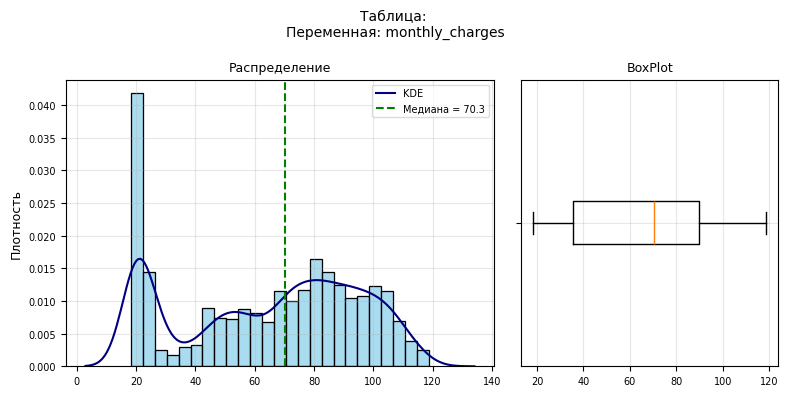

Количество уникальных значений
для переменной: 'monthly_charges' = 1585



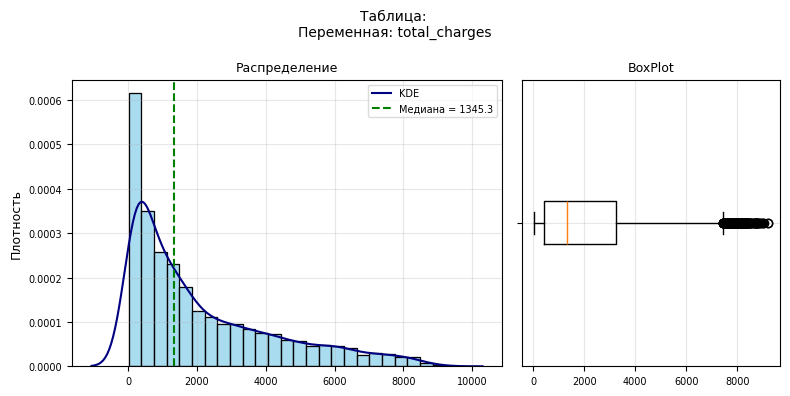

Количество уникальных значений
для переменной: 'total_charges' = 6657



In [41]:
# Получаем список числовых колонок
col_to_analyze = df_contract_work.select_dtypes(
    include=['number']).columns.tolist()

print("Колонки для анализа:")
print(col_to_analyze)

display(df_contract_work[col_to_analyze].describe())

# графики по числовым переменным
display(HTML(f"<b style='color: green;'Данные по числовым переменным</b>"))

for col in col_to_analyze:
    # считаем уникальные значения
    unique_vals = df_contract_work[col].nunique(dropna=True)

    # графики по всем числовым полям
    hist_kde_box_show_new (df_name='',
                           df=df_contract_work,
                           col=col,
                           bins=25,
                           g_h=4, g1_w=5, g2_w=3,
                           units='')
    print(f"Количество уникальных значений\nдля переменной: '{col}' = {unique_vals}\n")

*Выводы - числовые переменные*:
- расходы за месяц (`monthly_charges`) - еще называют данный показатель `ARPU`:
  - есть явно выраженный пик на малых значениях;
  - скорее всего это относится к тем абонентам, которые не поттребляют широкий спектр услуг оператора (например - пользуются только услугами телефонии, но не пользуются интернетом);
  - это предмет для дальнейшего анализа;
- расходы за всеь период договора (`total_charges`):
  - есть пропуски в данных (11 шт.); *можно их удалить - их очень мало*;
  - распределение явно смещено влево (на малые значения);
  - это может быть связано как со сроками договоров, так и с набором услуг абонентов;
  - это предмет для дальнейшего анализа;
- явно выраженных аномалий/артефактов в данных не наблюдается.

### Категориальные переменные

Проанализируем распределения/балансы классов в категориальных переменных.

Колонки для анализа:
['type', 'paperless_billing', 'payment_method']


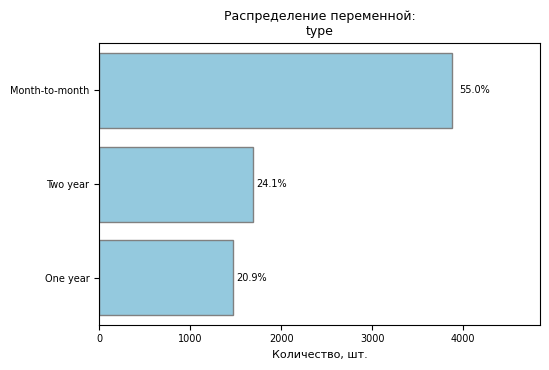

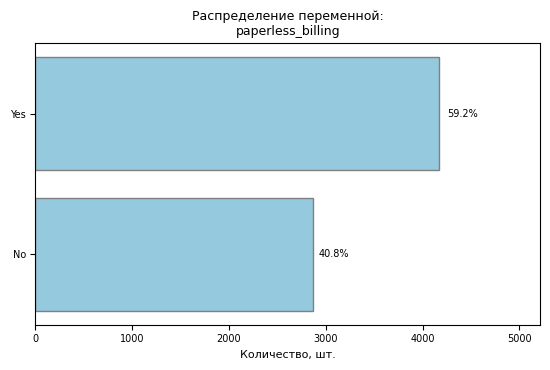

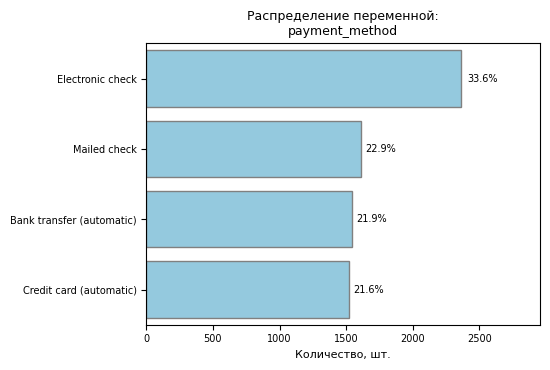

In [42]:
# Получаем список всех нечисловых и недатовых колонок
col_to_analyze = df_contract_work.select_dtypes(
    exclude=['number', 'datetime', 'timedelta']).columns.tolist()

# Исключаем customer_id из списка
col_to_analyze = [col for col in col_to_analyze if col.lower() != 'customer_id']

print("Колонки для анализа:")
print(col_to_analyze)

# графики по категорриальным переменным
display(HTML(f"<b style='color: green;'>Графики по категориальным переменным таблицы</b>"))

plot_cat_freq(df_contract_work, cols=col_to_analyze, figsize=(7, 4))

*Выводы - категориальные переменные*:
- сильных дисбалансов классов в переменных не наблюдается;
- по переменной `payment_method`:
  - *возможно объединение части категорий (например - объединить автоматические платежи в одну категорию)*;
  - это предмет для дальнейшего анализа.

### Переменные с датами

Проанализируем корректность дат начала и окончания договоров с абонентами.

При этом учтем, что:
- дата актуальности базы: `DATE_ACTUAL` = '2020-02-01';
- "заглушка" даты окончания для действующих договоров: `DATE_PLUG` = '2026-08-17'.

In [43]:
# Фильтруем только те записи, где есть даты (не NaN)
df_with_dates = df_contract_work.dropna(subset=['begin_date', 'end_date'])

print("Проверка корректности дат договоров\n")

date_actual_dt = pd.to_datetime(DATE_ACTUAL)

# Проверка 1: Есть ли завершенные договора с датой окончания больше даты актуальности
completed_contracts = df_contract_work[df_contract_work['end_date'] != pd.to_datetime(DATE_PLUG)]
future_end_contracts = completed_contracts[completed_contracts['end_date'] > date_actual_dt]

print(f"Количество завершенных договоров с датой окончания > даты актуальности ({DATE_ACTUAL}): {len(future_end_contracts)}")
if len(future_end_contracts) > 0:
    print(f"Диапазон таких дат: {future_end_contracts['end_date'].min()} - {future_end_contracts['end_date'].max()}")

# Проверка 2: Есть ли договора, где дата начала >= дате окончания
invalid_contracts = df_contract_work[df_with_dates['begin_date'] >= df_contract_work['end_date']]

print(f"\nКоличество договоров с датой начала >= дате окончания: {len(invalid_contracts)}")
if len(invalid_contracts) > 0:
    print("Примеры некорректных записей:")
    print(invalid_contracts[['begin_date', 'end_date']].head())

# Минимальные и максимальные даты начала и окончания
print(f"\nМинимальная дата начала договора: {df_contract_work['begin_date'].min()}")
print(f"Максимальная дата начала договора: {df_contract_work['begin_date'].max()}")
print(f"Минимальная дата окончания договора: {df_contract_work['end_date'].min()}")

Проверка корректности дат договоров

Количество завершенных договоров с датой окончания > даты актуальности (2020-02-01): 0

Количество договоров с датой начала >= дате окончания: 0

Минимальная дата начала договора: 2013-10-01 00:00:00
Максимальная дата начала договора: 2020-02-01 00:00:00
Минимальная дата окончания договора: 2014-06-01 00:00:00


*Выводы - переменные с датами*:
- некорректных данных в датах начала/завершения договоров нет;
- далее необходимо будет ввести новую переменную - срок действия договора с абонентом и изучить ее распределение.

## Таблица: `personal`

In [44]:
df_personal_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


Пропусков в данных нет.

### Категориальные/бинарные переменные

Проанализируем распределения/балансы классов в категориальных/бинарных переменных.

Колонки для анализа:
['gender', 'senior_citizen', 'partner', 'dependents']


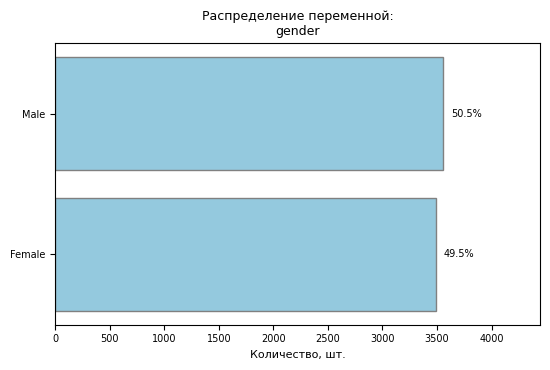

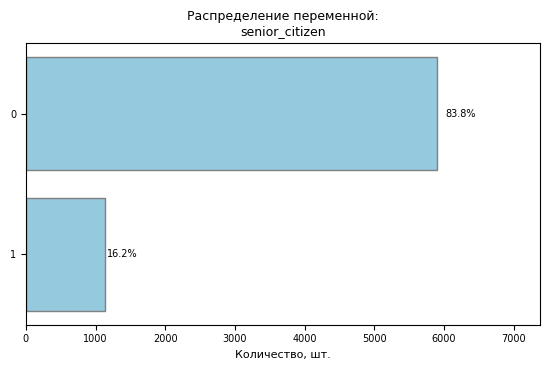

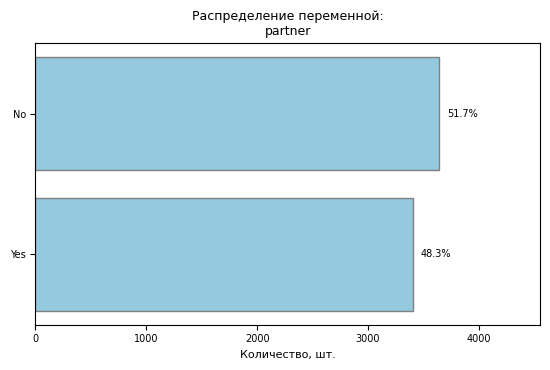

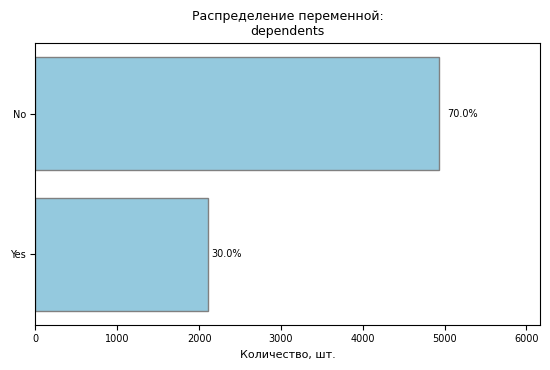

In [45]:
# Получаем список всех колонок
col_to_analyze = df_personal_work.columns.tolist()

# Исключаем customer_id из списка
col_to_analyze = [col for col in col_to_analyze if col.lower() != 'customer_id']

print("Колонки для анализа:")
print(col_to_analyze)

# графики по категорриальным переменным
display(HTML(f"<b style='color: green;'>Графики по категориальным переменным таблицы</b>"))

plot_cat_freq(df_personal_work, cols=col_to_analyze, figsize=(7, 4))

*Выводы - категориальные переменные*:
- заметные дисбалансы классов наблюдаются в следующих переменных:
  - `senior_citizen`: доля пенсионеров/не пенсионеров - 16,2%/83,8% (в целом распеределение выглядит логичным);
  - `dependents`: доля клиентов с детьми/без детей  - 30,0%/70,0% (в целом распеределение не выглядит оторванным от реальности);
- в прочих переменных сильных дисбалансов классов нет.

## Таблица: `internet`

In [46]:
df_internet_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


Пропусков в данных нет.

### Категориальные/бинарные переменные

Проанализируем распределения/балансы классов в категориальных/бинарных переменных.

Колонки для анализа:
['internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']


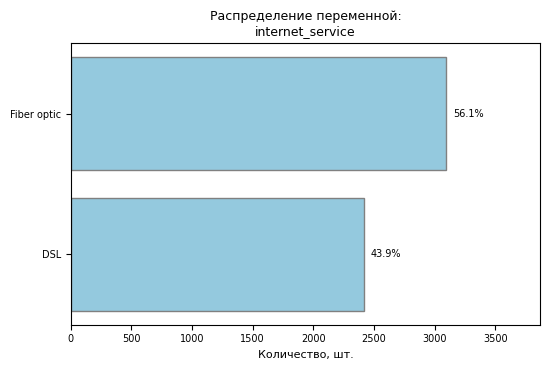

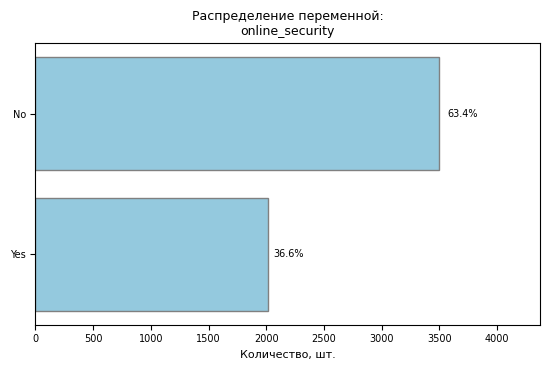

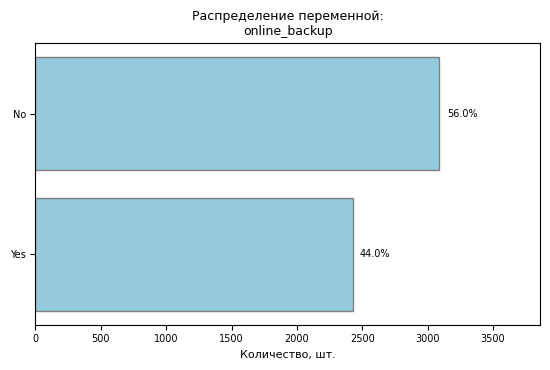

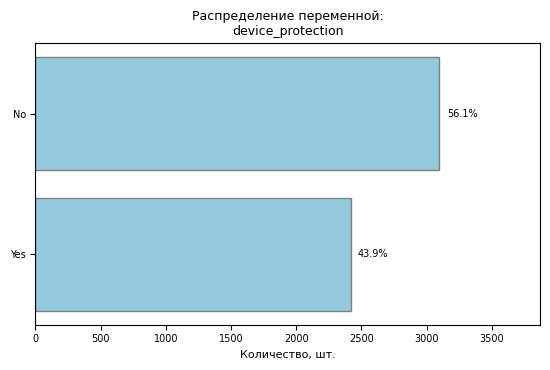

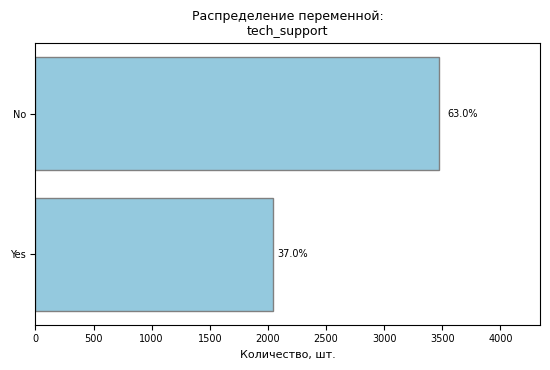

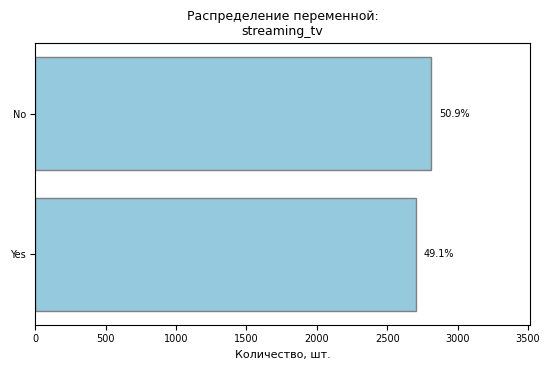

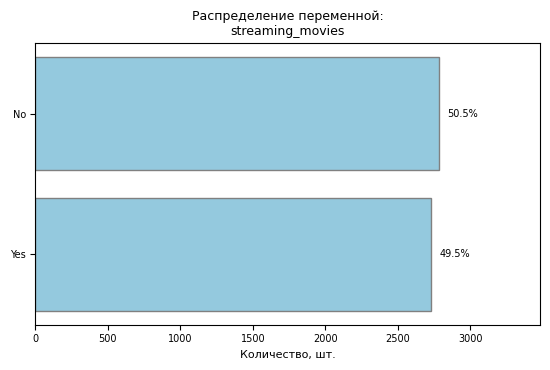

In [47]:
# Получаем список всех колонок
col_to_analyze = df_internet_work.columns.tolist()

# Исключаем customer_id из списка
col_to_analyze = [col for col in col_to_analyze if col.lower() != 'customer_id']

print("Колонки для анализа:")
print(col_to_analyze)

# графики по категорриальным переменным
display(HTML(f"<b style='color: green;'>Графики по категориальным переменным таблицы</b>"))

plot_cat_freq(df_internet_work, cols=col_to_analyze, figsize=(7, 4))

*Выводы - категориальные переменные*:
- заметные дисбалансы классов наблюдаются в следующих переменных:
  - `tech_support`: доля абонентов с выделенной линией технической поддержки/без таковой - 37,0%/63,0%;
  - `online_security`: доля абонентов с блокировкой опасных сайтов/без таковой  - 36,6%/63,4%;
- в прочих переменных сильных дисбалансов классов нет.

## Таблица: `phone`

In [48]:
df_phone_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


Пропусков в данных нет.

### Категориальные/бинарные переменные

Проанализируем распределения/балансы классов в категориальных/бинарных переменных.

Колонки для анализа:
['multiple_lines']


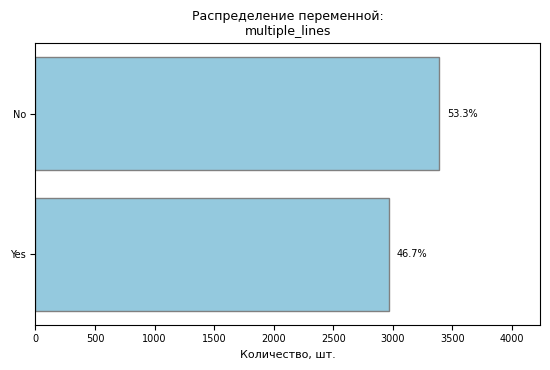

In [49]:
# Получаем список всех колонок
col_to_analyze = df_phone_work.columns.tolist()

# Исключаем customer_id из списка
col_to_analyze = [col for col in col_to_analyze if col.lower() != 'customer_id']

print("Колонки для анализа:")
print(col_to_analyze)

# графики по категорриальным переменным
display(HTML(f"<b style='color: green;'>Графики по категориальным переменным таблицы</b>"))

plot_cat_freq(df_phone_work, cols=col_to_analyze, figsize=(7, 4))

*Выводы - категориальные переменные*:
- сильного дисбаланса классов нет.

## Выводы: EDA - таблицы по отдельности

---
Таблицы (`contract`, `personal`, `phone`, `internet`)

| Таблица | Что отмечено | Примечание |
|------------|------------------|------------|
| `contract` | В поле `total_charges` есть 11 пропусков. Число пропусков пренебрежимо мало, эти записи будут удалены. Сильных дисбалансов классов в категориальных переменных не наблюдается; по переменной `payment_method`возможно объединение части категорий (например - объединить автоматические платежи в одну категорию). Поля с датами - проверены, некорректных записей не выявлено. | --- |
| `personal` | Заметные дисбалансы классов наблюдаются в переменных `senior_citizen`и `dependents`; в прочих переменных сильных дисбалансов классов нет. | ---|
| `internet` | Заметные дисбалансы классов наблюдаются в переменных `tech_support`и `online_security`; в прочих переменных сильных дисбалансов классов нет. | ---|
| `phone` | Сильного дисбаланса классов в переменной `multiple_lines` нет. | --- |

---
*Общие выводы*:

- Общий анализ данных произведен (в разрезе каждой из таблиц).
- Удаление пропусков в поле `total_charges` таблицы `contract`: будет произведена далее - после объединения данных.

# Объединение данных, новые переменные

## Объединение данных

Таблицы с данными имеют разную размерность. Число уникальных `customer_id` (строк) в таблицах приведено ниже.

In [50]:
# Размеры таблиц
print(f"Размер таблицы 'contract':\n  {df_contract_work.shape}")
print(f"Размер таблицы 'personal':\n  {df_personal_work.shape}")
print(f"Размер таблицы 'internet':\n  {df_internet_work.shape}")
print(f"Размер таблицы 'phone':\n  {df_phone_work.shape}")

Размер таблицы 'contract':
  (7043, 8)
Размер таблицы 'personal':
  (7043, 5)
Размер таблицы 'internet':
  (5517, 8)
Размер таблицы 'phone':
  (6361, 2)


Нужно объединить таблицы по полю `customer_id`.

---
Есть два варианта объединения таблиц:
- объединить данные с потерей строк (но все колонки будут заполнены данными);
- объединить данные без потери строк (но в части колонок будут пропуски).

---
Исходя из особенностей телекоммуникационного бизнеса, предпочтительнее объединить данные без потери строк, чтобы получить полный профиль абонента. Это связано с тем, что:
- *Отсутствие интернета или телефонии не означает отсутствие клиента*: многие клиенты могут пользоваться только телефонной связью без интернета (или наоборот); такие клиенты все равно представляют ценность и могут иметь признаки оттока, отличные от клиентов с полным пакетом услуг.
- *Анализ поведения и удержания важен для всех клиентов*: цель анализа - понять, какие факторы влияют на отток; клиенты без интернета или телефонии могут составлять отдельный сегмент с особым поведением, исключение их из анализа исказит результат исследования.
- *Возможность заполнения пропусков*: пропуски в колонках, связанных с отсутствием услуг (например, если нет самой услуги интернета — значит: OnlineSecurity = No internet service), все можно логично интерпретировать и заполнить.
- *Полнота данных для моделирования*: для построения универсальной модели прогноза оттока абонентов важно учитывать все сценарии взаимодействия клиента с компанией, включая частичное использование услуг.

**Вывод**: ***лучше выбрать объединение таблиц без потери строк (по customer_id)***, чтобы не терять информацию о клиентах, чьи пакеты услуг различаются между собой.

In [51]:
# Объединение таблиц по customer_id без потери строк/данных
df_merged = df_contract_work.merge(df_personal_work, on='customer_id', how='left')
df_merged = df_merged.merge(df_internet_work, on='customer_id', how='left')
df_merged = df_merged.merge(df_phone_work, on='customer_id', how='left')

print(f"Размер объединенного датасета: {df_merged.shape}")
print(f"Количество уникальных 'customer_id': {df_merged['customer_id'].nunique()}")
print("\nКоличество пропущенных значений в объединенном датасете:")
print(df_merged.isnull().sum())

Размер объединенного датасета: (7043, 20)
Количество уникальных 'customer_id': 7043

Количество пропущенных значений в объединенном датасете:
customer_id             0
begin_date              0
end_date                0
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
gender                  0
senior_citizen          0
partner                 0
dependents              0
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
multiple_lines        682
dtype: int64


## Заполнение полученных пропусков

Выведем по 3 строки из разных подгрупп абонентов.

In [52]:
# Фильтрация строк
internet_nan = df_merged[df_merged['internet_service'].isna()].sample(3)
phone_nan = df_merged[df_merged['multiple_lines'].isna()].sample(3)
both_not_nan = df_merged[
    (df_merged['internet_service'].notna()) &
    (df_merged['multiple_lines'].notna())].sample(3)

# Объединение выбранных строк
result_temp = pd.concat([internet_nan, phone_nan, both_not_nan], ignore_index=True)

# Вывод результата
display(result_temp)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,1022-RKXDR,2016-09-01,2026-08-17,One year,Yes,Mailed check,24.850,"1,090.170",Female,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
1,1982-FEBTD,2018-03-01,2026-08-17,Two year,Yes,Credit card (automatic),25.600,600.580,Female,0,Yes,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes
2,1000-AJSLD,2019-10-01,2026-08-17,Month-to-month,Yes,Mailed check,20.100,86.830,Male,0,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
3,5126-RCXYW,2015-08-01,2019-10-01,Two year,No,Credit card (automatic),46.000,"2,300.000",Male,0,Yes,Yes,DSL,No,No,Yes,Yes,No,Yes,NaN
4,6128-AQBMT,2016-09-01,2026-08-17,Month-to-month,Yes,Electronic check,53.950,"2,211.950",Male,1,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,NaN
5,9895-VFOXH,2020-01-01,2026-08-17,Month-to-month,No,Mailed check,24.400,24.400,Female,0,No,No,DSL,No,No,No,No,No,No,NaN
6,1020-JPQOW,2015-06-01,2026-08-17,Month-to-month,No,Electronic check,90.550,"5,070.800",Female,0,Yes,No,Fiber optic,No,Yes,Yes,Yes,No,No,Yes
7,8295-KMENE,2015-03-01,2026-08-17,Two year,Yes,Mailed check,76.450,"4,690.970",Female,0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,No,Yes
8,2672-OJQZP,2020-01-01,2026-08-17,Month-to-month,No,Mailed check,44.750,46.090,Female,0,No,No,DSL,No,No,No,No,No,No,No


**Принципы заполнения пропусков** (которые получились при объединении данных):
- Для услуг интернета (online_security, online_backup, device_protection, tech_support, streaming_tv, streaming_movies):
  - Заменить NaN на "No internet service" (отдельная категория), получим:
    - Yes = услуга подключена
    - No = услуга не подключена (но интернет есть)
    - No internet service = нет интернета (базовая услуга недоступна)
- Для multiple_lines:
  - Заменить NaN на "No phone service" (отдельная категория), получим:
    - Yes = подключено
    - No = не подключено (но телефония есть)
    - No phone service = нет услуги телефонии.

***При таком способе заполнения пропусков мы сохраняем максимум информации об абоненте и наборе услуг***.

In [53]:
# Заполнение пропусков в соответствии с указанными выше принципами
df_merged['internet_service'] = df_merged['internet_service'].fillna('No internet service')

internet_related_cols = ['online_security', 'online_backup', 'device_protection',
                         'tech_support', 'streaming_tv', 'streaming_movies']
for col in internet_related_cols:
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna('No internet service')

df_merged['multiple_lines'] = df_merged['multiple_lines'].fillna('No phone service')

In [54]:
# Пропуски по всем полям
print("\nКоличество пропущенных значений по всем полям:")
print(df_merged.isnull().sum())


Количество пропущенных значений по всем полям:
customer_id           0
begin_date            0
end_date              0
type                  0
paperless_billing     0
payment_method        0
monthly_charges       0
total_charges        11
gender                0
senior_citizen        0
partner               0
dependents            0
internet_service      0
online_security       0
online_backup         0
device_protection     0
tech_support          0
streaming_tv          0
streaming_movies      0
multiple_lines        0
dtype: int64


Посмотрим детальнее на 11 пропусков в поле общих расходов абонента.

In [55]:
# Изолируем 11 строк с пропуском в total_charges
nan_total_charges = df_merged[df_merged['total_charges'].isnull()].copy()

cols_to_show = [
    'customer_id', 'begin_date', 'end_date', 'type',
    'monthly_charges', 'total_charges',
    'payment_method', 'internet_service']

print("Детальный просмотр строк с пропусками:")
display(nan_total_charges[cols_to_show])

Детальный просмотр строк с пропусками:


,customer_id,begin_date,end_date,type,monthly_charges,total_charges,payment_method,internet_service
488,4472-LVYGI,2020-02-01,2026-08-17,Two year,52.550,NaN,Bank transfer (automatic),DSL
753,3115-CZMZD,2020-02-01,2026-08-17,Two year,20.250,NaN,Mailed check,No internet service
936,5709-LVOEQ,2020-02-01,2026-08-17,Two year,80.850,NaN,Mailed check,DSL
1082,4367-NUYAO,2020-02-01,2026-08-17,Two year,25.750,NaN,Mailed check,No internet service
1340,1371-DWPAZ,2020-02-01,2026-08-17,Two year,56.050,NaN,Credit card (automatic),DSL
3331,7644-OMVMY,2020-02-01,2026-08-17,Two year,19.850,NaN,Mailed check,No internet service
3826,3213-VVOLG,2020-02-01,2026-08-17,Two year,25.350,NaN,Mailed check,No internet service
4380,2520-SGTTA,2020-02-01,2026-08-17,Two year,20.000,NaN,Mailed check,No internet service
5218,2923-ARZLG,2020-02-01,2026-08-17,One year,19.700,NaN,Mailed check,No internet service
6670,4075-WKNIU,2020-02-01,2026-08-17,Two year,73.350,NaN,Mailed check,DSL


**Анализ структуры пропусков**:
- это все долгосрочные контракты (1 год и 2 года);
- все контракты заключены в дату актуальности базы (2020-02-01);
- в поле срока окончания договора стоит "заглушка" (значит договор действует на дату актуальности базы);
- ежемесячныеи расходы у всех не ноль (т.е. в договорах тариф определен).

**Что это означает**:
- это не артефакты, а реальные новые абоненты с действующими долгосрочными договорами.

**Способ обработки пропусков**:
- *наиболее корректное решение - заполнить пропуски в `total_charges` нулями*, потому что:
  - на дату среза (2020-02-01) эти клиенты еще не совершили ни одного платежа (или он не учтен в системе);
  - это консервативный и логичный подход: `total_charges` = 0 на момент регистрации абонента.
  - альтернатива: заполнить `total_charges` = `monthly_charges` * длину договора (12 или 24 мес.) будет менее обоснованной, так как мы не знаем, был ли платеж проведен.

In [56]:
# Заполняем пропуски в поле total_charges нулями
# всего 11 шт. - пренебрежимо мало
df_merged['total_charges'] = df_merged['total_charges'].fillna(0)

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   gender             7043 non-null   object        
 9   senior_citizen     7043 non-null   int64         
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   object        
 14  online_b

Выведем по 3 строки из разных подгрупп абонентов - после заполнения пропусков.

In [57]:
# Фильтрация строк
internet_no_service = df_merged[df_merged['internet_service'] == 'No internet service'].sample(3)
phone_no_service = df_merged[df_merged['multiple_lines'] == 'No phone service'].sample(3)
both_with_service = df_merged[
    (df_merged['internet_service'] != 'No internet service') &
    (df_merged['multiple_lines'] != 'No phone service')].sample(3)

# Объединение выбранных строк
result_filtered = pd.concat([internet_no_service,
                             phone_no_service,
                             both_with_service],
                             ignore_index=True)

# Вывод результата
display(result_filtered)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,1561-BWHIN,2018-07-01,2026-08-17,One year,No,Mailed check,19.800,376.200,Male,0,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
1,2236-HILPA,2014-12-01,2026-08-17,Two year,No,Credit card (automatic),20.650,"1,280.300",Male,0,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
2,3284-SVCRO,2016-05-01,2018-09-01,Two year,No,Mailed check,25.500,714.000,Female,0,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Yes
3,0909-SDHNU,2019-07-01,2026-08-17,Month-to-month,No,Mailed check,29.800,208.600,Female,0,No,Yes,DSL,Yes,No,No,No,No,No,No phone service
4,7233-IOQNP,2016-07-01,2026-08-17,Month-to-month,No,Bank transfer (automatic),34.000,"1,491.240",Female,0,Yes,No,DSL,Yes,No,No,Yes,No,No,No phone service
5,7851-FLGGQ,2019-11-01,2026-08-17,Month-to-month,Yes,Mailed check,44.650,133.950,Male,0,No,No,DSL,No,Yes,No,Yes,No,Yes,No phone service
6,2424-WVHPL,2020-01-01,2026-08-17,Month-to-month,No,Electronic check,74.700,79.930,Male,1,No,No,Fiber optic,No,No,No,Yes,No,No,No
7,6461-SZMCV,2014-03-01,2018-11-01,Two year,No,Bank transfer (automatic),87.950,"4,925.200",Female,0,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Yes
8,6734-GMPVK,2019-09-01,2026-08-17,Month-to-month,No,Electronic check,105.300,579.150,Male,0,No,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes


## Трансформация переменных в категории (Yes/No)

Для единообразия трансформируем часть переменных в Yes/No, а именно:
- переменную `senior_citizen` переформируем как 0 - No / 1 - Yes;
- переменную `gender` переименуем в `is_male` и переформируем как No - Female / Yes - Male.

In [58]:
# Преобразования колонок, переименование gender в is_male
df_merged['senior_citizen'] = df_merged['senior_citizen'].map({0: 'No', 1: 'Yes'})
df_merged['gender'] = df_merged['gender'].map({'Female': 'No', 'Male': 'Yes'})
df_merged = df_merged.rename(columns={'gender': 'is_male'})

In [59]:
# Проверка уникальных значений для транформированных столбцов
unique_values_df = pd.DataFrame({
    col: [sorted(df_merged[col].unique())]
    for col in ['senior_citizen', 'is_male']
    if col in df_merged.columns
}).T
unique_values_df.columns = ['Уникальные значения']

display(unique_values_df)

,Уникальные значения
senior_citizen,"[No, Yes]"
is_male,"[No, Yes]"


Выведем по 3 строки из разных подгрупп абонентов - после заполнения пропусков и трансформации части столбцов.

In [60]:
# Фильтрация строк
internet_no_service = df_merged[df_merged['internet_service'] == 'No internet service'].sample(3)
phone_no_service = df_merged[df_merged['multiple_lines'] == 'No phone service'].sample(3)
both_with_service = df_merged[
    (df_merged['internet_service'] != 'No internet service') &
    (df_merged['multiple_lines'] != 'No phone service')].sample(3)

# Объединение выбранных строк
result_filtered = pd.concat([internet_no_service,
                             phone_no_service,
                             both_with_service],
                             ignore_index=True)

# Вывод результата
display(result_filtered)

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,is_male,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,7267-FRMJW,2018-01-01,2026-08-17,Two year,No,Mailed check,20.100,502.500,No,No,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
1,0594-UFTUL,2019-01-01,2026-08-17,Month-to-month,Yes,Mailed check,19.850,258.050,Yes,No,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No
2,0203-HHYIJ,2017-09-01,2026-08-17,One year,No,Bank transfer (automatic),25.300,733.700,Yes,No,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Yes
3,2894-QOJRX,2017-09-01,2026-08-17,Month-to-month,Yes,Bank transfer (automatic),34.000,986.000,No,No,Yes,No,DSL,No,No,No,No,Yes,No,No phone service
4,1862-SKORY,2016-08-01,2019-09-01,Month-to-month,Yes,Electronic check,39.300,"1,454.100",No,Yes,Yes,No,DSL,No,Yes,No,No,Yes,No,No phone service
5,8039-EQPIM,2014-05-01,2026-08-17,Two year,No,Bank transfer (automatic),60.250,"4,365.110",Yes,No,Yes,No,DSL,Yes,No,Yes,Yes,Yes,Yes,No phone service
6,5947-SGKCL,2018-11-01,2026-08-17,Month-to-month,Yes,Bank transfer (automatic),105.350,"1,738.280",No,No,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes
7,4727-MCYZG,2020-01-01,2026-08-17,Month-to-month,No,Mailed check,55.550,55.550,Yes,No,No,No,DSL,No,No,No,No,No,Yes,No
8,1965-AKTSX,2018-11-01,2026-08-17,Month-to-month,Yes,Electronic check,78.950,"1,184.250",No,Yes,No,No,Fiber optic,No,Yes,No,No,No,No,Yes


In [61]:
# проверим структуру данных после преобразований
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           7043 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7043 non-null   float64       
 8   is_male            7043 non-null   object        
 9   senior_citizen     7043 non-null   object        
 10  partner            7043 non-null   object        
 11  dependents         7043 non-null   object        
 12  internet_service   7043 non-null   object        
 13  online_security    7043 non-null   object        
 14  online_b

## Новые переменные, целевая переменная

***Анализ возможных новых признаков, которые можно сгенерировать на основе имеющихся данных***:

1. Длина контракта в месяцах/годах: как разница между датой начала и датой окончания договора (или датой актуальности базы для действующих договоров):
- данный признак будет сформирован;
- далее нужно отслеживать, чтобы в иных признаках не было утечки из этого признака.

2. Количество подключенных услуг - как сумма всех признаков признаков, относящихся к набору услуг у абонента:
- возможно использовать как некоторый легитимный агрегат (возможно он даст мультиколлинеарность, это предмет дальнейшего анализа), и далле от него посчитать производные признаки.

3. Расходы на 1 услугу в месяц у абонента:
- отношение ежемесячных расходов к общему числу подключенных услуг (агрегат из п.2).

4. Кодированный набор интернет-услуг у абонента:
- строковое поле, которое формируется так:
  - по каждой из интернет-услуг формируется строка вида: 'Yes' -> '1', 'No' -> '0', 'No service' -> '2';
  - полученные строковые коды объединяются.

In [62]:
# Нужные даты
DATE_ACTUAL_DT = pd.to_datetime(DATE_ACTUAL)
DATE_PLUG_DT = pd.to_datetime(DATE_PLUG)

# Создаем маску для строк с заглушкой
mask_plug = df_merged['end_date'] == DATE_PLUG_DT

# Вычисляем продолжительность для всех строк сразу
# Для строк с заглушкой используем DATE_ACTUAL, иначе - фактическую дату окончания
end_dates = df_merged['end_date'].where(~mask_plug, DATE_ACTUAL_DT)

# Вычисляем разницу в днях и переводим в месяцы (примерно)
diff_in_days = (end_dates - df_merged['begin_date']).dt.days
months = round(diff_in_days / 30.5, 2)

# Не допускаем значения меньше 0.1
df_merged['duration'] = months.where(months >= 0.1, 0.1)

# Нужные колонки с услугами
internet_related_cols = ['online_security',
                         'online_backup',
                         'device_protection',
                         'tech_support',
                         'streaming_tv',
                         'streaming_movies']

# Интернет-часть: +1 за сам интернет (если есть) + 1 за каждую подключенную услугу
internet_part = (
    (df_merged['internet_service'] != 'No internet service').astype(int) +
    df_merged[internet_related_cols].eq('Yes').sum(axis=1))

# Телефония: маппинг значений multiple_lines
# No phone service - 0, No - 1, Yes - 2
phone_part = df_merged['multiple_lines'].map({
    'No phone service': 0,
    'No': 1,
    'Yes': 2})

# Итоговое число услуг: от 1 до 9
df_merged['num_services'] = internet_part + phone_part

# Средняя стоимость за 1 услугу в месяц
df_merged['1_serv_cost'] = round(df_merged['monthly_charges'] / df_merged['num_services'], 2)

print("Новые переменные 'duration', 'num_services', '1_serv_cost' - созданы.")

Новые переменные 'duration', 'num_services', '1_serv_cost' - созданы.


In [63]:
# Создаем код набора услуг абонента
service_set_cols = internet_related_cols

mapping_services_code = {
    'Yes': '1', 'No': '0',
    'No internet service': '2'
}

# 1. replace — кодируем известные значения
# 2. fillna('2') — все пропуски (NaN, NA, незакодированные значения) -> '2'
# 3. astype(str) — гарантированно приводим к строке, чтобы избежать 'nan'
coded_services = (
    df_merged[service_set_cols]
    .replace(mapping_services_code)
    .fillna('2')
    .astype(str)
    .to_numpy()
)

df_merged['internet_service_set'] = [''.join(row) for row in coded_services.tolist()]

print("Новая переменная 'internet_service_set' - создана.")
print(f"Число уникальных значений переменной:"
      f"{df_merged['internet_service_set'].nunique()} шт.")

Новая переменная 'internet_service_set' - создана.
Число уникальных значений переменной:65 шт.


In [64]:
# Вывод 10 случайных значений переменной 'service_set'
random_samples = df_merged['internet_service_set'].sample(10).tolist()

print("10 случайных значений переменной 'internet_service_set':")
for val in random_samples:
    print(f"- '{val}' (длина: {len(val)})")

10 случайных значений переменной 'internet_service_set':
- '000110' (длина: 6)
- '110110' (длина: 6)
- '000000' (длина: 6)
- '110000' (длина: 6)
- '000000' (длина: 6)
- '000000' (длина: 6)
- '001011' (длина: 6)
- '111111' (длина: 6)
- '010000' (длина: 6)
- '000111' (длина: 6)


***Целевая переменная***:

- целевая переменная (`target`):
  - если в дате окончания договора *стоит* "заглушка", то:
    - `target` = 0 (абонент не ушел, класс 0);
  - если в дата окончания договора менее или равна дате актуальности базы, то:
    - `target` = 1 (абонент ушел, класс 1).
- дополнение по "граничному условию":
  - если дата окончания договора равна дату атуальности базы (2020-02-01):
    - бизнес-логика: если абонент расторг договор ровно в дату среза (1-е число месяца), это означает, что он не будет пользоваться услугой в новом месяце и не оплатит его; следовательно, это отток (target = 1);
    - *ВАЖНО: таких строк в датасете нет (проверка ниже)*.

In [65]:
# проверка граничных условий по дате окончания договора
print("Проверка граничных условий дат")

# Проверяем контракты, у которых end_date в точности равна дате среза базы
mask_end_actual = df_merged['end_date'] == DATE_ACTUAL_DT
count_end_actual = mask_end_actual.sum()
print(f"Количество контрактов с end_date (дата окончания) == DATE_ACTUAL ({DATE_ACTUAL}): {count_end_actual} шт.")

Проверка граничных условий дат
Количество контрактов с end_date (дата окончания) == DATE_ACTUAL (2020-02-01): 0 шт.


In [66]:
# Явное создание таргета (без маски)

conditions = [
    (df_merged['end_date'] == DATE_PLUG_DT),  # стоит заглушка -> клиент активен
    (df_merged['end_date'] <= DATE_ACTUAL_DT) # дата окончания <= даты среза -> клиент ушел
]
choices = [0, 1]

# Создаем таргет.
# Если вдруг попадется end_date > DATE_ACTUAL (чего быть не должно), будет NaN
df_merged['target'] = np.select(conditions, choices, default=np.nan)

# Финальная проверка, что не осталось "потерянных" записей
nan_targets = df_merged['target'].isna().sum()
if nan_targets > 0:
    print(f"ВНИМАНИЕ: Найдено {nan_targets} записей, для которых не определен target!")
    print("Проверьте записи, где end_date > DATE_ACTUAL и end_date != DATE_PLUG.")
else:
    print("Целевая переменная 'target' успешно и явно создана. Пропусков нет.")

# Распределение таргета для отчета
print("\nРаспределение целевой переменной:")
print(df_merged['target'].value_counts(normalize=True))

Целевая переменная 'target' успешно и явно создана. Пропусков нет.

Распределение целевой переменной:
target
0.000   0.844
1.000   0.156
Name: proportion, dtype: float64


# EDA - объединенные и новые признаки

In [67]:
# Копия данных для работы
df_all = df_merged.copy()

df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           7043 non-null   object        
 1   begin_date            7043 non-null   datetime64[ns]
 2   end_date              7043 non-null   datetime64[ns]
 3   type                  7043 non-null   object        
 4   paperless_billing     7043 non-null   object        
 5   payment_method        7043 non-null   object        
 6   monthly_charges       7043 non-null   float64       
 7   total_charges         7043 non-null   float64       
 8   is_male               7043 non-null   object        
 9   senior_citizen        7043 non-null   object        
 10  partner               7043 non-null   object        
 11  dependents            7043 non-null   object        
 12  internet_service      7043 non-null   object        
 13  online_security   

## Списки переменных

In [68]:
# Переменные, которые не анализируем, но пока не удаляем
cols_not_to_analyze = ['customer_id', 'begin_date', 'end_date']

In [69]:
print("Уникальные значения (для object и int)")

for col in df_all.columns:
    # Исключаем колонки из списка для анализа
    if col in cols_not_to_analyze:
        continue

    # Проверяем, является ли тип данных object или целочисленным
    if pd.api.types.is_object_dtype(df_all[col]) or pd.api.types.is_integer_dtype(df_all[col]):
        unique_vals = df_all[col].unique()
        print(f"\n[{col}] (тип: {df_all[col].dtype})")
        print(f"Уникальные значения ({len(unique_vals)}): {unique_vals}")

Уникальные значения (для object и int)

[type] (тип: object)
Уникальные значения (3): ['Month-to-month' 'One year' 'Two year']

[paperless_billing] (тип: object)
Уникальные значения (2): ['Yes' 'No']

[payment_method] (тип: object)
Уникальные значения (4): ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

[is_male] (тип: object)
Уникальные значения (2): ['No' 'Yes']

[senior_citizen] (тип: object)
Уникальные значения (2): ['No' 'Yes']

[partner] (тип: object)
Уникальные значения (2): ['Yes' 'No']

[dependents] (тип: object)
Уникальные значения (2): ['No' 'Yes']

[internet_service] (тип: object)
Уникальные значения (3): ['DSL' 'Fiber optic' 'No internet service']

[online_security] (тип: object)
Уникальные значения (3): ['No' 'Yes' 'No internet service']

[online_backup] (тип: object)
Уникальные значения (3): ['Yes' 'No' 'No internet service']

[device_protection] (тип: object)
Уникальные значения (3): ['No' 'Yes' 'No internet service']

[tech_s

In [70]:
# выделение целевой переменной
target = 'target'

In [71]:
# Получаем список всех числовых колонок
num_cols_all = df_all.select_dtypes(
    include=['number']).columns.tolist()

# Убираем таргет, если он там есть
num_cols_all = [col for col in num_cols_all if col != target]

# Убираем неанализируемые колонки
num_cols_all = [col for col in num_cols_all if col not in cols_not_to_analyze]

# Разделяем числовые на бинарные и непрерывные
binary_cols_all = []
non_binary_cols_all = []

for col in num_cols_all:
    unique_vals = df_all[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}) and len(unique_vals) <= 2:
        binary_cols_all.append(col)
    else:
        non_binary_cols_all.append(col)

In [72]:
# Получаем список всех нечисловых колонок и не дат
cat_cols_all = df_all.select_dtypes(
    exclude=['number']).columns.tolist()

# Убираем таргет, если он там есть
cat_cols_all = [col for col in cat_cols_all if col != target]

# Убираем неанализируемые колонки
cat_cols_all = [col for col in cat_cols_all if col not in cols_not_to_analyze]

In [73]:
print("Целевая переменная:")
print(target)

print("\nБинарные колонки (0/1):")
print(binary_cols_all)

print("\nЧисловые небинарные колонки:")
print(non_binary_cols_all)

print("\nКатегориальные колонки:")
print(cat_cols_all)

Целевая переменная:
target

Бинарные колонки (0/1):
[]

Числовые небинарные колонки:
['monthly_charges', 'total_charges', 'duration', 'num_services', '1_serv_cost']

Категориальные колонки:
['type', 'paperless_billing', 'payment_method', 'is_male', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'internet_service_set']


## Числовые (небинарные) переменные

### Статистика

Нужно провести анализ размаха значений по числовым переменным.

*Выведем основную статистику по числовым полям датасета*

In [74]:
# описательная статистика по числовым переменным
display(HTML(f"<b style='color: green;'>Cтатистика по числовым переменным</b>"))

# описательная статистика по числовым полям
display(df_all[non_binary_cols_all].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).loc[
        ['min', '1%', '5%', '25%', '50%', '75%', '95%', '99%', 'max']])

,monthly_charges,total_charges,duration,num_services,1_serv_cost
min,18.250,0.000,0.100,1.000,8.650
1%,19.200,20.544,1.020,1.000,9.650
5%,19.650,75.105,2.030,1.000,10.410
25%,35.500,436.750,9.050,2.000,12.990
50%,70.350,"1,343.350",24.950,4.000,16.670
75%,89.850,"3,236.690",47.900,6.000,20.100
95%,107.400,"6,630.147",70.920,8.000,26.170
99%,114.729,"8,158.382",71.840,9.000,35.200
max,118.750,"9,221.380",75.870,9.000,36.120


Общая статистика:
- В числовых переменных нет явных выбросов/артефактов.
- Мин/Макс по общим расходам абонентов сильно различаются по естественным причинам (разные сроки договоров и разные наборы услуг).
- Нулевых/отрицательных значений нет.

Исследуем распределения признаков.

### Графики

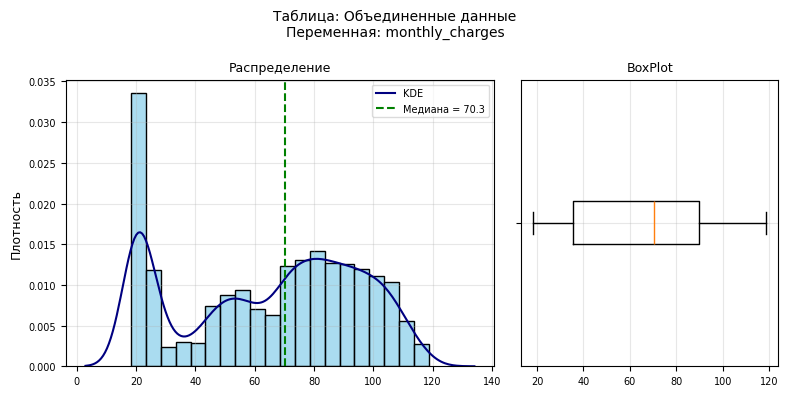

Количество уникальных значений
для переменной: 'monthly_charges' = 1585



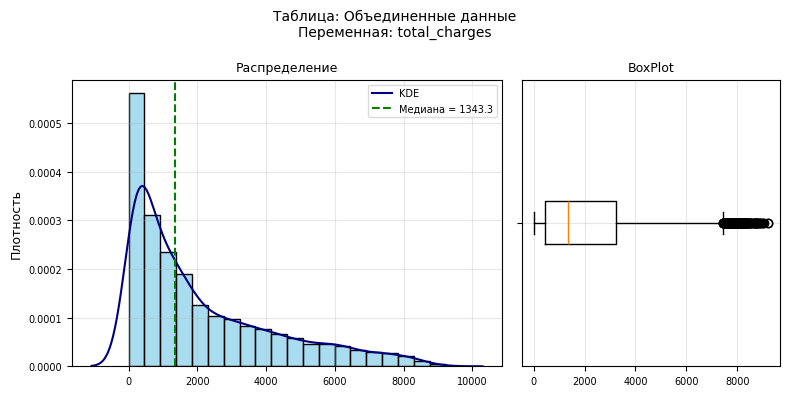

Количество уникальных значений
для переменной: 'total_charges' = 6658



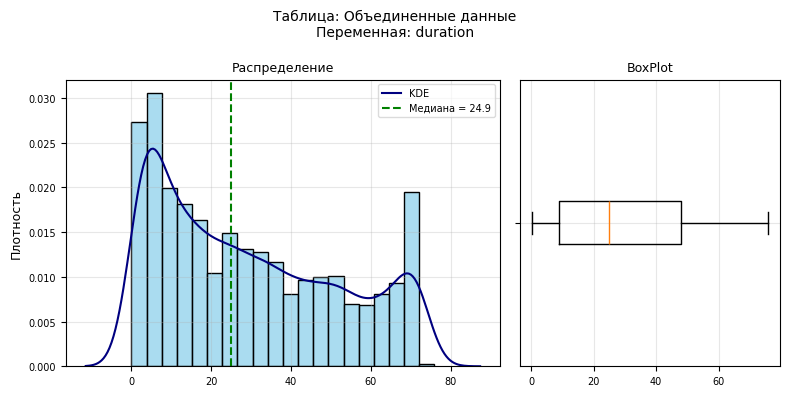

Количество уникальных значений
для переменной: 'duration' = 251



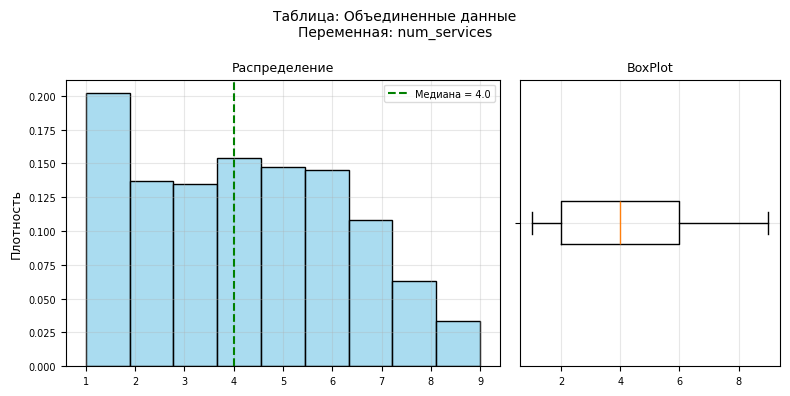

Количество уникальных значений
для переменной: 'num_services' = 9



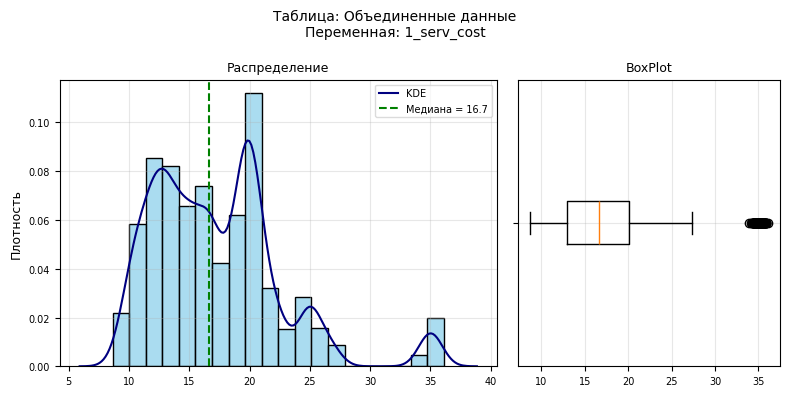

Количество уникальных значений
для переменной: '1_serv_cost' = 1412



In [75]:
# графики по числовым переменным
display(HTML(f"<b style='color: green;'>Графики по числовым переменным</b>"))

for col in non_binary_cols_all:
    # считаем уникальные значения
    unique_vals = df_all[col].nunique(dropna=True)

    hist_kde_box_show_new (df_name='Объединенные данные',
                           df=df_all,
                           col=col,
                           bins=20,
                           g_h=4, g1_w=5, g2_w=3,
                           units='')
    print(f"Количество уникальных значений\nдля переменной: '{col}' = {unique_vals}\n")

### Выводы

1. Ежемесячные расходы абонента (`monthly_charges`):
- медиана = 70.3; выраженных выбросов нет;
- есть выраженный пик распределения на малых значениях.

2. Суммарные расходы абонента (`total_charges`):
- медиана = 1345.3; выраженных выбросов нет;
- распределение - экспонециально убывающее.

3. Срок договора (`duration`):
- медиана = 24.9 (мес.);
- есть несколько пиков, в том числе на концах распределения.

4. Общее число подключенных услуг (`num_services`):
- медиана = 4;
- есть не сильный выброс частоты на значении 1;
- значения 2-6 имеют примерно сопоставимы частоты;
- далее частоты плавно уменьшаются.

5. Средняя стоимость за 1 услугу в месяц (`1_serv_cost`):
- медиана = 16.7;
- есть несколько пиков.

## Числовые (бинарные) переменные

### Графики

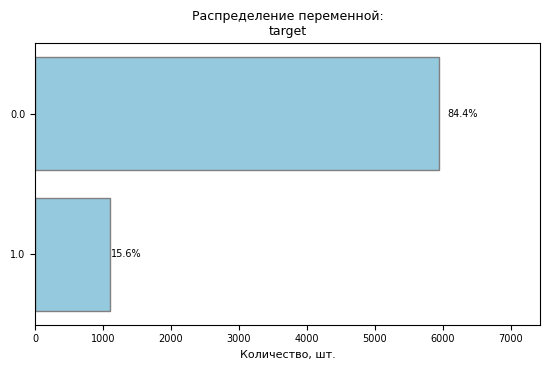

In [76]:
# графики по бинарным переменным
display(HTML(f"<b style='color: green;'>Графики по бинарным переменным</b>"))

plot_cat_freq(df_all, [target] + binary_cols_all, figsize=(7, 4))

### Выводы

1. *Сильный дисбаланс классов*:
- целевая переменная (`target`): 0/1 - 84%/16%;

***Важно***: *при разбиении на train/test выборки необъходима стратификация по целевой переменной*.

## Категориальные переменные

### Графики

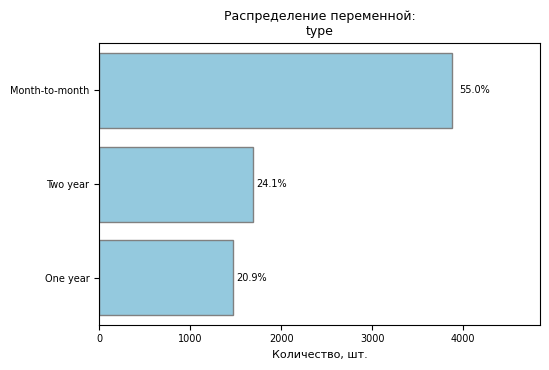

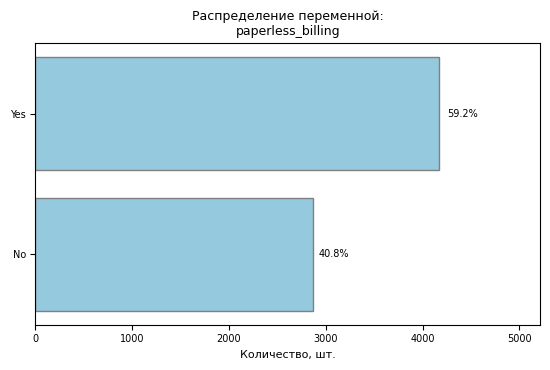

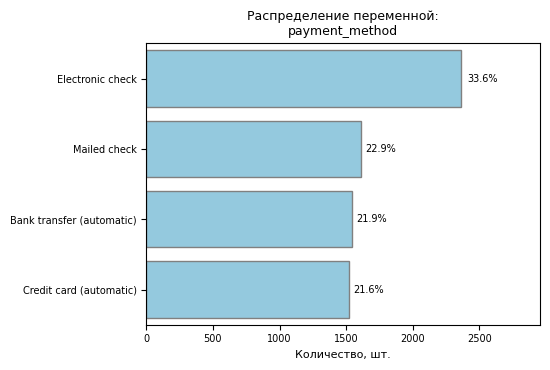

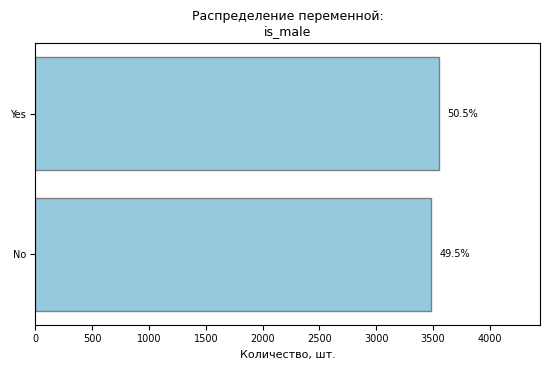

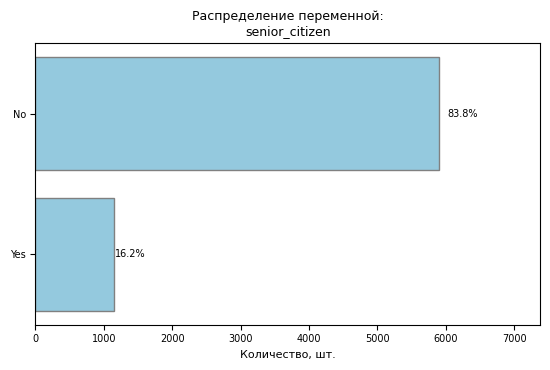

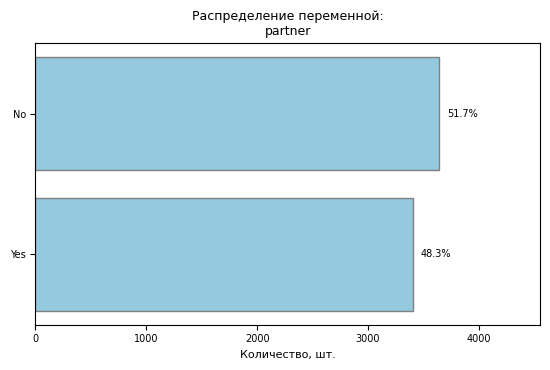

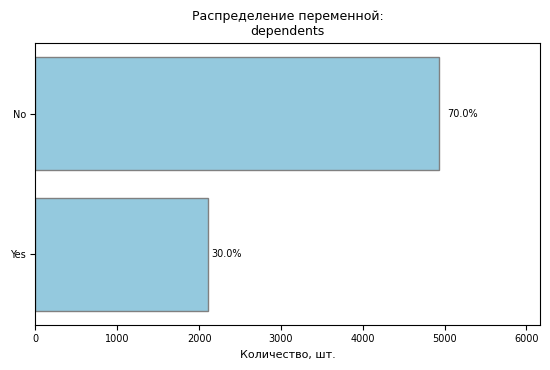

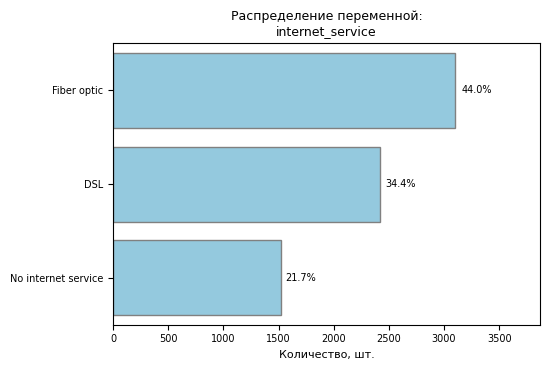

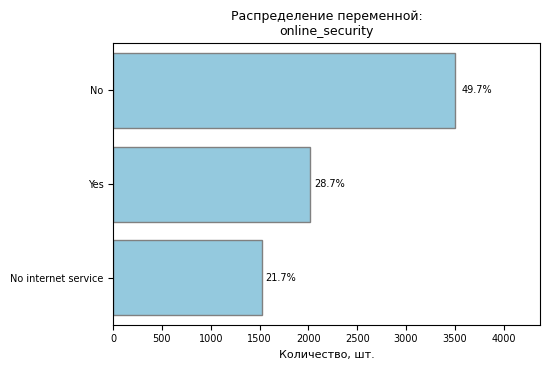

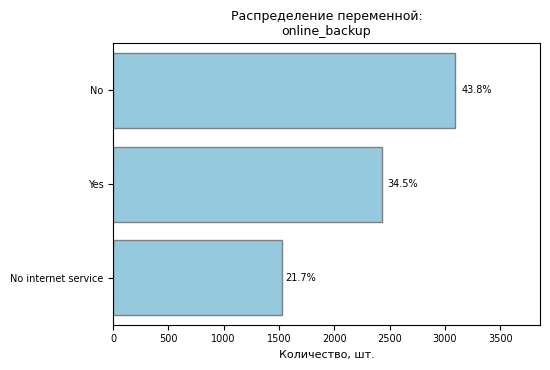

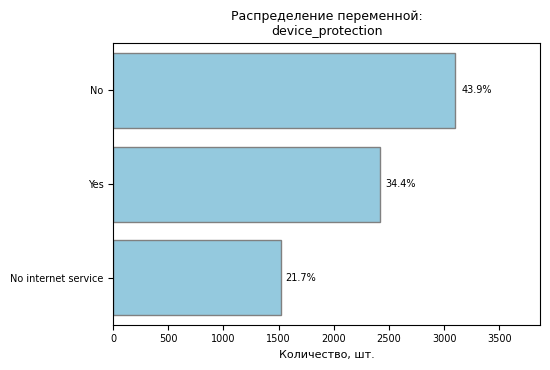

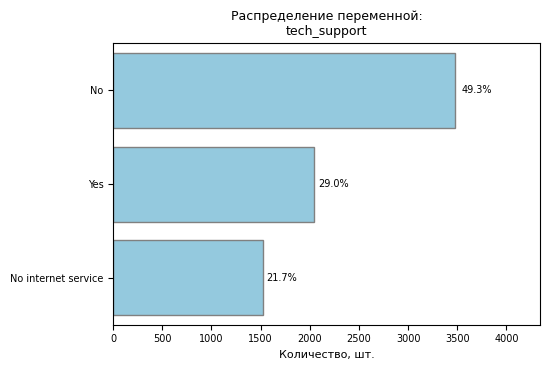

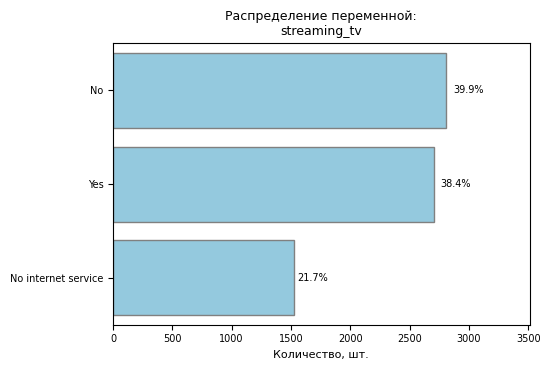

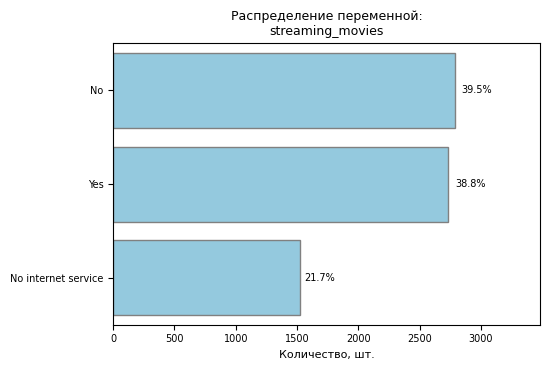

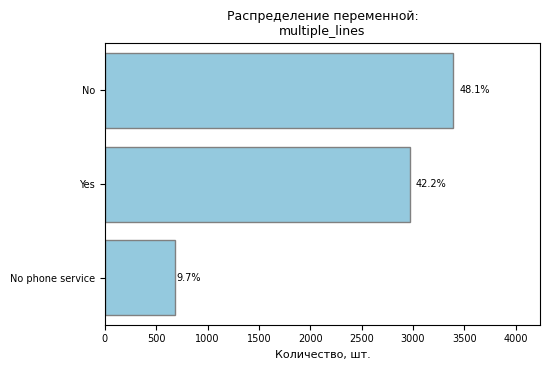

In [77]:
# графики по категориальным переменным
display(HTML(f"<b style='color: green;'>Графики по категориальным переменным</b>"))

plot_cat_freq(df_all,
              [col for col in cat_cols_all if col != 'internet_service_set'],
              figsize=(7, 4))

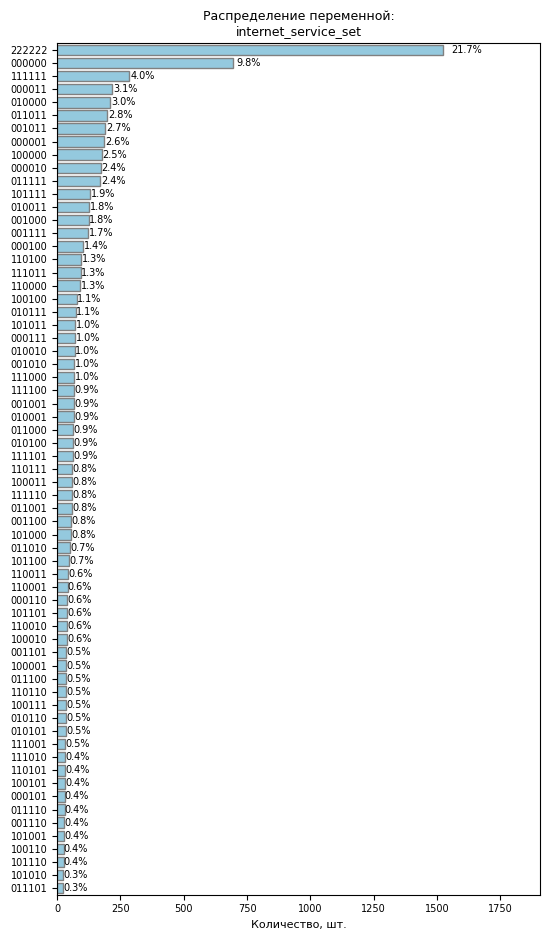

In [78]:
# Отдельный график по наборам интернет-услуг
display(HTML(f"<b style='color: green;'>График по по наборам интернет-услуг</b>"))

plot_cat_freq(df_all,
              ['internet_service_set'],
              figsize=(7, 10))

Дополнительно исследуем частоты в категориях поля `internet_service_set`.

In [79]:
#Считаем абсолютные количества и проценты
total_rows = len(df_all)

freq = (
    df_all['internet_service_set']
    .value_counts()
    .to_frame('count')
)
freq.index.name = 'internet_service_set'

# Вычисляем проценты на основе count
freq['frequency_%'] = (freq['count'] / total_rows) * 100
freq['cumulative_%'] = freq['frequency_%'].cumsum()

# Переупорядочиваем колонки и приводим count к целому типу
freq = freq[['count', 'frequency_%', 'cumulative_%']].astype({'count': int})

# Вывод данных
print(f"Всего уникальных наборов интернет-услуг:       {len(freq)}")
print(f"Суммарная частота всех наборов интернет-услуг: {freq['frequency_%'].sum():.2f}%")
print("5 самых частых и 5 самых редких интернет-услуг")

# 3. Формируем таблицу: 5 первых + 5 последних строк
freq_display = pd.concat([freq.head(5), freq.tail(5)])

# 4. Красивый вывод таблицы
display(freq_display.round({'count': 0, 'frequency_%': 2, 'cumulative_%': 2}))

Всего уникальных наборов интернет-услуг:       65
Суммарная частота всех наборов интернет-услуг: 100.00%
5 самых частых и 5 самых редких интернет-услуг


,count,frequency_%,cumulative_%
internet_service_set,,,
222222,1526,21.670,21.670
000000,693,9.840,31.510
111111,284,4.030,35.540
000011,218,3.100,38.630
010000,209,2.970,41.600
101001,27,0.380,98.650
100110,25,0.350,99.010
101110,25,0.350,99.360
101010,23,0.330,99.690


Наиболее частые наборы интернет-услуг:
- '222222': интернет как таковой не подключен;
- '000000': интернет подключен, все дополнительные интернет-услуги отключены;
- '111111': интернет подключен, все дополнительные интернет-услуги также подключены.

### Выводы

1. *Дисбалансы классов*:
- существенных дисбалансов классов не наблюдается;
- значения `no service` в части переменных - это не дисбаланс классов, а отметка о наличии услуги как таковой.

2. *Объединение категорий (вероятные варианты)*:
- часть категорий в переменных `type`  и `payment_method` вероятно можно будет объединить;
- в `type` объединить графики платежей раз в один/два года в одну группу;
- в `payment_method` объединить автоматические платежи и неавтоматические платежи в две группы;
- в `internet_service_set` объединить редкие категории в группу 'rare'.

***Важно***:
- *объединение категорий внутри признаков и объединение редких категорий в одну нужно производить ПОСЛЕ анализа влияния исходных признаков/категорий на целевую переменную*;
- это будет сделано далее - в процессе корреляционного анализа данных.

# Корреляционный анализ данных

## Целевая переменная VS предикторы

Целевая переменная принимает значения 0/1 (абонент ушел/абонент обслуживается).

В качестве отражения на графиках будет анализироваться доля ушедших абонентов в разделении по категориям (т.е. усреднение внутри категории целевой переменной `target`, которая сама по себе принимает значения 0/1).

In [80]:
print("Целевая переменная:")
print(target)

print("\nБинарные колонки (0/1):")
print(binary_cols_all)

print("\nЧисловые небинарные колонки:")
print(non_binary_cols_all)

print("\nКатегориальные колонки:")
print(cat_cols_all)

Целевая переменная:
target

Бинарные колонки (0/1):
[]

Числовые небинарные колонки:
['monthly_charges', 'total_charges', 'duration', 'num_services', '1_serv_cost']

Категориальные колонки:
['type', 'paperless_billing', 'payment_method', 'is_male', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'internet_service_set']


### Бинарные переменные

In [81]:
# Общее количество записей для расчета долей
total_records = len(df_all)

# графики в цикле
for col in binary_cols_all:
    # Подготовка данных
    chart_data = df_all.groupby(col).agg(
        total_count=('target', 'size'),  # Считаем общее количество записей
        out_sum=('target', lambda x: (x == 1).sum())  # Считаем количество ушедших абонентов (target=1)
    ).reset_index()

    # Вычисляем вероятность оттока (сумма 1 / общее количество)
    chart_data['out_ratio'] = chart_data['out_sum'] / chart_data['total_count']

    # Удаляем временный столбец
    chart_data.drop(columns=['out_sum'], inplace=True)

    # Преобразуем абсолютные частоты в доли (от 0 до 1)
    chart_data['total_ratio'] = chart_data['total_count'] / total_records

    # Для бинарных переменных сортируем по возрастанию значений (0, затем 1)
    chart_data.sort_values(by=col, ascending=True, inplace=True)

    # Вызов функции
    plot_bar_and_line_chart(
        df=chart_data,
        x_col=col,
        bar_y_col='total_ratio',
        line_y_col='out_ratio',
        title=f'Частота категорий и вероятность оттока абонентов\nпеременная: {col}',
        bar_y_label='Частота категорий',
        line_y_label='Вероятность оттока\nабонентов',
        x_label=f'Значения переменной {col}',
        x_rot=0,  # Для 0 и 1 поворот подписей не нужен
        decimals=3,
        line_decimals=3,
        line_offset=0.02,
        figsize=(5, 3)  # Стандартный размер, так как категорий всего две
    )

*Наблюдения - бинарные переменные*:
- бинарные числовые предикторы (0/1) пока отсуствуют.

### Категориальные переменные

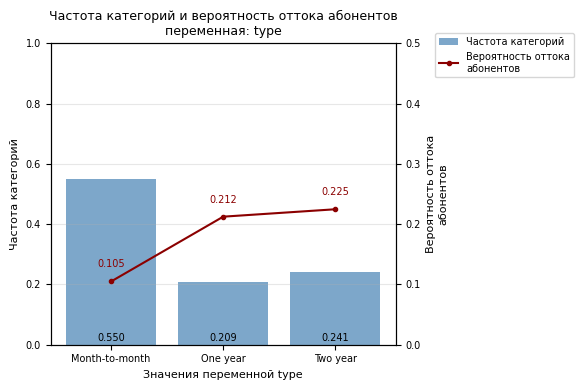

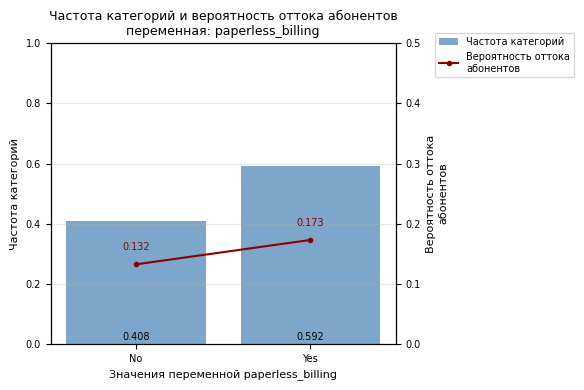

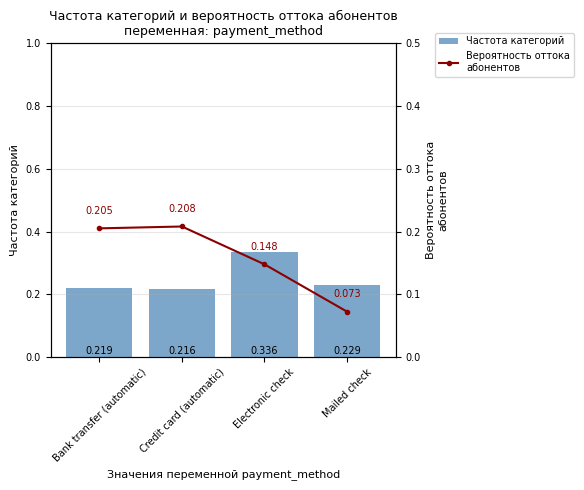

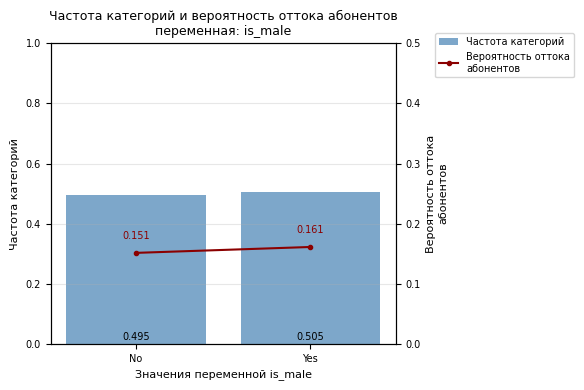

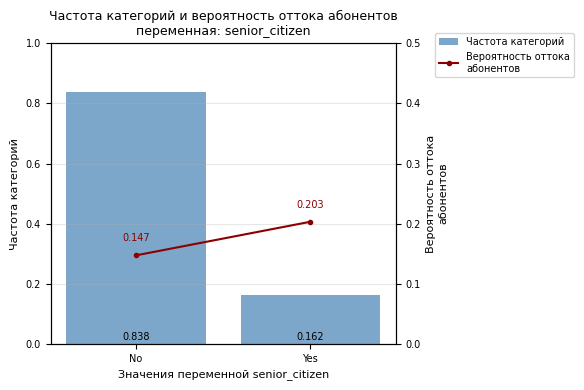

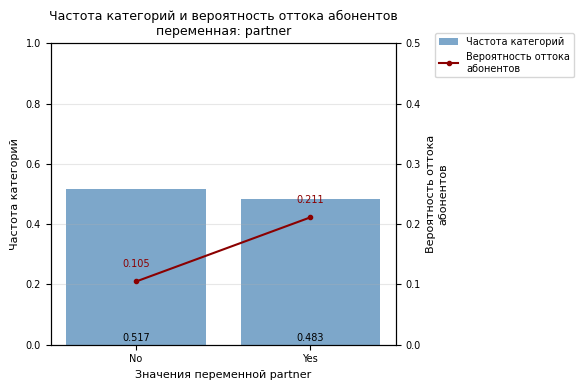

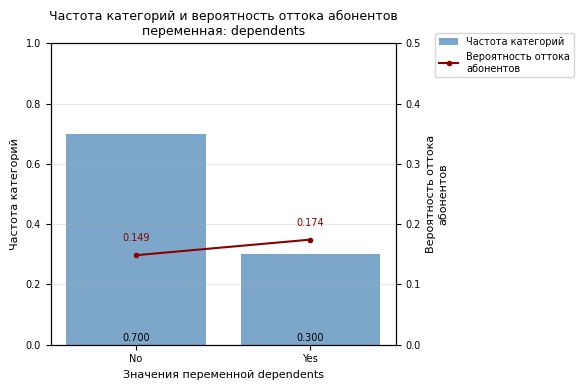

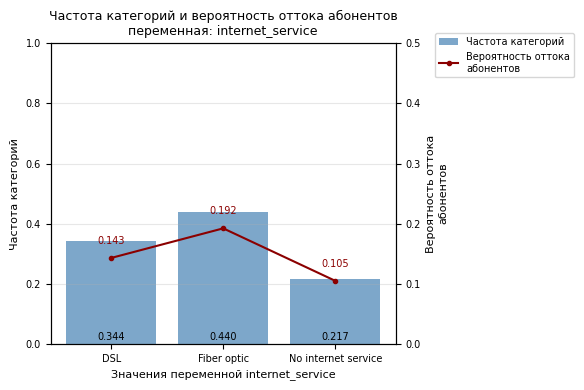

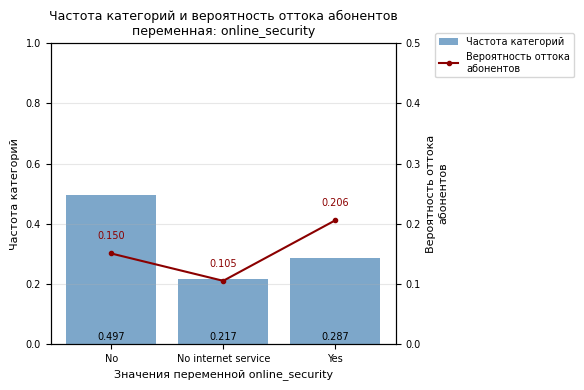

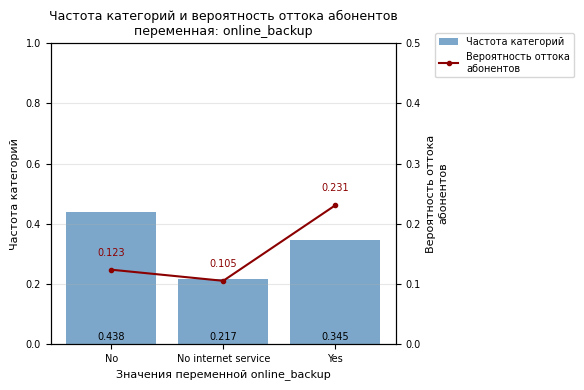

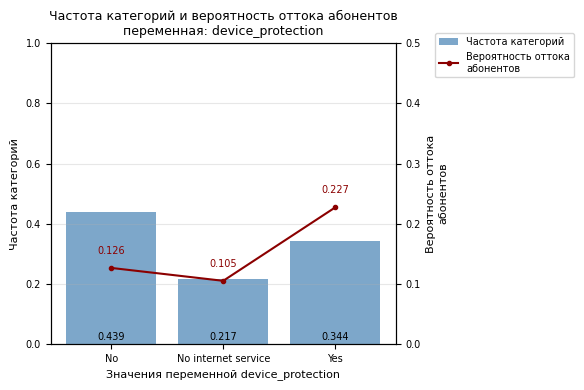

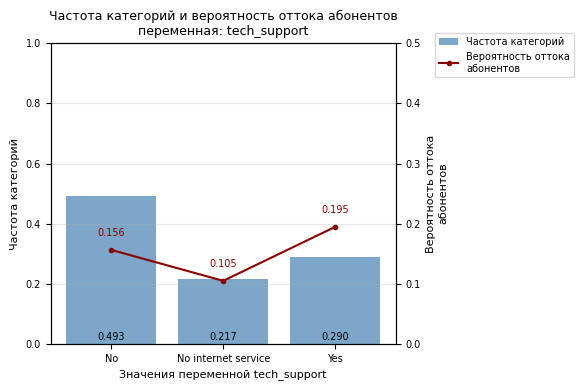

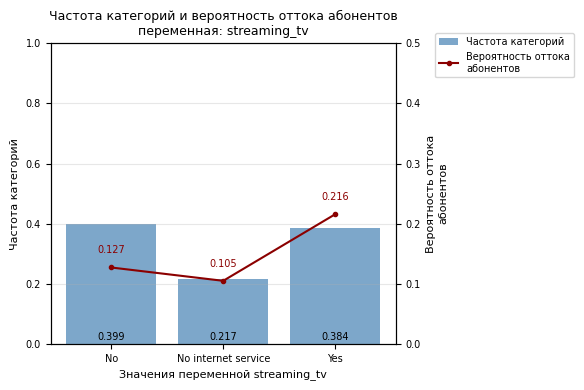

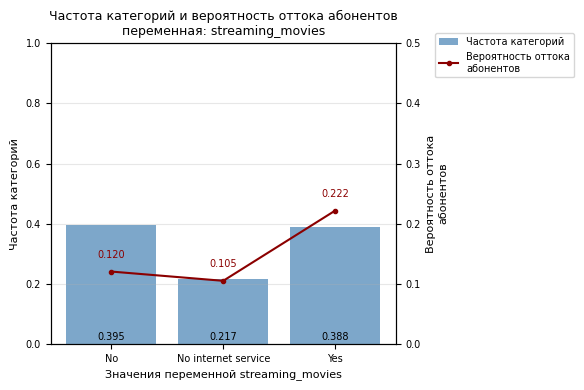

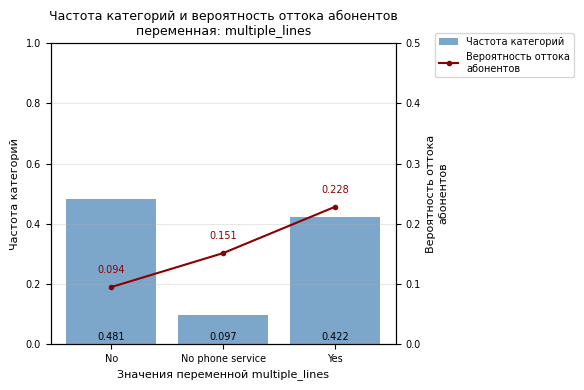

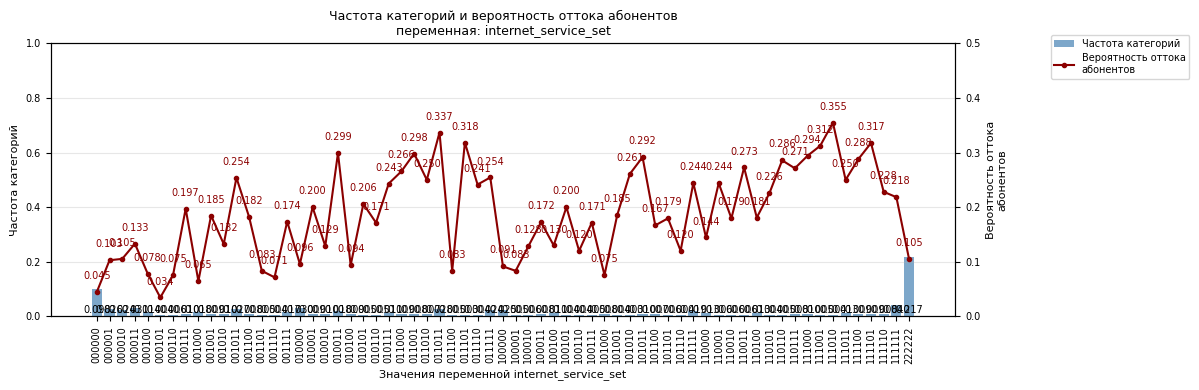

In [82]:
# Общее количество записей для расчета долей
total_records = len(df_all)

# графики в цикле
for col in cat_cols_all:
    # Подготовка данных
    chart_data = df_all.groupby(col).agg(
        total_count=('target', 'size'),  # Считаем общее количество записей
        out_sum=('target', lambda x: (x == 1).sum())  # Считаем количество ушедших абонентов (target=1)
    ).reset_index()

    # Вычисляем вероятность оттока (сумма 1 / общее количество)
    chart_data['out_ratio'] = chart_data['out_sum'] / chart_data['total_count']

    # Удаляем временный столбец
    chart_data.drop(columns=['out_sum'], inplace=True)

    # Преобразуем абсолютные частоты в доли (от 0 до 1)
    chart_data['total_ratio'] = chart_data['total_count'] / total_records

    # Для бинарных переменных сортируем по возрастанию значений (0, затем 1)
    chart_data.sort_values(by=col, ascending=True, inplace=True)

    # Единый словарь настроек для специальных колонок
    col_settings = {
        'payment_method':       {'figsize': (6, 5),  'x_rot': 45},
        'internet_service_set': {'figsize': (12, 4),  'x_rot': 90},
    }

    # Дефолтные значения
    defaults = {'figsize': (6, 4), 'x_rot': 0}
    settings = col_settings.get(col, defaults)

    # Вызов функции
    plot_bar_and_line_chart(
        df=chart_data,
        x_col=col,
        bar_y_col='total_ratio',
        line_y_col='out_ratio',
        title=f'Частота категорий и вероятность оттока абонентов\nпеременная: {col}',
        bar_y_label='Частота категорий',
        line_y_label='Вероятность оттока\nабонентов',
        x_label=f'Значения переменной {col}',
        x_rot=settings['x_rot'], # в части переменных - с поворотом
        decimals=3,
        line_decimals=3,
        line_offset=0.02,
        figsize=settings['figsize'] # в части переменных  - иной размер
    )

*Наблюдения - категориальные переменные*:
- в переменной `type`:
  - нужно *объединить категории One Year и Two Year в одну* (это логично с точки зрения бизнеса и подтверждается тем, что вероятность оттока абонентов в данных категориях мало различается);
  - переменную `type` таким образом переведем в бинарную (новое имя переменной - `monthly_pay`) со значением No/Yes (тип платежей ежемесячный No (0) / Yes (1));
- в переменной `payment_method`:
  - нужно *объединить категории с автоматическими платежами в одну* (это логично с точки зрения бизнеса и подтверждается тем, что вероятность оттока абонентов в данных категориях мало различается);
- в прочих категориальных переменных никаких преобразований не требуется (вероятность оттока абонентов в категориях различается существенно).

### Числовые переменные

In [83]:
df_all[non_binary_cols_all].nunique()

monthly_charges    1585
total_charges      6658
duration            251
num_services          9
1_serv_cost        1412
dtype: int64

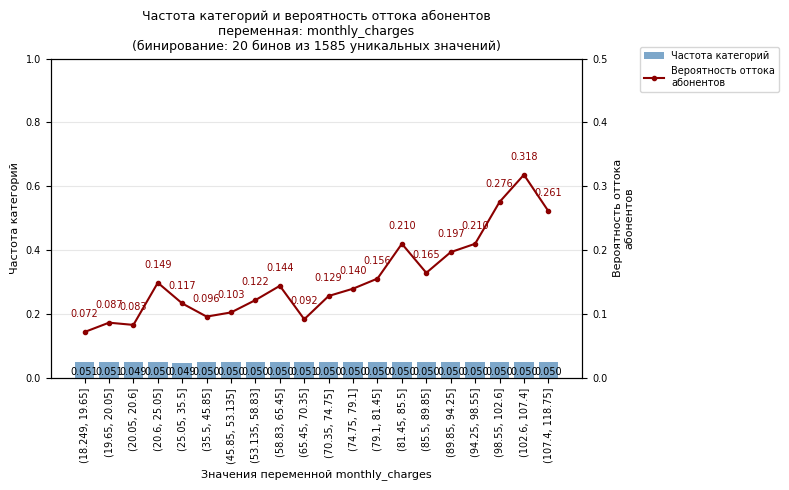

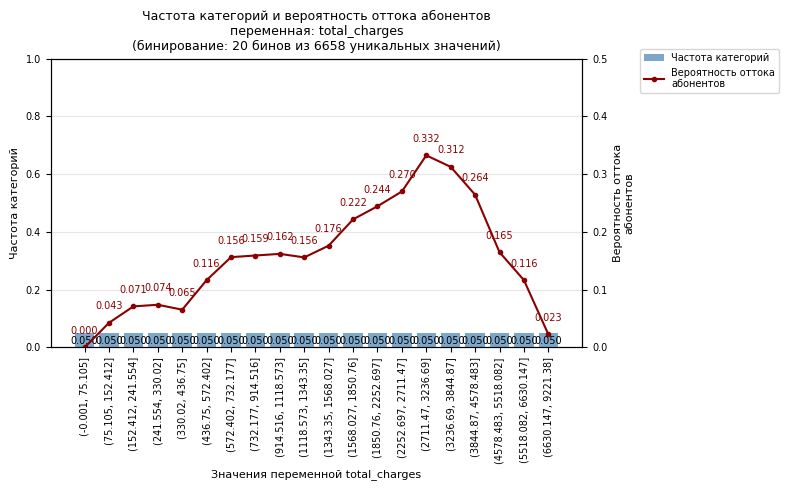

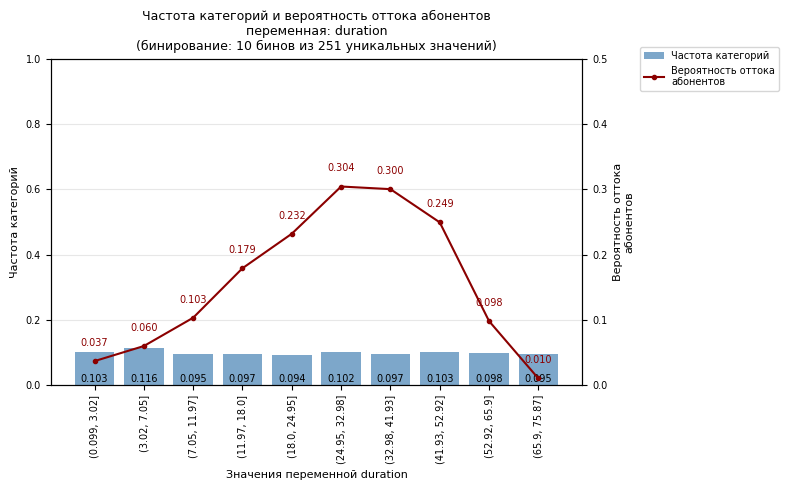

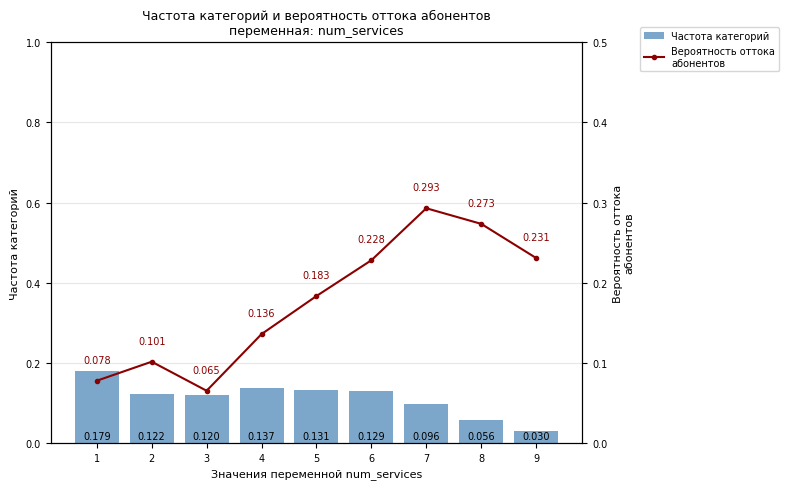

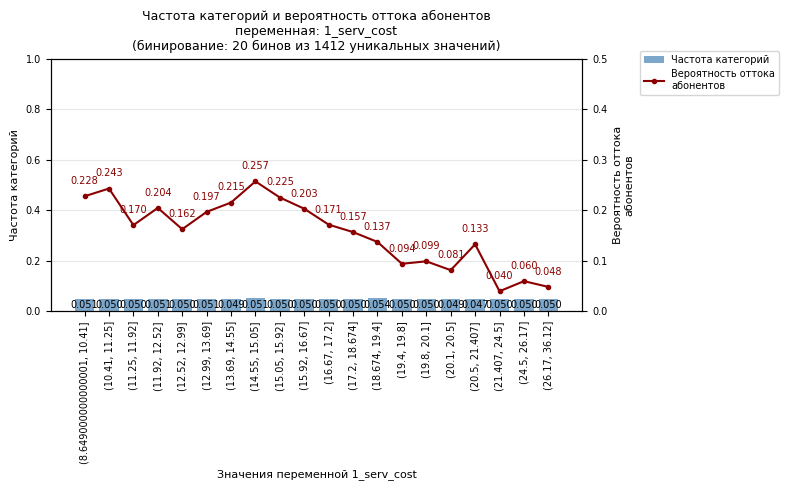

In [84]:
# Словарь с индивидуальным количеством бинов для конкретных колонок
custom_bins = {
    'monthly_charges': 20,
    'total_charges': 20,
    'num_services': 9,
    '1_serv_cost': 20
}

# Значение по умолчанию для колонок, которых нет в словаре
default_bins = 10

# графики в цикле для числовых переменных
for col in non_binary_cols_all:
    n_unique = df_all[col].nunique()

    # Определяем, нужно ли бинирование
    if n_unique <= 20:
        # Мало уникальных значений — используем как есть
        chart_data = df_all.copy()
        x_col_name = col
    else:
        # Много уникальных значений — создаем бины
        # Проверяем, задано ли количество бинов вручную для этой колонки
        if col in custom_bins:
            n_bins = custom_bins[col]
        else:
            # Иначе используем значение по умолчанию
            n_bins = default_bins

        # Создаем бины с помощью qcut (равное количество наблюдений в каждом бине)
        chart_data = df_all.copy()
        chart_data[f'{col}_bin'] = pd.qcut(chart_data[col], q=n_bins, duplicates='drop')
        x_col_name = f'{col}_bin'

    # Подготовка данных (аналогично бинарным переменным)
    chart_data_grouped = chart_data.groupby(x_col_name).agg(
        total_count=('target', 'size'),
        out_sum=('target', lambda x: (x == 1).sum())
    ).reset_index()

    # Вычисляем вероятность оттока
    chart_data_grouped['out_ratio'] = chart_data_grouped['out_sum'] / chart_data_grouped['total_count']
    chart_data_grouped.drop(columns=['out_sum'], inplace=True)

    # Преобразуем в доли
    chart_data_grouped['total_ratio'] = chart_data_grouped['total_count'] / total_records

    # Сортировка по возрастанию значений (для бининга это естественный порядок интервалов)
    chart_data_grouped.sort_values(by=x_col_name, ascending=True, inplace=True)

    n_categories = len(chart_data_grouped)

    # Формируем заголовок с информацией о бининге
    if n_unique > 20:
        title_suffix = f'\n(бинирование: {n_categories} бинов из {n_unique} уникальных значений)'
    else:
        title_suffix = ''

    # Вызов функции
    plot_bar_and_line_chart(
        df=chart_data_grouped,
        x_col=x_col_name,
        bar_y_col='total_ratio',
        line_y_col='out_ratio',
        title=f'Частота категорий и вероятность оттока абонентов\nпеременная: {col}{title_suffix}',
        bar_y_label='Частота категорий',
        line_y_label='Вероятность оттока\nабонентов',
        x_label=f'Значения переменной {col}',
        x_rot=0 if col == 'num_services' else 90,
        decimals=3,
        line_decimals=3,
        line_offset=0.02,
        figsize=(8, 5)
    )

*Наблюдения - числовые переменные*:
- по всем числовым переменным распределения целевой переменной (вероятности оттока абонентов) существенно различаются (по значениям/бинам разбиений переменных);
- закономерности при этом отмечаются различные, например:
  - чем выше ежемесячные расходы, тем выше вероятность оттока абонентов, в целом прослеживается восходящий тренд;
  - по иным переменным однозначных трендов нет.

### Выводы: Целевая VS Предикторы

---

| Показатель | Что отмечено | Примечание |
|------------|------------------|------------|
| `is_male` | Влияние переменной `is_male` на целевую переменную малозначимо (пол абонента на вероятность оттока абонентов практически не влияет). | Переменная `is_male` - кандидат на исключение из набора предикторов. Влияние прочих переменных на целевую переменную существенно (т.е. существенно различается вероятность оттока абонентов в зависимости от значения предиктора).|
| `type` | Нужно *объединить категории One Year и Two Year в одну* (это логично с точки зрения бизнеса и подтверждается тем, что вероятность оттока абонентов в данных категориях мало различается). | Переменную `type` таким образом переведем в бинарную (новое имя переменной - `monthly_pay`) со значением No/Yes (тип платежей ежемесячный No (0) / Yes (1)). |
| `payment_method` | нужно *объединить категории с автоматическими платежами в одну* (это логично с точки зрения бизнеса и подтверждается тем, что вероятность оттока абонентов в данных категориях мало различается). | Переменная `payment_method` остается категориальной. |
| Прочие категориальные переменные | В прочих категориальных переменных никаких преобразований не требуется: вероятность оттока абонентов в категориях различается существенно. | --- |
| Числовые (не бинарные) переменные | По всем числовым переменным распределения целевой переменной (вероятности оттока абонентов) существенно различаются (по значениям/бинам разбиений переменных). | Закономерности отмечаются различные. |
| `total_charges` | Это кумулятивная сумма за весь период = monthly_charges × duration. Признак несёт ту же информацию, что и duration (срок договора) и является теоретической утечкой из признака duration. | Скорее всего признак `total_charges` нужно будет удалить из набора переменных. |



---
*Общие выводы*:

- Общий анализ влияния предикторов на целевую переменную произведен (по всем объединенным данным).
- Далее необходимо выполнить преоразования, отмеченные выше в таблице.

## Преобразования данных

По итогам анализа влияний предикторов на целевую переменную сделаем следующие преобразования данных:
- Переменная `type`:
  - объединим категории One Year и Two Year в одну;
  - переведем переменную `type` в бинарную:
    - новое имя переменной - `monthly_pay`;
    - значения переменной No/Yes: тип платежей ежемесячный нет (No) / да (Yes).
- Переменная `payment_method`:
  - объединим категории категории с автоматическими платежами в одну;
  - новое название категории - `automatic_pay`;
  - переменная `payment_method` остается категориальной.

In [85]:
# создаем копию датасета для работы
df_corr_all = df_all.copy()

In [86]:
type_unique = df_corr_all['type'].unique().tolist()
print(type_unique)

['Month-to-month', 'One year', 'Two year']


In [87]:
pay_unique = df_corr_all['payment_method'].unique().tolist()
print(pay_unique)

['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


In [88]:
# Словарь для замены значений - 1
type_mapping = {
    type_unique[0]: 'Yes',
    type_unique[1]: 'No',
    type_unique[2]: 'No'}

# Словарь для замены значений - 2
payment_method_mapping = {
    pay_unique[2]: 'Automatic pay',
    pay_unique[3]: 'Automatic pay'}

# Применяем замены
df_corr_all['type'] = df_corr_all['type'].map(type_mapping) # map - подходит
# здесь - map не подходит (выдаст чатсь значений как NaN, берем replace)
df_corr_all['payment_method'] = df_corr_all['payment_method'].replace(payment_method_mapping)

# Переименовываем колонку type на месте
df_corr_all = df_corr_all.rename(columns={'type': 'monthly_pay'})

In [89]:
# Проверка результата
print(df_corr_all['monthly_pay'].value_counts())
print(df_corr_all['payment_method'].value_counts())

monthly_pay
Yes    3875
No     3168
Name: count, dtype: int64
payment_method
Automatic pay       3066
Electronic check    2365
Mailed check        1612
Name: count, dtype: int64


In [90]:
df_corr_all[['monthly_pay', 'payment_method']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   monthly_pay     7043 non-null   object
 1   payment_method  7043 non-null   object
dtypes: object(2)
memory usage: 110.2+ KB


## Анализ корреляций (Phi_k)

### Отбор переменных

Отберем переменные для анализа корреляций

In [91]:
# Переменные, которые не анализируем, но пока не удаляем
cols_not_to_analyze = ['customer_id', 'begin_date', 'end_date']

In [92]:
# выделение целевой переменной
target = 'target'

In [93]:
# Получаем список всех числовых колонок
num_cols_corr = df_corr_all.select_dtypes(
    include=['number']).columns.tolist()

# Убираем таргет, если он там есть
num_cols_corr = [col for col in num_cols_corr if col != target]

# Убираем неанализируемые колонки
num_cols_corr = [col for col in num_cols_corr if col not in cols_not_to_analyze]

# Разделяем числовые на бинарные и непрерывные
binary_cols_corr = []
non_binary_cols_corr = []

for col in num_cols_corr:
    unique_vals = df_corr_all[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}) and len(unique_vals) <= 2:
        binary_cols_corr.append(col)
    else:
        non_binary_cols_corr.append(col)

In [94]:
# Получаем список всех нечисловых колонок и не дат
cat_cols_corr = df_corr_all.select_dtypes(
    exclude=['number']).columns.tolist()

# Убираем таргет, если он там есть
cat_cols_corr = [col for col in cat_cols_corr if col != target]

# Убираем неанализируемые колонки
cat_cols_corr = [col for col in cat_cols_corr if col not in cols_not_to_analyze]

In [95]:
print("Целевая переменная:")
print(target)

print("\nБинарные колонки (0/1):")
print(binary_cols_corr)

print("\nЧисловые небинарные колонки:")
print(non_binary_cols_corr)

print("\nКатегориальные колонки:")
print(cat_cols_corr)

Целевая переменная:
target

Бинарные колонки (0/1):
[]

Числовые небинарные колонки:
['monthly_charges', 'total_charges', 'duration', 'num_services', '1_serv_cost']

Категориальные колонки:
['monthly_pay', 'paperless_billing', 'payment_method', 'is_male', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'internet_service_set']


In [96]:
# общий список колонок в порядке их анализа
all_cols_corr = [target] + binary_cols_corr + non_binary_cols_corr + cat_cols_corr

# выводим число уникальных значений и типы данных по столбцам
display(
    pd.DataFrame({
    'Unique Values': df_corr_all[all_cols_corr].nunique(),
    'Data Type': df_corr_all[all_cols_corr].dtypes
    })
)

,Unique Values,Data Type
target,2,float64
monthly_charges,1585,float64
total_charges,6658,float64
duration,251,float64
num_services,9,int64
1_serv_cost,1412,float64
monthly_pay,2,object
paperless_billing,2,object
payment_method,3,object
is_male,2,object


В анализ включаются все указанные выше переменные.

### Анализ корреляций

Первичный расчет кореляций

In [97]:
# создание матрицы корреляций (PhiK)
phik_matrix = df_corr_all[all_cols_corr].phik_matrix(
    interval_cols=non_binary_cols_corr)

# создание матрицы значимости (Z-скоры)
phik_significance = significance_matrix(
    df_corr_all[all_cols_corr],
    interval_cols=non_binary_cols_corr,
    significance_method='hybrid',
    lambda_='log-likelihood',
    nsim=100,
    njobs=-1
)

# расчет p-value через sf() - защита от потери точности
phik_p_value = 2 * stats.norm.sf(phik_significance.abs().values)

# сборка итоговой матрицы
phik_p_value_matrix = pd.DataFrame(
    phik_p_value,
    index=phik_significance.index,
    columns=phik_significance.columns
)

# диагональ p-value не имеет смысла -> NaN
np.fill_diagonal(phik_p_value_matrix.values, np.nan)

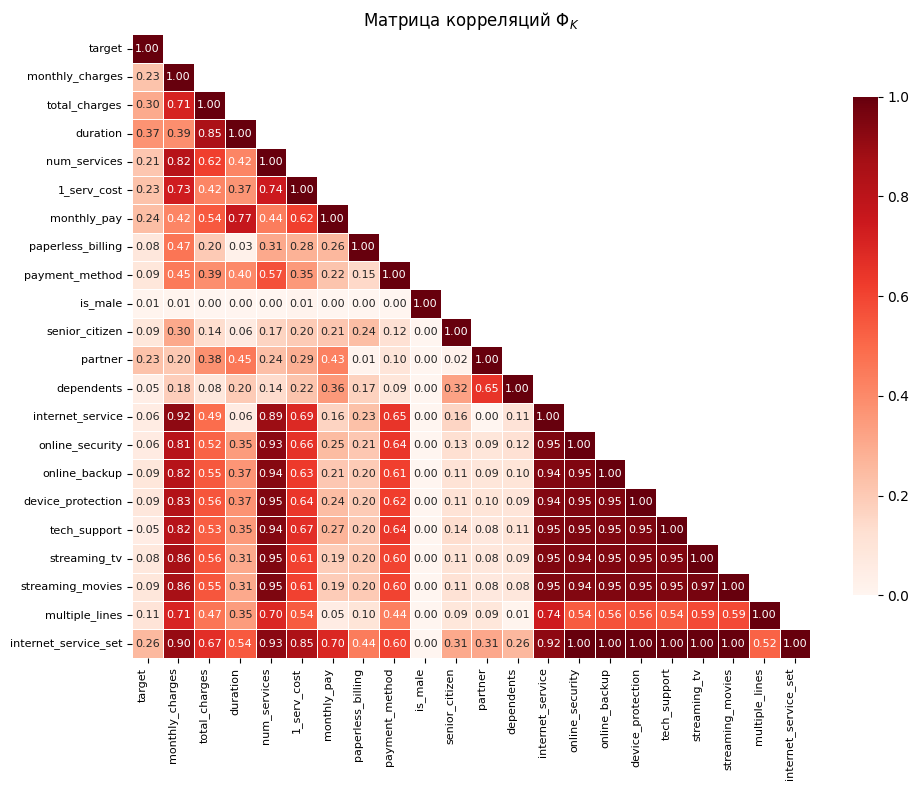

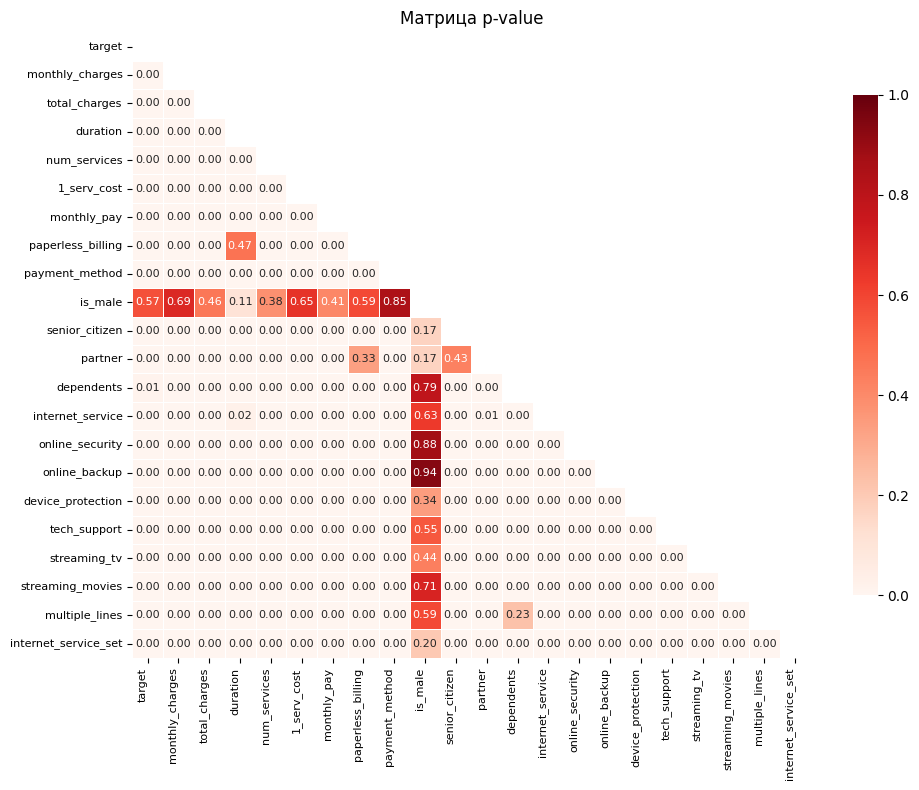

In [98]:
# вывод heatmap с отсечением верхней треугольной части
heatmap_show(phik_matrix, 'Матрица корреляций $\\Phi_K$', show_upper_triangle=False)
heatmap_show(phik_p_value_matrix, 'Матрица p-value', show_upper_triangle=False)

In [99]:
# фиксация целевой переменной
target_variable = target
exclude_rows = [target_variable]

# выборки из построенных таблиц корреляций и p-value
corr_phik_target = pd.concat(
    [
        phik_matrix.loc[~phik_matrix.index.isin(exclude_rows), [target_variable]],
        phik_p_value_matrix.loc[
            ~phik_p_value_matrix.index.isin(exclude_rows), [target_variable]
        ],
    ],
    axis=1)

corr_phik_target.columns = ['phi_k', 'p_value']

# вывод анализа корреляций (PhiK) для целевой переменной
corr_phik_target[['strength_of_connection', 'significance']] = \
corr_phik_target.apply(corr_interpretation, axis=1, result_type='expand')
corr_phik_target = corr_phik_target.sort_values(by='phi_k', ascending=False)

display(HTML(f"<b style='color: green;'>Корреляции целевой переменной с входными признаками</b>"))
display(corr_phik_target)

num_hi = corr_phik_target[corr_phik_target['strength_of_connection']
    .isin(['очень сильная','сильная','умеренная'])]['strength_of_connection'].count()

display(HTML(f"<span style='color: green;'>Сильные и умеренные корреляции: {num_hi} шт.</span>"))
display(HTML(f"<span style='color: green;'>Слабые и не значимые корреляции: {corr_phik_target.shape[0] - num_hi} шт.</span>"))

,phi_k,p_value,strength_of_connection,significance
duration,0.375,0.000,умеренная,значимая
total_charges,0.303,0.000,умеренная,значимая
internet_service_set,0.256,0.000,слабая,значимая
monthly_pay,0.242,0.000,слабая,значимая
1_serv_cost,0.227,0.000,слабая,значимая
partner,0.227,0.000,слабая,значимая
monthly_charges,0.226,0.000,слабая,значимая
num_services,0.211,0.000,слабая,значимая
multiple_lines,0.105,0.000,слабая,значимая
online_backup,0.090,0.000,очень слабая,значимая


In [100]:
# Пороги для корреляций и p-value
corr_tsh = 0.80
p_value_tsh = 0.05

# Удаляем целевую переменную из обеих таблиц
phik_filtered = phik_matrix.drop(index=target_variable, columns=target_variable)
p_value_filtered = phik_p_value_matrix.drop(index=target_variable, columns=target_variable)

# Создаем маску для значимых корреляций, НЕ учитывем главную диагональ
mask_diag = ~np.eye(len(phik_filtered), dtype=bool)
mask = (phik_filtered.abs() >= corr_tsh) & (p_value_filtered < p_value_tsh) & mask_diag

# Применяем маску к обеим таблицам
phik_significant = phik_filtered.where(mask)
p_value_significant = p_value_filtered.where(mask)

# Удаляем полностью пустые строки и столбцы
phik_significant = phik_significant.dropna(axis=0, how='all').dropna(axis=1, how='all')
p_value_significant = p_value_significant.dropna(axis=0, how='all').dropna(axis=1, how='all')

# Создаем список пар признаков с высокой и значимой корреляцией
significant_pairs = []
for i in range(len(phik_significant.index)):
    for j in range(i + 1, len(phik_significant.columns)):
        row_idx = phik_significant.index[i]
        col_idx = phik_significant.columns[j]
        if mask.loc[row_idx, col_idx]:
            significant_pairs.append((row_idx, col_idx,
                                      phik_significant.loc[row_idx, col_idx],
                                      p_value_significant.loc[row_idx, col_idx]))

# Создаём DataFrame из списка
df_significant_pairs = pd.DataFrame(significant_pairs,
                                    columns=['var_1', 'var_2', 'phi_k', 'p_value']
                                   ).sort_values(by='phi_k', ascending=False).reset_index(drop=True)

df_significant_pairs[['strength_of_connection', 'significance']] = \
df_significant_pairs.apply(corr_interpretation, axis=1, result_type='expand')

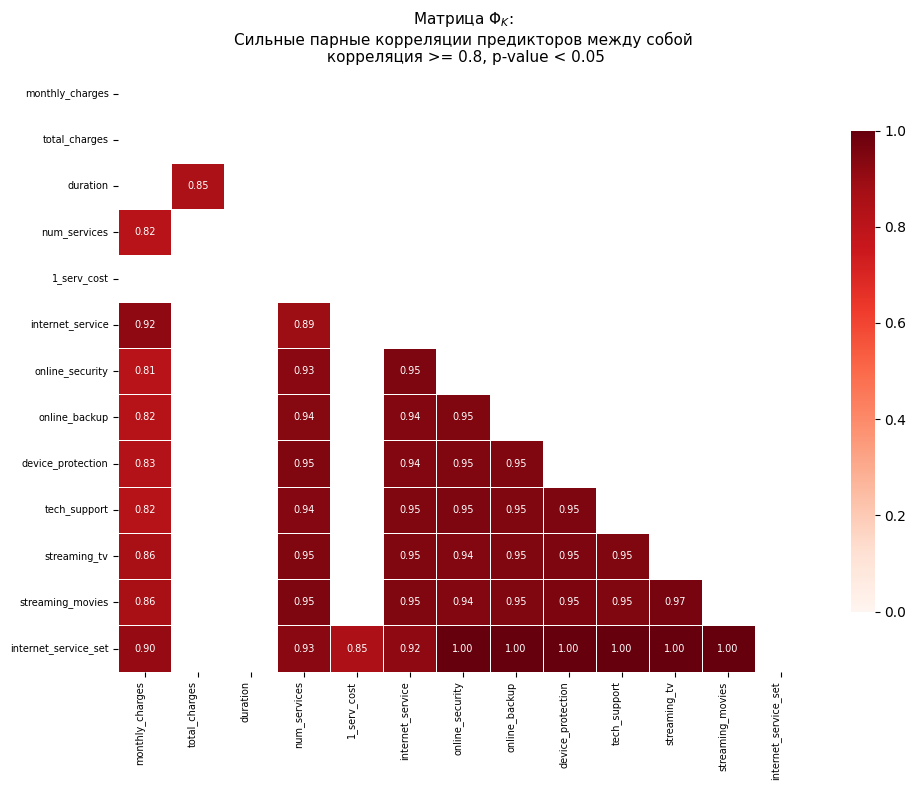

,var_1,var_2,phi_k,p_value,strength_of_connection,significance
0,streaming_tv,internet_service_set,1.000,0.000,функциональная,значимая
1,online_security,internet_service_set,1.000,0.000,функциональная,значимая
2,online_backup,internet_service_set,1.000,0.000,функциональная,значимая
3,tech_support,internet_service_set,1.000,0.000,функциональная,значимая
4,device_protection,internet_service_set,1.000,0.000,функциональная,значимая
5,streaming_movies,internet_service_set,1.000,0.000,функциональная,значимая
6,streaming_tv,streaming_movies,0.965,0.000,очень сильная,значимая
7,device_protection,streaming_movies,0.954,0.000,очень сильная,значимая
8,device_protection,streaming_tv,0.953,0.000,очень сильная,значимая
9,online_security,tech_support,0.953,0.000,очень сильная,значимая


In [101]:
# тепловая карта - значимые корреляции входных признаков
heatmap_show (phik_significant,
              f"Матрица $\\Phi_K$:\nСильные парные корреляции предикторов между собой\n корреляция >= {corr_tsh}, p-value < {p_value_tsh}",
              figsize=(10, 8),
              font_size=7,
              cmap='Reds',
              show_upper_triangle=False)

# Таблица - входные признаки со значимыми парными корреляциями
display(HTML(f"<b style='color: green;'>Входные признаки со значимыми парными корреляциями</b>"))
display(df_significant_pairs)

**Выводы - анализ корреляций**:

---
1. Явные утечки
- `total_charges` (корреляция с target: 0.304):
  - Это кумулятивная сумма = monthly_charges × duration;
  - срок  это утечка из сформированного признака duration;
  - высокая взаимная корреляция это подтверждает.
- `internet_service_set` (корреляция с target: 0.256):
  - Это переменная сформирована из набора 6-ти полей (список интернет-услуг);
  - это естественная утечка данных при формировании признака `internet_service_set`;
  - высокая взаимная корреляция это подтверждает.

- Решение: ***Удаляем явные утечки***
- ***`total_charges`***
- ***`online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`***.

---
2. Бесполезный шум — УДАЛЯТЬ
- `is_male`:
  - Корреляция с target: 0.009. Корреляция со всеми остальными признаками: менее 0.01.
  - Пол клиента в этом датасете абсолютно не влияет ни на отток, ни на выбор услуг;
  - Это чистый шум, который только добавляет лишний шум при построении деревьев/бустинге.
- Решение: ***удаляем `is_male`*** .

---
3. Дублирующая информация
- `num_services` (корреляции с услугами: 0.89-0.95)
  - Это математическая сумма бинарных признаков услуг
  - Модель получает одну информацию дважды: в деталях и в агрегате
  - Можно удалить - Деревья/Бустинг сами найдут комбинации из детальных признаков
- Решение: ***удаляем (опционально) дублирующиеся признаки***

---
4. Что оставляем (все легитимно)
- `mothly_pay` (корреляция с target: 0.243)
  - Это бинарный признак (Yes/No) - платит клиент ежемесячно или нет
  - Полезная информация о типе контракта, НЕ утечка
  - Решение: ***Оставляем***
- `monthly_charges` (корреляция с услугами: 0.8-0.9)
  - Да, сильно коррелирует со списком услуг — это естественная бизнес-логика
  - Больше услуг = выше ежемесячный чек
  - Это НЕ утечка, а полезный сигнал о стоимости пакета
  - Решение: ***Оставляем***

---
5. Мультиколлинеарность по набору интернет-услуг (0.94-0.97)
- исходные переменные по набору интернет-услуг были свернуты в агрегат; агрегат оставляем, исходные переменные - удаляем.
- Решение: ***Удаляем - `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`***


---
**Резюме**:
- принято решение удалить из набора признаков следующие предикторы:
  - `total_charges`:  утечка данных из признака `duration`;
  - `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`: эти признаки были свернуты в агрегат;
  - `is_male`: малозначимый для таргета/бесполезный шум;
- кандидатами на удаление рассматриваются следующие предикторы:
  - `num_services`, `monthly_charges`.

### Анализ мультиколлинеарности

***Принципы отбора признаков следующие***:

- рассчитываем число обусловленности матрицы корреляций начального набора входных признаков;
- исключаем входные признаки, выбранные на этапе корреляционного анализа (см. выше);
- рассчитываем число обусловленности матрицы корреляций после исключения части входных признаков;
- сравниваем показатели до и после исключения признаков и делаем выводы.

---
*Принята следующая градация степени мультиколлинеарности (Belsley, D. A., Kuh, E., & Welsch, R. E. (1980) — Regression Diagnostics: Identifying Influential Data and Sources of Collinearity)*:

| Диапазон числа обусловленности | Степень мультиколлинеарности | Интерпретация |
|:---------------:|:-------------:|:----------------:|
| 1 ≤ cond < 10 | Отсутствует / Слабая | Норма для моделирования. Нет серьезных проблем с интерпретацией коэффициентов. |
| 10 ≤ cond < 30 | Умеренная | Возможны нестабильности в оценках. Требует внимания при интерпретации. |
| ≥ 30 | Сильная | Критическая мультиколлинеарность. Риск численной неустойчивости прогноза. |

**Расчет по начальному набору переменных.**

In [102]:
cols_filtered_0 = [col for col in all_cols_corr if col!=target]

# список
print(f"Список переменных - все:\n{cols_filtered_0}")

Список переменных - все:
['monthly_charges', 'total_charges', 'duration', 'num_services', '1_serv_cost', 'monthly_pay', 'paperless_billing', 'payment_method', 'is_male', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines', 'internet_service_set']


In [103]:
# фильтруем матрицу корреляций и считаем число обусловленности
filtered_matrix_0 = phik_matrix.loc[cols_filtered_0, cols_filtered_0]

# Вычисляем число обусловленности
condition_number_0 = round(np.linalg.cond(filtered_matrix_0.to_numpy(), p=2),2)

print(f"Число обусловленности матрицы корреляций входных признаков\nначальный набор переменных: {condition_number_0}")

Число обусловленности матрицы корреляций входных признаков
начальный набор переменных: 490.55


**Расчет по отфильтрованному набору переменных - 1.**

In [104]:
# переменные, которые точно нужно удалить из модели
# откровенно слабые корреляции и утечки данных
cols_to_exclude_1 = ['is_male', 'total_charges',
                     'online_security', 'online_backup',
                     'device_protection', 'tech_support',
                     'streaming_tv', 'streaming_movies']

In [105]:
cols_filtered_1 = [col for col in cols_filtered_0 if col not in cols_to_exclude_1]

# список
print(f"Список переменных - после удаления части предикторов - 1:\n{cols_filtered_1}")

Список переменных - после удаления части предикторов - 1:
['monthly_charges', 'duration', 'num_services', '1_serv_cost', 'monthly_pay', 'paperless_billing', 'payment_method', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'multiple_lines', 'internet_service_set']


In [106]:
# фильтруем матрицу корреляций и считаем число обусловленности
filtered_matrix_1 = phik_matrix.loc[cols_filtered_1, cols_filtered_1]

# Вычисляем число обусловленности
condition_number_1 = round(np.linalg.cond(filtered_matrix_1.to_numpy(), p=2),2)

print(f"Число обусловленности матрицы корреляций входных признаков\nотфильтрованный набор переменных - 1: {condition_number_1}")

Число обусловленности матрицы корреляций входных признаков
отфильтрованный набор переменных - 1: 273.38


**Расчет по отфильтрованному набору переменных - 2.**

In [107]:
# переменные, которые потенциально можно удалить из модели
# дублирующиеся данные
cols_to_exclude_2 = ['num_services', 'monthly_charges']

In [108]:
cols_filtered_2 = [col for col in cols_filtered_1 if col not in cols_to_exclude_2]

# список
print(f"Список переменных - после удаления части предикторов - 2:\n{cols_filtered_2}")

Список переменных - после удаления части предикторов - 2:
['duration', '1_serv_cost', 'monthly_pay', 'paperless_billing', 'payment_method', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'multiple_lines', 'internet_service_set']


In [109]:
# фильтруем матрицу корреляций и считаем число обусловленности
filtered_matrix_2 = phik_matrix.loc[cols_filtered_2, cols_filtered_2]

# Вычисляем число обусловленности
condition_number_2 = round(np.linalg.cond(filtered_matrix_2.to_numpy(), p=2),2)

print(f"Число обусловленности матрицы корреляций входных признаков\nотфильтрованный набор переменных - 2: {condition_number_2}")

Число обусловленности матрицы корреляций входных признаков
отфильтрованный набор переменных - 2: 268.58


**Вывод - мультиколлинеарность входных признаков**.

---
*ШАГ 0*:

Начальный набор входных признаков:
- число обусловленности матрицы корреляций входных признаков: 490.55 (очень много);
- степень мультиколлинеарности набора предикторов очень высокая.

---
*ШАГ 1*:

После исключения признаков с ничтожно малыми корреляциями с таргетом и устранения утечки данных:
- были исключены признаки: `is_male`, `total_charges`, `is_male`, `total_charges`, `online_security`, `online_backup`,
`device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`;
- число обусловленности матрицы корреляций входных признаков существенно уменьшилось с 490.55 до 273.38:
  - все еще много, но существенно меньше чем на Шаге 0;
  -***удаление признаков из набора - оправдано***;
- степень мультиколлинеарности набора предикторов высокая.

*ШАГ 2*:

После исключения признаков кандидатов на удаление:
- были исключены признаки: `num_services`, `monthly_charges`;
- число обусловленности матрицы корреляций после фильтрации признаков уменьшилось с 273.38 до 268.58:
  - значение уменьшилось НЕсущественно относительно Шага 1;
  - ***удаление признаков из набора - НЕ оправдано***.

## Выводы - корреляционный анализ

---
**Резюме**:
- принято решение удалить из набора признаков следующие предикторы:
  - `total_charges`:  утечка данных из признака `duration`;
  - `online_security`, `online_backup`, `device_protection`, `tech_support`, `streaming_tv`, `streaming_movies`: эти признаки были свернуты в агрегат;
  - `is_male`: малозначимый для таргета/бесполезный шум;
- кандидатами на удаление рассматривались следующие предикторы:
  - `num_services`, `monthly_charges`;
  - данные переменные были оставлены в наборе предикторов.

---
***Главные выводы - анализ корреляций***:

- Часть входных признаков были исключены из модели (как утечка данных из иных признаков и как незначимые для таргета).
- Существенная мультиколлинеарность набора входных признаков (после удаления части признаков) является фактором настораживающим. *Однако, для нелинейных моделей фактор мультиколлинеарности может не играть решающей роли и не сильно снижать обобщающую спобность моделей*.

# Финальная подготовка данных для моделирования

**Что делаем**:
- копируем датасет;
- из датасета удаляем столбцы, не участвующие в моделировании;
- проверяем таблицу на дубликаты (после удаления части столбцов);
- разбиваем данные на train/test выборки.

**Выбор переменной для стратификации выборок (train/test)**:
- целевая переменная - НЕсбалансирована;
- *стратифицируем разбиение на выборки по целевой переменной*.

In [110]:
# копируем таблицу с данными
df_for_model = df_corr_all.copy()

## Удаление столбцов

In [111]:
# список столбцов для удаления
cols_to_exclude = cols_not_to_analyze + cols_to_exclude_1
print(f"Список столбцов для удаления из датасета: \n{cols_to_exclude}")

Список столбцов для удаления из датасета: 
['customer_id', 'begin_date', 'end_date', 'is_male', 'total_charges', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']


In [112]:
# предикторы, оставленные для моделирования
print(f"Предикторы, отобранные для моделирования:\n {cols_filtered_1}")

# таргет
print(f"Целевая переменная:\n {target}")

Предикторы, отобранные для моделирования:
 ['monthly_charges', 'duration', 'num_services', '1_serv_cost', 'monthly_pay', 'paperless_billing', 'payment_method', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'multiple_lines', 'internet_service_set']
Целевая переменная:
 target


In [113]:
# Фильтрация датасета по выбранным столбцам (предикторы + таргет)
df_for_model = df_for_model[[target] + cols_filtered_1]

In [114]:
df_for_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   target                7043 non-null   float64
 1   monthly_charges       7043 non-null   float64
 2   duration              7043 non-null   float64
 3   num_services          7043 non-null   int64  
 4   1_serv_cost           7043 non-null   float64
 5   monthly_pay           7043 non-null   object 
 6   paperless_billing     7043 non-null   object 
 7   payment_method        7043 non-null   object 
 8   senior_citizen        7043 non-null   object 
 9   partner               7043 non-null   object 
 10  dependents            7043 non-null   object 
 11  internet_service      7043 non-null   object 
 12  multiple_lines        7043 non-null   object 
 13  internet_service_set  7043 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 770.5+ KB


## Удаление дубликатов

In [115]:
# начальное число строк
initial_rows = df_for_model.shape[0]
print(f"Число строк до удаления дубликатов: {initial_rows}")

# удаление дубликатов строк
df_for_model.drop_duplicates(inplace=True, keep='first')

df_for_model.reset_index(drop=True)

# число строк после удаления
final_rows = df_for_model.shape[0]
print(f"Число строк после удаления дубликатов: {final_rows}")

# Процент удаленных строк
removed_percentage = ((initial_rows - final_rows) / initial_rows) * 100
print(f"Удаленно строк (дубликаты): {(initial_rows - final_rows)} ({removed_percentage:.2f}%)")

Число строк до удаления дубликатов: 7043
Число строк после удаления дубликатов: 6997
Удаленно строк (дубликаты): 46 (0.65%)


*Дубликаты в данных для  моделирования*:
- после исключения части полей в таблице появились дубликаты в данных;
- дубликаты были удалены, объем удаленных строк составляет 0,65% , что в целом незначительно;
- удаление дубликатов не повлияет на результаты исследования.

## Приведение колонок к категориальным

Колонки типа object переведем в тип category.

In [116]:
# Находим все колонки типа object
object_cols = df_for_model.select_dtypes(include=['object']).columns.tolist()

# Переводим их в тип category
df_for_model[object_cols] = df_for_model[object_cols].astype('category')

# проверяем итог
df_for_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6997 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   target                6997 non-null   float64 
 1   monthly_charges       6997 non-null   float64 
 2   duration              6997 non-null   float64 
 3   num_services          6997 non-null   int64   
 4   1_serv_cost           6997 non-null   float64 
 5   monthly_pay           6997 non-null   category
 6   paperless_billing     6997 non-null   category
 7   payment_method        6997 non-null   category
 8   senior_citizen        6997 non-null   category
 9   partner               6997 non-null   category
 10  dependents            6997 non-null   category
 11  internet_service      6997 non-null   category
 12  multiple_lines        6997 non-null   category
 13  internet_service_set  6997 non-null   category
dtypes: category(9), float64(4), int64(1)
memory usage: 393.0 KB


## Разделение данных на выборки

*Разделение данных на выборки*:
- данные разделяем на обучающую и тестовую выборки;
- cоотношение объемов выборок: обучение/тест = 75/25 (задано в ТЗ);
- стратификация по целевой переменной: `target`.

Валидационная выборка не выделяется, т.к. при обучении моделей будет использоваться кросс-валидация.

In [117]:
# Разделение данных на обучающую и тестовую выборки
# со стратификацией по целевой переменной

# Выделяем признаки и целевую переменную
X = df_for_model.drop(columns=[target])
y = df_for_model[target]

# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE, # из заданной константы - 25%
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y
)

# Объединение признаков и целевой переменной в датасеты для дальнейшей работы
df_train = X_train.copy()
df_train[target[0]] = y_train.copy()
df_train.reset_index(drop=True, inplace=True)  # сброс индекса

df_test = X_test.copy()
df_test[target[0]] = y_test.copy()
df_test.reset_index(drop=True, inplace=True)  # сброс индекса

# Проверка размеров выборок
print(f"Размер выборок после разбиение датасета:")
print(f"Обучающая    : {len(df_train)} ({len(df_train)/len(df_for_model):.1%})")
print(f"Тестовая     : {len(df_test)} ({len(df_test)/len(df_for_model):.1%})")

# Проверка размерности данных
print(f"\nРазмерность данных после разбиение датасета:")
print(f"Обучающие    : {df_train.shape}")
print(f"Тестовые     : {df_test.shape}")

Размер выборок после разбиение датасета:
Обучающая    : 5247 (75.0%)
Тестовая     : 1750 (25.0%)

Размерность данных после разбиение датасета:
Обучающие    : (5247, 14)
Тестовые     : (1750, 14)


# Построение моделей ML

## Описание процесса построения моделей ML

---
**Цель**:
- построить модель машинного обучения (ML) для предсказания вероятности оттока абонентов telecom-компании (предоставление услуг домашнего интернета и стационарной телефонной связи).

---
**Описание решения**:

- Целевая переменная: target — бинарная переменная (0/1) где 1 означает, что абонент покинул компанию.
- Задача: Решается задача бинарной классификации.
- Методы: Модели ML строятся с использованием следующих алгоритмов:
  - Случайный лес (RandomForestClassifier).
  - CatBoost (CatBoostClassifier);
  - Полносвязная нейронная сеть.
- Подбор гиперпараметров:
  - первых двух моделей используется пайплайн, объединяющий предобработку данных и обучение, с последующим перебором гиперпараметров (через RandomizedSearchCV);
  - параметры полносвязной нейронной сети подбираются эмпирически (опытным путем).
- Оценка качества:
  - Обучение и подбор гиперпараметров проводятся с использованием кросс-валидации;
  - Целевая метрика: будет выбрана отдельно.

## Выбор метрики для оптимизации при обучении

---
**Что задано в ТЗ**:
- итоговая модель должна иметь метрику `ROC_AUC` не ниже 0.85.

---
**Выбор метрики - для оптимизации при обучении моделей ML**:

1. *Метрика при обучении*:
- при обучении моделей на основе деревьев и бустинга используется метрика `ROC_AUC`;
- при обучении моделей на основе FCN используется метрика `B_C_E` с учетом дисбаланса классов;
- метрика `ROC_AUC` отражает "общее качество ранжирования" - она одинаково хорошо оценивает модель и на классе 0, и на классе 1;
- у нас присуствует дисбаланс классов в целевой переменной примерно в соотношении 83/17 это означает:
  - модель при обучении "видит" кратно больше лояльных клиентов, чем уходящих;
  - модели проще улучшить ROC-AUC, просто научившись разделять 83% лояльных, чем "мучиться" с 17% уходящими;
  - метрика не чувствительна к порогу классификации - она оценивает общее ранжирование по классам, а не итоговые предсказания.

2. *Дополнительная метрика и подбор порога разделения классов*:
- рассматривается дополнительная `F2_beta` с `beta=2`, которая:
  - при β = 2 recall (полнота — ловля уходящих абонентов) получает в кратно больший вес, чем precision (точность);
  - учитывает, что пропуск уходящего клиента (FN) для компании в разы дороже ложной тревоги (FP);
  - работает с бинарным порогом (в отличие от ROC-AUC);
  - оптимум `F2` автоматически сдвигает порог в сторону "лучше перестраховаться";
  - это в целом "стандартная" метрика в задачах оттока клиентов для индустрии telecom;
- после обучения моделей *подбирается порог разделения классов исходя из максимизации метрики* `F2_beta`.

---
**Вывод**:
- при обучении моделей на основе деревьев и бустинга используется метрика `ROC_AUC`;
- при обучении моделей на основе FCN используется метрика `B_C_E` с учетом дисбаланса классов;
- после обучения моделей *подбирается порог разделения классов исходя из максимизации метрики* `F2_beta`.

## Общие переменные/константы

In [118]:
def print_and_save_cv_results(search_cv_object, X_train, y_train,
                              model_name, results_dict):
    """
    Выводит результаты CV на экран, находит оптимальный порог по F2,
    строит график и сохраняет расширенные метрики валидации в словарь.
    """
    print(f"--- Результаты для модели: {model_name} ---")
    print(f"Лучшие гиперпараметры: {search_cv_object.best_params_}\n")

    best_index = search_cv_object.best_index_
    cv_results = search_cv_object.cv_results_

    # 1. Извлекаем базовые метрики из cv_results_ (модель оптимизировалась по ROC-AUC)
    mean_val_roc_auc = cv_results['mean_test_roc_auc'][best_index]

    # 2. Получаем OOF (Out-of-Fold) вероятности для поиска оптимального порога
    best_model = search_cv_object.best_estimator_

    # ВАЖНО: method='predict_proba' возвращает вероятности для всех классов
    y_val_proba_oof = cross_val_predict(
        best_model, X_train, y_train,
        cv=search_cv_object.cv,
        method='predict_proba'
    )

    # Берем вероятность положительного класса (обычно это колонка с индексом 1)
    if y_val_proba_oof.ndim == 2:
        y_val_proba_oof = y_val_proba_oof[:, 1]

    # Приводим y_train к 1D массиву int для корректного сравнения
    y_train_num = (y_train.values.ravel()
                   .astype(int) if hasattr(y_train, 'values') else y_train.ravel()
                   .astype(int))

    # 3. Подбор порога по максимуму F2 (шаг 0.005)
    thresholds = np.arange(0.005, 1.0, 0.005)
    f2_scores = []

    for thresh in thresholds:
        y_pred_thresh = (y_val_proba_oof >= thresh).astype(int)
        f2 = fbeta_score(y_train_num, y_pred_thresh, beta=2, zero_division=0)
        f2_scores.append(f2)

    best_idx_thresh = np.argmax(f2_scores)
    best_threshold = thresholds[best_idx_thresh]
    max_f2_val = f2_scores[best_idx_thresh]

    # 4. Визуализация зависимости F2 от порога
    plt.figure(figsize=(6, 4))
    plt.plot(thresholds, f2_scores, label='F2-score (β=2)',
             color='tab:blue', linewidth=2)
    plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2,
                label=f'Оптимальный порог: {best_threshold:.3f}')

    # Динамический отступ для текста, чтобы он не наезжал на линию
    y_offset = max(f2_scores) * 0.03
    plt.text(best_threshold, max_f2_val + y_offset, f'F2 = {max_f2_val:.4f}',
             color='red', ha='center', va='bottom', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    plt.xlabel('Порог классификации (Threshold)')
    plt.ylabel('F2-score (β=2)')
    plt.title(f'Зависимость F2-score от порога классификации ({model_name})')
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.xlim(0, 1.0)
    plt.ylim(0, min(1.0, max_f2_val + 0.15)) # Ограничиваем верх, чтобы график был читаемым
    plt.tight_layout()
    plt.show()

    # 5. Расчет расширенных метрик на валидации с использованием ОПТИМАЛЬНОГО порога
    y_val_pred_optimal = (y_val_proba_oof >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train_num, y_val_pred_optimal).ravel()

    accuracy_val = accuracy_score(y_train_num, y_val_pred_optimal)
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr_val = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    f2_val_optimal = fbeta_score(y_train_num, y_val_pred_optimal, beta=2, zero_division=0)

    # 6. Вывод в красивом табличном формате
    print("Метрики лучшей модели (среднее по фолдам CV + метрики при оптимальном пороге):")
    print("-" * 75)
    print(f"{'Метрика':<35} | {'Значение':<15}")
    print("-" * 75)
    print(f"{'ROC-AUC (Val, CV mean)':<35} | {mean_val_roc_auc:<15.4f}")
    print(f"{'Оптимальный порог (Threshold)':<35} | {best_threshold:<15.3f}")
    print(f"{'F2 (Val) при опт. пороге':<35} | {f2_val_optimal:<15.4f}")
    print(f"{'Accuracy (Val) при опт. пороге':<35} | {accuracy_val:<15.4f}")
    print(f"{'FPR / Ошибка 1 рода (Val)':<35} | {fpr_val:<15.4f}")
    print(f"{'FNR / Ошибка 2 рода (Val)':<35} | {fnr_val:<15.4f}")
    print("-" * 75)

    # 7. Запись метрик в словарь (строго по запрошенным ключам + оптимальный порог)
    results_dict[model_name] = {
        "ROC-AUC (Val)": round(mean_val_roc_auc, 4),
        "Optimal Threshold": round(best_threshold, 3),
        "F2 (Val)": round(f2_val_optimal, 4),
        "Accuracy (Val)": round(accuracy_val, 4),
        "FPR (Val)": round(fpr_val, 4),
        "FNR (Val)": round(fnr_val, 4)
    }

    print(f"Метрики модели '{model_name}' успешно сохранены в models_results.\n")
    return results_dict

In [119]:
# выделение целевой переменной
target = 'target'

In [120]:
# Получаем список всех числовых колонок
num_cols_ml = df_for_model.select_dtypes(
    include=['number']).columns.tolist()

# Убираем таргет, если он там есть
num_cols_ml = [col for col in num_cols_ml if col != target]

# Разделяем числовые на бинарные и непрерывные
binary_cols_ml = []
non_binary_cols_ml = []

for col in num_cols_ml:
    unique_vals = df_for_model[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}) and len(unique_vals) <= 2:
        binary_cols_ml.append(col)
    else:
        non_binary_cols_ml.append(col)

In [121]:
# Получаем список всех нечисловых колонок и не дат
cat_cols_ml = df_for_model.select_dtypes(
    exclude=['number']).columns.tolist()

# Убираем таргет, если он там есть
cat_cols_ml = [col for col in cat_cols_ml if col != target]

In [122]:
print("Целевая переменная:")
print(target)

print("\nБинарные колонки (0/1):")
print(binary_cols_ml)

print("\nЧисловые небинарные колонки:")
print(non_binary_cols_ml)

print("\nКатегориальные колонки:")
print(cat_cols_ml)

Целевая переменная:
target

Бинарные колонки (0/1):
[]

Числовые небинарные колонки:
['monthly_charges', 'duration', 'num_services', '1_serv_cost']

Категориальные колонки:
['monthly_pay', 'paperless_billing', 'payment_method', 'senior_citizen', 'partner', 'dependents', 'internet_service', 'multiple_lines', 'internet_service_set']


In [123]:
# Рассчитываем дисбаланс классов из обучающей выборки
n_class_0 = (y_train == 0).sum()
n_class_1 = (y_train == 1).sum()
scale_pos_weight_value = round(n_class_0 / n_class_1, 2)
print(f"Дисбаланс классов (0 к 1): {scale_pos_weight_value}")
class_weights = compute_class_weight('balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights_dict = dict(enumerate(class_weights))

print(f"Веса для учета дисбаланса классов: {class_weights_dict}")

Дисбаланс классов (0 к 1): 5.35
Веса для учета дисбаланса классов: {0: np.float64(0.5934177787830808), 1: np.float64(3.1761501210653753)}


## Построение пайплайна

*Составляем пайплайн где разделяем шаги*:
- разные типы входных признаков обрабатываем по разному;
- все категориальные переменные кодируем используя `OneHotEncoder`;
- числовые (не бинарные) переменные - стандартизируем используя `MinMaxScaler`;
- числовые бинарные переменные (если есть) - не обрабатываеам (они и так 0/1).

In [124]:
# Переменная для хранения нужных результатов моделирования
models_results = {}

In [125]:
# Константы - для единообразия режимов обучения
n_iter_ = 10 # число итераций для RandomizedSearchCV
cv_ = StratifiedKFold(n_splits=5, # число фолдов при кросс-валидации
                      shuffle=True,
                      random_state=RANDOM_STATE)
#scorer_='roc_auc'

In [126]:
# Разделение предикторов по типам
continuous_features = non_binary_cols_ml.copy()
binary_features = binary_cols_ml.copy()
categorical_features = cat_cols_ml.copy()

In [127]:
# Создание scorer-объекта для F-beta (beta=2)
# pos_label указываем на значение категории, которое является "положительным" классом (абонент ушел)
f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)

## RandomForest

In [128]:
# Создание пайплайнов предобработки

# Непрерывные числовые: импутер + MinMaxScaler
continuous_transformer_rf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Бинарные 0/1: просто пропускаем
binary_transformer_rf = 'passthrough'

# Категориальные: импутер + TargetEncoder
categorical_transformer_rf = Pipeline(steps=[
    # Заполняем пропуски модой перед кодированием для максимальной стабильности
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(
        target_type='binary',      # Указываем, что целевая переменная бинарная (0/1)
        cv=5,                      # Внутренняя кросс-валидация - борьба с data leakage
        random_state=RANDOM_STATE  # Фиксация для воспроизводимости
    ))
])

# ColumnTransformer
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cont', continuous_transformer_rf, continuous_features),
        ('bin', binary_transformer_rf, binary_features),
        ('cat', categorical_transformer_rf, categorical_features)
    ],
    remainder='drop' # Явно указываем, что все остальные колонки игнорируются
)

In [129]:
# Финальный пайплайн с учетом дисбаланса
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_rf),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE,
                                     class_weight='balanced'))
])

In [130]:
# Гиперпараметры
param_distributions_rf = {
    # Зафиксировано (из стартовых прогонов)
    'model__n_estimators': [300, 400, 500],

    # Ослабленная регуляризация
    'model__max_depth': [5, 6, 7, 8],
    'model__min_samples_split': [50, 75, 100],
    'model__min_samples_leaf': [25, 50, 75],
    'model__max_samples': [0.7, 0.8],
    'model__ccp_alpha': [0.001, 0.005, 0.01]
}

In [131]:
# Поиск со словарем метрик
random_search_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_distributions_rf,
    n_iter=n_iter_,
    cv=cv_,
    scoring={
        'f2': f2_scorer,       # Дополнительная метрика для отслеживания
        'roc_auc': 'roc_auc'   # Наша основная метрика оптимизации
    },
    refit='roc_auc',           # ВАЖНО: выбираем лучшую модель именно по roc_auc
    return_train_score=True,   # ВАЖНО: сохраняем метрики и на обучающих фолдах
    n_jobs=-1,
    random_state=RANDOM_STATE
)

In [132]:
# Обучение модели
print("Начато обучение ....\n")

#м Засекаем время начала
start_time = time.time()

# Выполняем код
random_search_rf.fit(X_train, y_train)

# Засекаем время окончания и считаем разницу
end_time = time.time()
elapsed_time = end_time - start_time

# Вывод (переводим секунды в минуты и секунды)
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("Обучение модели завершено!")
print(f"  Время выполнения: {minutes} мин {seconds} сек")

Начато обучение ....



Обучение модели завершено!
  Время выполнения: 0 мин 32 сек


--- Результаты для модели: Random Forest ---
Лучшие гиперпараметры: {'model__n_estimators': 400, 'model__min_samples_split': 100, 'model__min_samples_leaf': 25, 'model__max_samples': 0.8, 'model__max_depth': 5, 'model__ccp_alpha': 0.001}



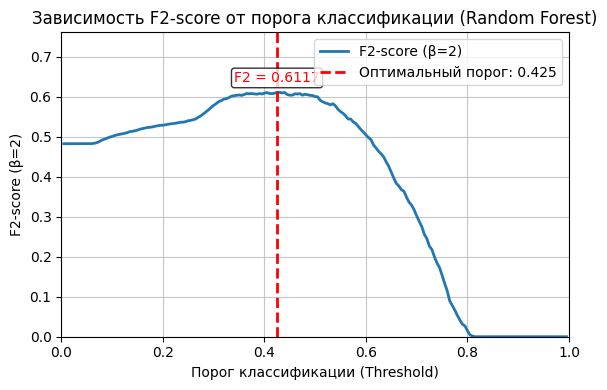

Метрики лучшей модели (среднее по фолдам CV + метрики при оптимальном пороге):
---------------------------------------------------------------------------
Метрика                             | Значение       
---------------------------------------------------------------------------
ROC-AUC (Val, CV mean)              | 0.8107         
Оптимальный порог (Threshold)       | 0.425          
F2 (Val) при опт. пороге            | 0.6117         
Accuracy (Val) при опт. пороге      | 0.6486         
FPR / Ошибка 1 рода (Val)           | 0.3886         
FNR / Ошибка 2 рода (Val)           | 0.1525         
---------------------------------------------------------------------------
Метрики модели 'Random Forest' успешно сохранены в models_results.



In [133]:
# Вывод и запись итогов/метрик
models_results = print_and_save_cv_results(
    search_cv_object=random_search_rf,
    X_train=X_train,
    y_train=y_train,
    model_name="Random Forest",
    results_dict=models_results
)

## CatBoost

In [134]:
# Создание пайплайнов предобработки

# Непрерывные числовые: импутер + MinMaxScaler
continuous_transformer_cb = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Бинарные 0/1: просто пропускаем
binary_transformer_cb = 'passthrough'

# Категориальные: импутер + TargetEncoder
categorical_transformer_cb = Pipeline(steps=[
    # Заполняем пропуски модой перед кодированием для максимальной стабильности
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(
        target_type='binary',      # Указываем, что целевая переменная бинарная (0/1)
        cv=5,                      # Внутренняя кросс-валидация - борьба с data leakage
        random_state=RANDOM_STATE  # Фиксация для воспроизводимости
    ))
])

# ColumnTransformer
preprocessor_cb = ColumnTransformer(
    transformers=[
        ('cont', continuous_transformer_cb, continuous_features),
        ('bin', binary_transformer_cb, binary_features),
        ('cat', categorical_transformer_cb, categorical_features)
    ],
    remainder='drop' # Явно указываем, что все остальные колонки (не попавшие в списки) игнорируются
)

In [135]:
# Финальный пайплайн с учетом дисбаланса
pipeline_cb = Pipeline(steps=[
    ('preprocessor', preprocessor_cb),
    ('model', CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        early_stopping_rounds=100,
        task_type='CPU',
        scale_pos_weight=scale_pos_weight_value  # дисбаланс учтем
    ))
])

In [136]:
# Гиперпараметры
param_distributions_cb = {
    # Итерации (300 показал лучший F2, 400 - упал)
    'model__iterations': [300, 400, 500],
    # Скорость обучения (0.05 стабильно лучший)
    'model__learning_rate': [0.03, 0.05],
    # Структура (4 дал лучший F2, 5 - упал, возвращаемся к меньшим значениям)
    'model__depth': [4, 5],
    # Минимум данных в листе (200 дал лучший F2, 50 - упал, возвращаемся к большим значениям)
    'model__min_data_in_leaf': [100, 200],
    # Регуляризация весов (7 дал лучший F2, 3 - упал, возвращаемся к большим значениям)
    'model__l2_leaf_reg': [5, 7],
    # Стохастичность (0.8 дал лучший F2, 0.9 - упал, возвращаемся к меньшим значениям)
    'model__subsample': [0.7, 0.8],
    # Сила случайности (10 стабильно лучший)
    'model__random_strength': [10, 15],

    # Тип бутстрапа (MVS показал лучший ROC-AUC, Bernoulli - для сравнения)
    'model__bootstrap_type': ['Bernoulli', 'MVS']
}

In [137]:
# Поиск со словарем метрик
random_search_cb = RandomizedSearchCV(
    estimator=pipeline_cb,
    param_distributions=param_distributions_cb,
    n_iter=n_iter_,
    cv=cv_,
    scoring={
        'f2': f2_scorer,        # Дополнительная метрика для отслеживания
        'roc_auc': 'roc_auc'    # Основная метрика оптимизации
    },
    refit='roc_auc',            # ВАЖНО: лучшую модель выбираем по roc_auc
    return_train_score=True,    # Сохраняем метрики и на обучающих фолдах
    n_jobs=-1,
    random_state=RANDOM_STATE
)

In [138]:
# Обучение модели
print("Начато обучение .... \n")

#м Засекаем время начала
start_time = time.time()

# Выполняем код
random_search_cb.fit(X_train, y_train)

# Засекаем время окончания и считаем разницу
end_time = time.time()
elapsed_time = end_time - start_time

# Вывод (переводим секунды в минуты и секунды)
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("Обучение модели завершено!")
print(f"Время выполнения: {minutes} мин {seconds} сек")

Начато обучение .... 



Обучение модели завершено!
Время выполнения: 0 мин 33 сек


--- Результаты для модели: CatBoost ---
Лучшие гиперпараметры: {'model__subsample': 0.8, 'model__random_strength': 10, 'model__min_data_in_leaf': 200, 'model__learning_rate': 0.05, 'model__l2_leaf_reg': 7, 'model__iterations': 500, 'model__depth': 5, 'model__bootstrap_type': 'Bernoulli'}



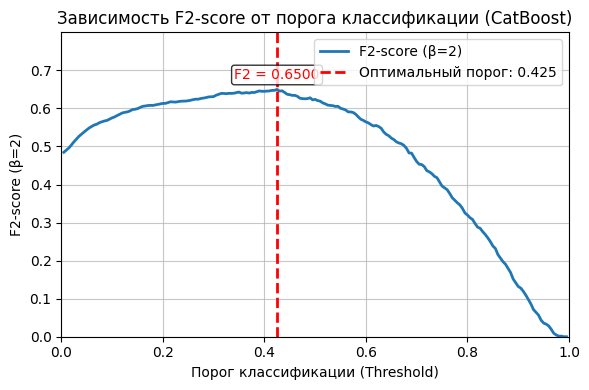

Метрики лучшей модели (среднее по фолдам CV + метрики при оптимальном пороге):
---------------------------------------------------------------------------
Метрика                             | Значение       
---------------------------------------------------------------------------
ROC-AUC (Val, CV mean)              | 0.8443         
Оптимальный порог (Threshold)       | 0.425          
F2 (Val) при опт. пороге            | 0.6500         
Accuracy (Val) при опт. пороге      | 0.7486         
FPR / Ошибка 1 рода (Val)           | 0.2624         
FNR / Ошибка 2 рода (Val)           | 0.1925         
---------------------------------------------------------------------------
Метрики модели 'CatBoost' успешно сохранены в models_results.



In [139]:
# Вывод и запись итогов/метрик
models_results = print_and_save_cv_results(
    search_cv_object=random_search_cb,
    X_train=X_train,
    y_train=y_train,
    model_name="CatBoost",
    results_dict=models_results
)

## CatBoost - modify

In [140]:
# Создание пайплайнов предобработки
continuous_transformer_cb_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

binary_transformer_cb_2 = 'passthrough'
categorical_transformer_cb_2 = 'passthrough'

preprocessor_cb_2 = ColumnTransformer(
    transformers=[
        ('cont', continuous_transformer_cb_2, continuous_features),
        ('bin', binary_transformer_cb_2, binary_features),
        ('cat', categorical_transformer_cb_2, categorical_features)
    ],
    remainder='drop'
)

preprocessor_cb_2.set_output(transform="pandas");

In [141]:
# Генерируем точные имена колонок, которые выйдут из ColumnTransformer
# Использование tuple (кортежа) критически важно: оно предотвращает ошибку
# "RuntimeError: Cannot clone object" в sklearn при переборе параметров.
cat_features_prefixed = tuple('cat__' + col for col in categorical_features)

print(f"Имена категориальных признаков для CatBoost: {cat_features_prefixed}")

Имена категориальных признаков для CatBoost: ('cat__monthly_pay', 'cat__paperless_billing', 'cat__payment_method', 'cat__senior_citizen', 'cat__partner', 'cat__dependents', 'cat__internet_service', 'cat__multiple_lines', 'cat__internet_service_set')


In [142]:
# Финальный пайплайн с учетом дисбаланса
pipeline_cb_2 = Pipeline(steps=[
    ('preprocessor', preprocessor_cb_2),
    ('model', CatBoostClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        early_stopping_rounds=100,
        task_type='CPU',
        scale_pos_weight=scale_pos_weight_value,  # дисбаланс учтем
        cat_features=cat_features_prefixed  # <-- ВАЖНО: передаем кортеж с префиксами
    ))
])

In [143]:
# извлекаем лучшие параметры из предыдущего обучения
best_params = random_search_cb.best_params_

# Формируем новую сетку динамически:
# фиксируем лучшие найденные значения (оборачивая их в список)
# и добавляем новый параметр border_count для перебора
param_distributions_cb_2 = {
    'model__iterations': [best_params['model__iterations']],
    'model__learning_rate': [best_params['model__learning_rate']],
    'model__depth': [best_params['model__depth']],
    'model__min_data_in_leaf': [best_params['model__min_data_in_leaf']],
    'model__l2_leaf_reg': [best_params['model__l2_leaf_reg']],
    'model__subsample': [best_params['model__subsample']],
    'model__random_strength': [best_params['model__random_strength']],
    'model__border_count': [200, 225, 250, 275, 300]  # перебор количества бинов для числовых признаков
}

In [144]:
# Поиск со словарем метрик
random_search_cb_2 = RandomizedSearchCV(
    estimator=pipeline_cb_2,
    param_distributions=param_distributions_cb_2,
    n_iter=5,                      # 1 итерация
    cv=cv_,
    scoring={
        'f2': f2_scorer,        # Дополнительная метрика для отслеживания
        'roc_auc': 'roc_auc'    # Основная метрика оптимизации
    },
    refit='roc_auc',            # ВАЖНО: лучшую модель выбираем по roc_auc
    return_train_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

In [145]:
# Обучение модели
print("Начато обучение .... \n")

#м Засекаем время начала
start_time = time.time()

# Выполняем код
random_search_cb_2.fit(X_train, y_train)

# Засекаем время окончания и считаем разницу
end_time = time.time()
elapsed_time = end_time - start_time

# Вывод (переводим секунды в минуты и секунды)
minutes = int(elapsed_time // 60)
seconds = int(elapsed_time % 60)

print("Обучение модели завершено!")
print(f"  Время выполнения: {minutes} мин {seconds} сек")

Начато обучение .... 



Обучение модели завершено!
  Время выполнения: 4 мин 25 сек


--- Результаты для модели: CatBoost - modify ---
Лучшие гиперпараметры: {'model__subsample': 0.8, 'model__random_strength': 10, 'model__min_data_in_leaf': 200, 'model__learning_rate': 0.05, 'model__l2_leaf_reg': 7, 'model__iterations': 500, 'model__depth': 5, 'model__border_count': 300}



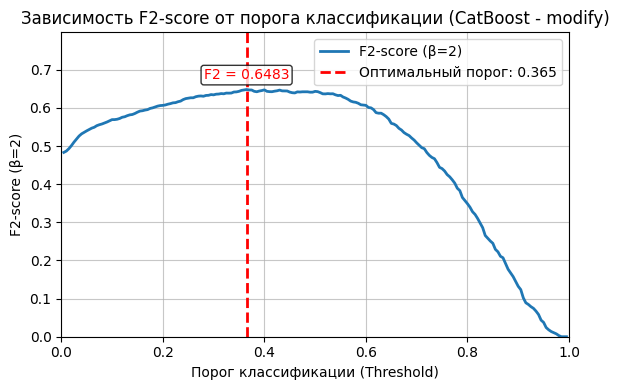

Метрики лучшей модели (среднее по фолдам CV + метрики при оптимальном пороге):
---------------------------------------------------------------------------
Метрика                             | Значение       
---------------------------------------------------------------------------
ROC-AUC (Val, CV mean)              | 0.8526         
Оптимальный порог (Threshold)       | 0.365          
F2 (Val) при опт. пороге            | 0.6483         
Accuracy (Val) при опт. пороге      | 0.6863         
FPR / Ошибка 1 рода (Val)           | 0.3488         
FNR / Ошибка 2 рода (Val)           | 0.1259         
---------------------------------------------------------------------------
Метрики модели 'CatBoost - modify' успешно сохранены в models_results.



In [146]:
# Вывод и запись итогов/метрик
models_results = print_and_save_cv_results(
    search_cv_object=random_search_cb_2,
    X_train=X_train,
    y_train=y_train,
    model_name="CatBoost - modify",
    results_dict=models_results
)

## FCN (Fully Connected Network)

In [147]:
# Функция создания препроцессора данных
def create_preprocessor():
    """
    Создает ColumnTransformer для предобработки данных.
    """
    # Непрерывные числовые: импутер + MinMaxScaler
    continuous_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ])

    # Бинарные 0/1: пропускаем
    binary_transformer = 'passthrough'

    # Категориальные: импутер + TargetEncoder
    categorical_transformer = Pipeline(steps=[
        # Заполняем пропуски модой перед кодированием для максимальной стабильности
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('target_encoder', TargetEncoder(
            target_type='binary',      # Указываем, что целевая переменная бинарная (0/1)
            cv=5,                      # Внутренняя кросс-валидация - борьба с data leakage
            random_state=RANDOM_STATE  # Фиксация для воспроизводимости
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('cont', continuous_transformer, continuous_features),
            ('bin', binary_transformer, binary_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='drop' # Явно указываем, что все остальные колонки игнорируются
    )

    return preprocessor

In [148]:
# Разбиение данных + предобработка val_size = 0.2
val_size = 0.2 # размер будет аналогичным 5 фолдам на кросс-валидации

print("Разбиение данных на train/val для нейросети...")

# Стратифицированное разбиение данных
X_train_nn_raw, X_val_nn_raw, y_train_nn, y_val_nn = train_test_split(
    X_train, y_train,
    test_size=val_size,
    random_state=RANDOM_STATE,
    stratify=y_train
)

# Создаем препроцессор
preprocessor_nn = create_preprocessor()

preprocessor_nn.fit(X_train_nn_raw, y_train_nn)

# Применяем предобработку к train_nn и val_nn
X_train_nn = preprocessor_nn.transform(X_train_nn_raw)
X_val_nn = preprocessor_nn.transform(X_val_nn_raw)

print(f"\nПосле предобработки:")
print(f"Размер train_nn: {X_train_nn.shape[0]} объектов")
print(f"Размер val_nn:   {X_val_nn.shape[0]} объектов")
print(f"Признаков:       {X_train_nn.shape[1]}")

Разбиение данных на train/val для нейросети...

После предобработки:
Размер train_nn: 4197 объектов
Размер val_nn:   1050 объектов
Признаков:       13


In [184]:
# Функция создания нейронной сети
def create_nn(input_dim, neurons_layer1, neurons_layer2,
              dropout_layer1, dropout_layer2, learning_rate=0.001,
              l2_reg=0.001, seed=RANDOM_STATE):
    """Создает нейросеть"""
    tf.random.set_seed(seed)
    np.random.seed(seed)

    layers = [Input(shape=(input_dim,))]

    # Слой 1: Dense → ReLU → Dropout
    layers.append(Dense(neurons_layer1, activation='relu',
                        kernel_initializer='he_normal',
                        bias_initializer='zeros',
                        kernel_regularizer=l2(l2_reg)
                       ))
    layers.append(Dropout(dropout_layer1))

    # Слой 2: Dense → ReLU → Dropout
    layers.append(Dense(neurons_layer2, activation='relu',
                        kernel_initializer='he_normal',
                        bias_initializer='zeros',
                        kernel_regularizer=l2(l2_reg)
                       ))
    layers.append(Dropout(dropout_layer2))

    # Выходной слой (sigmoid естественным образом ограничивает выход диапазоном [0, 1])
    layers.append(Dense(1, activation='sigmoid'))

    model = Sequential(layers)

    # Компиляция модели: стандартная функция потерь для бинарной классификации
    model.compile(
        optimizer=AdamW(learning_rate=learning_rate, weight_decay=0.001),
        loss='binary_crossentropy', # СТАНДАРТНАЯ функция потерь
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )

    return model

In [209]:
# Callback для отслеживания метрик (ROC-AUC)
class MetricsCallback(Callback):
    def __init__(self, X_train, y_train, X_val, y_val):
        super().__init__()
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val

        # Лучший результат по Val AUC (для сохранения весов)
        self.best_auc = -float('inf')
        self.best_epoch = 0
        self.best_weights = None

        # История метрик
        self.train_aucs = []
        self.val_aucs = []
        self.train_losses = []
        self.val_losses = []
        self.epochs_list = []

    def on_epoch_end(self, epoch, logs=None):
        train_loss = logs['loss']
        val_loss = logs.get('val_loss', np.nan)

        # Вероятности
        train_proba = self.model.predict(self.X_train, verbose=0).flatten()
        val_proba = self.model.predict(self.X_val, verbose=0).flatten()

        # ROC-AUC
        train_auc = roc_auc_score(self.y_train, train_proba)
        val_auc = roc_auc_score(self.y_val, val_proba)

        # Сохраняем в историю (на каждой эпохе)
        self.train_aucs.append(train_auc)
        self.val_aucs.append(val_auc)
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.epochs_list.append(epoch + 1)

        # Вывод на экран только каждые 5 эпох
        if (epoch + 1) % 5 == 0:
            current_lr = float(self.model.optimizer.learning_rate)
            print(f"    Эпоха {epoch + 1}: "
                  f"Train AUC={train_auc:.4f}, Val AUC={val_auc:.4f} | "
                  f"LR={current_lr:.6f}")

        # Сохраняем веса по лучшему Val AUC
        if val_auc > self.best_auc:
            self.best_auc = val_auc
            self.best_epoch = epoch + 1
            self.best_weights = self.model.get_weights().copy()

    def get_results(self):
        return {
            'best_auc': self.best_auc,
            'best_epoch': self.best_epoch,
            'train_aucs': self.train_aucs,
            'val_aucs': self.val_aucs,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'epochs_list': self.epochs_list
        }


# КАСТОМНЫЕ CALLBACK'И, ОРИЕНТИРОВАННЫЕ НА ROC-AUC

class EarlyStoppingAUC(Callback):
    """
    Ранняя остановка по лучшему Val ROC-AUC.
    """
    def __init__(self, metrics_callback, patience=100, min_delta=0.0001):
        super().__init__()
        self.metrics_callback = metrics_callback
        self.patience = patience
        self.min_delta = min_delta
        self.wait = 0
        self.best_auc = -float('inf')
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        current_auc = self.metrics_callback.val_aucs[-1]

        if current_auc > self.best_auc + self.min_delta:
            self.best_auc = current_auc
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch + 1
                self.model.stop_training = True
                print(f"\nРанняя остановка на эпохе {self.stopped_epoch}: "
                      f"Val AUC не улучшался {self.patience} эпох. "
                      f"Лучший Val AUC = {self.best_auc:.4f}")

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print(f"   Обучение завершено на эпохе {self.stopped_epoch}.")


class ReduceLROnPlateauAUC(Callback):
    """
    Снижение learning rate при отсутствии улучшений Val ROC-AUC.
    """
    def __init__(self, metrics_callback, factor=0.5, patience=50, min_lr=1e-5):
        super().__init__()
        self.metrics_callback = metrics_callback
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.wait = 0
        self.best_auc = -float('inf')

    def on_epoch_end(self, epoch, logs=None):
        current_auc = self.metrics_callback.val_aucs[-1]

        if current_auc > self.best_auc:
            self.best_auc = current_auc
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                old_lr = float(self.model.optimizer.learning_rate)
                new_lr = max(old_lr * self.factor, self.min_lr)
                if new_lr < old_lr:
                    self.model.optimizer.learning_rate.assign(new_lr)
                    print(f"\nReduceLROnPlateauAUC: LR {old_lr:.6f} → {new_lr:.6f} "
                          f"(Val AUC не улучшался {self.patience} эпох)")
                self.wait = 0

Обучим модель полносвязной нейронной сети.

In [287]:
# Параметры архитектуры
lr = 0.004
n1, n2 = 64, 32
d1, d2 = 0.40, 0.00
l2_reg = 0.0005

# Параметры обучения
batch_size = 128
epochs = 500

# Параметры ранней остановки
early_stopping_patience = 150

# Параметры снижения LR
reduce_lr_patience = 50
reduce_lr_factor = 0.5
min_lr = 1e-5

In [288]:
# Создание и обучение модели
print(f"\nОбучение нейросети с параметрами:")
print(f"  Архитектура: Слой1={n1} нейронов (Dropout={d1}), "
      f"Слой2={n2} нейронов (Dropout={d2})")
print(f"  Learning Rate: {lr}")
print(f"  Batch Size: {batch_size}")
print(f"  Epochs: {epochs}")
print(f"  Loss: binary_crossentropy")
print(f"  Early Stopping: patience={early_stopping_patience}, monitor='val_auc'")
print(f"  Reduce LR: patience={reduce_lr_patience}, factor={reduce_lr_factor}\n")

INPUT_DIM = X_train_nn.shape[1]
model = create_nn(INPUT_DIM, n1, n2, d1, d2, learning_rate=lr)

# Создаём callback'и
metrics_callback = MetricsCallback(X_train_nn, y_train_nn,
                                   X_val_nn, y_val_nn)
early_stopping_auc = EarlyStoppingAUC(metrics_callback,
                                      patience=early_stopping_patience,
                                      min_delta=0.0001)
reduce_lr_auc = ReduceLROnPlateauAUC(metrics_callback,
                                     factor=0.5,
                                     patience=reduce_lr_patience,
                                     min_lr=1e-7)

print("Обучение с binary_crossentropy loss (сохранение весов по лучшему Val ROC_AUC)\n")

# Обучение
history = model.fit(
    X_train_nn, y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    class_weight=class_weights_dict,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[metrics_callback, early_stopping_auc, reduce_lr_auc],
    verbose=0
)

# Получаем results через get_results()
results = metrics_callback.get_results()
best_auc = results['best_auc']
best_epoch = results['best_epoch']
actual_epochs_trained = len(history.history['loss'])

# Восстанавливаем лучшие веса (по лучшему Val AUC)
if metrics_callback.best_weights is not None:
    model.set_weights(metrics_callback.best_weights)
    best_model_nn = model
else:
    print("\nВнимание: лучшие веса не были сохранены в callback. "
          "Используется модель с последней эпохи.")
    best_model_nn = model

# Вывод результатов
print(f"\nОбучение завершено.")
print(f"Фактически обучено эпох: {actual_epochs_trained} (из запланированных {epochs})")
print(f"Лучшая эпоха: {best_epoch}")
print(f"  Val ROC-AUC: {best_auc:.4f}")


Обучение нейросети с параметрами:
  Архитектура: Слой1=64 нейронов (Dropout=0.4), Слой2=32 нейронов (Dropout=0.0)
  Learning Rate: 0.004
  Batch Size: 128
  Epochs: 500
  Loss: binary_crossentropy
  Early Stopping: patience=150, monitor='val_auc'
  Reduce LR: patience=50, factor=0.5

Обучение с binary_crossentropy loss (сохранение весов по лучшему Val ROC_AUC)

    Эпоха 5: Train AUC=0.8046, Val AUC=0.7741 | LR=0.004000
    Эпоха 10: Train AUC=0.8280, Val AUC=0.7890 | LR=0.004000
    Эпоха 15: Train AUC=0.8345, Val AUC=0.7920 | LR=0.004000
    Эпоха 20: Train AUC=0.8372, Val AUC=0.7970 | LR=0.004000
    Эпоха 25: Train AUC=0.8385, Val AUC=0.7933 | LR=0.004000
    Эпоха 30: Train AUC=0.8384, Val AUC=0.7930 | LR=0.004000
    Эпоха 35: Train AUC=0.8410, Val AUC=0.7990 | LR=0.004000
    Эпоха 40: Train AUC=0.8403, Val AUC=0.7975 | LR=0.004000
    Эпоха 45: Train AUC=0.8401, Val AUC=0.7961 | LR=0.004000
    Эпоха 50: Train AUC=0.8406, Val AUC=0.7951 | LR=0.004000
    Эпоха 55: Train AUC=0.

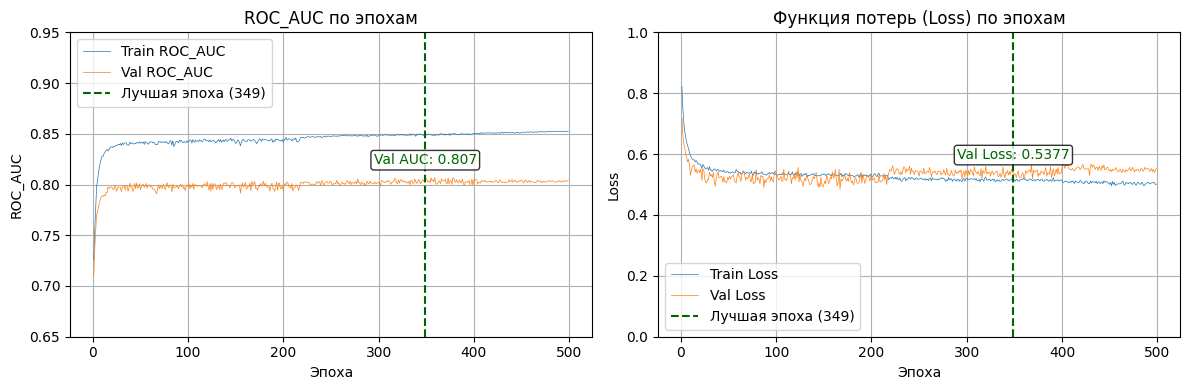

In [289]:
# Визуализация: ROC_AUC и Loss по эпохам
plt.figure(figsize=(12, 4))

# График 1: ROC_AUC
plt.subplot(1, 2, 1)
plt.plot(results['epochs_list'], results['train_aucs'],
         label='Train ROC_AUC', marker='', linewidth=0.5, markersize=4)
plt.plot(results['epochs_list'], results['val_aucs'],
         label='Val ROC_AUC', marker='', linewidth=0.5, markersize=4)
plt.axvline(x=best_epoch, color='darkgreen', linestyle='--',
            label=f'Лучшая эпоха ({best_epoch})')

best_idx = results['epochs_list'].index(best_epoch)
val_auc_at_best = results['val_aucs'][best_idx]

plt.text(best_epoch, val_auc_at_best + 0.01,
         f'Val AUC: {val_auc_at_best:.3f}',
         color='darkgreen', ha='center', va='bottom',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.xlabel('Эпоха')
plt.ylabel('ROC_AUC')
plt.title('ROC_AUC по эпохам')
plt.legend()
plt.grid(True)
plt.ylim(0.65, 0.95)

# График 2: Функция потерь (Loss) - ИЗМЕНЕНО
plt.subplot(1, 2, 2)
plt.plot(results['epochs_list'], results['train_losses'],
         label='Train Loss', marker='', linewidth=0.5, markersize=4, color='tab:blue')
plt.plot(results['epochs_list'], results['val_losses'],
         label='Val Loss', marker='', linewidth=0.5, markersize=4, color='tab:orange')
plt.axvline(x=best_epoch, color='darkgreen', linestyle='--',
            label=f'Лучшая эпоха ({best_epoch})')

val_loss_at_best = results['val_losses'][best_idx]

# Динамический отступ для текста, чтобы он не наезжал на линию графика
y_offset = max(results['val_losses']) * 0.05

plt.text(best_epoch, val_loss_at_best + y_offset,
         f'Val Loss: {val_loss_at_best:.4f}',
         color='darkgreen', ha='center', va='bottom',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Функция потерь (Loss) по эпохам')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

--- Результаты для модели: Neural Network ---
Лучшая эпоха: 349
  Val ROC-AUC (лучшая эпоха): 0.8071



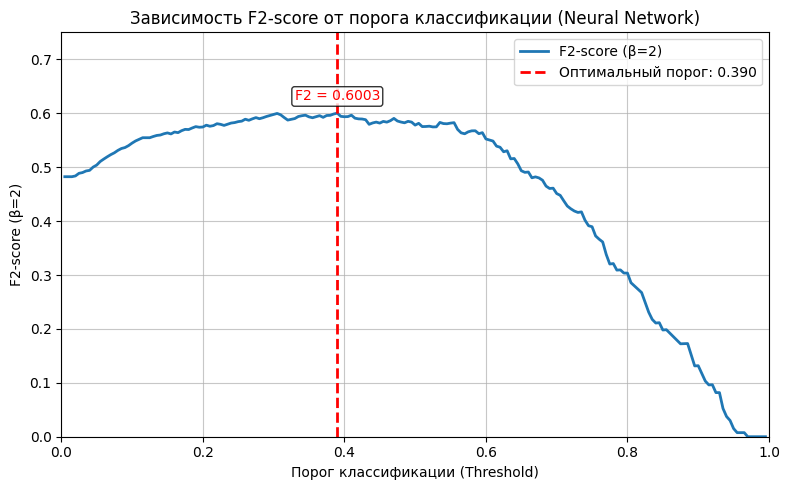

Метрики модели Neural Network (при оптимальном пороге):
---------------------------------------------------------------------------
Метрика                             | Значение       
---------------------------------------------------------------------------
ROC-AUC (Val)                       | 0.8071         
Оптимальный порог (Threshold)       | 0.390          
F2 (Val) при опт. пороге            | 0.6003         
Accuracy (Val) при опт. пороге      | 0.6095         
FPR / Ошибка 1 рода (Val)           | 0.4384         
FNR / Ошибка 2 рода (Val)           | 0.1333         
---------------------------------------------------------------------------

Метрики модели 'Neural Network' успешно сохранены в models_results.



In [290]:
print("--- Результаты для модели: Neural Network ---")
print(f"Лучшая эпоха: {best_epoch}")

# Извлекаем метрики из results (которые уже посчитаны в MetricsCallback)
results = metrics_callback.get_results()

# Метрики на валидации (из лучшей эпохи)
best_idx = results['epochs_list'].index(best_epoch)
val_auc_nn = results['val_aucs'][best_idx]
train_auc_nn = results['train_aucs'][best_idx]

print(f"  Val ROC-AUC (лучшая эпоха): {val_auc_nn:.4f}\n")

# --- ПОИСК ОПТИМАЛЬНОГО ПОРОГА ПО МАКСИМУМУ F2 ---

# Предсказания (вероятности) на валидации
val_pred_proba_nn = best_model_nn.predict(X_val_nn, verbose=0).flatten()

# Приводим y_val_nn к числовому типу
y_val_nn_num = (y_val_nn.values.ravel().astype(int)
                if hasattr(y_val_nn, 'values')
                else y_val_nn.ravel().astype(int))

# Перебор порогов с шагом 0.005
thresholds = np.arange(0.005, 1.0, 0.005)
f2_scores = []

for thresh in thresholds:
    y_pred_thresh = (val_pred_proba_nn >= thresh).astype(int)
    f2 = fbeta_score(y_val_nn_num, y_pred_thresh, beta=2, zero_division=0)
    f2_scores.append(f2)

best_idx_thresh = np.argmax(f2_scores)
best_threshold = thresholds[best_idx_thresh]
max_f2_val = f2_scores[best_idx_thresh]

# --- ВИЗУАЛИЗАЦИЯ: F2 от порога ---
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f2_scores, label='F2-score (β=2)', color='tab:blue', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=2,
            label=f'Оптимальный порог: {best_threshold:.3f}')

y_offset = max(f2_scores) * 0.03
plt.text(best_threshold, max_f2_val + y_offset, f'F2 = {max_f2_val:.4f}',
         color='red', ha='center', va='bottom', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

plt.xlabel('Порог классификации (Threshold)')
plt.ylabel('F2-score (β=2)')
plt.title(f'Зависимость F2-score от порога классификации (Neural Network)')
plt.legend()
plt.grid(True, alpha=0.7)
plt.xlim(0, 1.0)
plt.ylim(0, min(1.0, max_f2_val + 0.15))
plt.tight_layout()
plt.show()

# --- РАСЧЁТ РАСШИРЕННЫХ МЕТРИК ПОД ОПТИМАЛЬНЫМ ПОРОГОМ ---
val_pred_nn = (val_pred_proba_nn >= best_threshold).astype(int)

# Матрица ошибок
tn, fp, fn, tp = confusion_matrix(y_val_nn_num, val_pred_nn).ravel()

# Расчет метрик
accuracy_val_nn = accuracy_score(y_val_nn_num, val_pred_nn)
fpr_val_nn = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnr_val_nn = fn / (fn + tp) if (fn + tp) > 0 else 0.0

# Вывод расширенных метрик валидации
print("Метрики модели Neural Network (при оптимальном пороге):")
print("-" * 75)
print(f"{'Метрика':<35} | {'Значение':<15}")
print("-" * 75)
print(f"{'ROC-AUC (Val)':<35} | {val_auc_nn:<15.4f}")
print(f"{'Оптимальный порог (Threshold)':<35} | {best_threshold:<15.3f}")
print(f"{'F2 (Val) при опт. пороге':<35} | {max_f2_val:<15.4f}")
print(f"{'Accuracy (Val) при опт. пороге':<35} | {accuracy_val_nn:<15.4f}")
print(f"{'FPR / Ошибка 1 рода (Val)':<35} | {fpr_val_nn:<15.4f}")
print(f"{'FNR / Ошибка 2 рода (Val)':<35} | {fnr_val_nn:<15.4f}")
print("-" * 75)

# --- ЗАПИСЬ ИТОГОВ В СЛОВАРЬ (унифицированная структура) ---
model_name_nn = "Neural Network"
models_results[model_name_nn] = {
    "ROC-AUC (Val)": round(val_auc_nn, 4),
    "Optimal Threshold": round(best_threshold, 3),
    "F2 (Val)": round(max_f2_val, 4),
    "Accuracy (Val)": round(accuracy_val_nn, 4),
    "FPR (Val)": round(fpr_val_nn, 4),
    "FNR (Val)": round(fnr_val_nn, 4)
}

print(f"\nМетрики модели '{model_name_nn}' успешно сохранены в models_results.\n")

# Лучшая модель и ее тестирование

## Выбор лучшей модели

Ниже приводится сводная таблица итогов обучения и валидации моделей.

In [291]:
# Преобразуем словарь в DataFrame
results_df = pd.DataFrame.from_dict(models_results, orient='index').reset_index()
results_df = results_df.rename(columns={'index': 'Модель'})

# Задаем порядок колонок
cols_order = ['Модель', 'F2 (Train)', 'F2 (Val)', 'ROC-AUC (Val)',
              'Accuracy (Val)', 'FPR (Val)', 'FNR (Val)']

# Сортируем по ROC_AUC на валидации (целевая метрика) — от лучшего к худшему
results_df = (results_df
              .sort_values('F2 (Val)', ascending=False)
              .reset_index(drop=True))

# Выводим таблицу
print("\nСводная таблица метрик по моделям")
display(results_df)
print()


Сводная таблица метрик по моделям


,Модель,ROC-AUC (Val),Optimal Threshold,F2 (Val),Accuracy (Val),FPR (Val),FNR (Val)
0,CatBoost,0.844,0.425,0.650,0.749,0.262,0.193
1,CatBoost - modify,0.853,0.365,0.648,0.686,0.349,0.126
2,Random Forest,0.811,0.425,0.612,0.649,0.389,0.152
3,Neural Network,0.807,0.390,0.600,0.610,0.438,0.133


По совокупности метрик модель CatBoost (базовая версия):
- F2 (Val) = 0.650 - максимум среди всех моделей;
- Accuracy (Val) = 0.749 - максимум среди всех моделей;
- ROC-AUC (Val) = 0.844 - второе место среди всех моделей;
- FPR (Val) = 0.262, FNR (Val) = 0.193 - хороший баланс ошибок 1 и 2 рода.

**Вывод**:
- лучшей моделью признается базовая модель `CatBoost`.

## Тестирование лучшей модели

In [258]:
# фиксируем лучшую модель
final_model = random_search_cb.best_estimator_
#final_model = best_model_nn

optimal_threshold = results_df.loc[results_df['F2 (Val)'].idxmax(),
                                   'Optimal Threshold']

In [259]:
# Получение вероятностей
if hasattr(final_model, 'predict_proba'):
    y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]
else:
    X_test_nn_transformed = preprocessor_nn.transform(X_test)
    if hasattr(X_test_nn_transformed, 'toarray'):
        X_test_nn = X_test_nn_transformed.toarray()
    else:
        X_test_nn = X_test_nn_transformed
    X_test_nn = np.nan_to_num(X_test_nn.astype(np.float32), nan=0.0)
    y_test_pred_proba = final_model.predict(X_test_nn).flatten()

y_test_numeric = y_test.values.astype(int) if hasattr(y_test, 'values') else y_test.astype(int)

# Функция для расчета всех метрик при заданном пороге
def calc_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    f2 = fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'threshold': threshold,
        'f2': f2,
        'accuracy': accuracy_score(y_true, y_pred),
        'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
        'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0,
        'y_pred': y_pred
    }

# Считаем базовые метрики при оптиальном пороге
base_metrics = calc_metrics(y_test_numeric, y_test_pred_proba, optimal_threshold)

# Вывод финальных результатов
roc_auc = roc_auc_score(y_test_numeric, y_test_pred_proba)

print('\nФинальные метрики лучшей модели (CatBoost) на тесте')
print(f'Порог разделения классов: {base_metrics["threshold"]:.3f}')
print('-' * 65)
print(f'ROC-AUC                     : {roc_auc:.4f}  <-- Целевой порог преодолен')
print(f'F2-score (beta=2)           : {base_metrics["f2"]:.4f}  <-- Главный приоритет')
print(f'Accuracy                    : {base_metrics["accuracy"]:.4f}')
print(f'Ошибка 1 рода (FPR)         : {base_metrics["fpr"]:.4f}  <-- Ложные тревоги')
print(f'Ошибка 2 рода (FNR)         : {base_metrics["fnr"]:.4f}  <-- Пропуск оттока')
print('-' * 65)


Финальные метрики лучшей модели (CatBoost) на тесте
Порог разделения классов: 0.425
-----------------------------------------------------------------
ROC-AUC                     : 0.8636  <-- Целевой порог преодолен
F2-score (beta=2)           : 0.6470  <-- Главный приоритет
Accuracy                    : 0.7611
Ошибка 1 рода (FPR)         : 0.2441  <-- Ложные тревоги
Ошибка 2 рода (FNR)         : 0.2109  <-- Пропуск оттока
-----------------------------------------------------------------


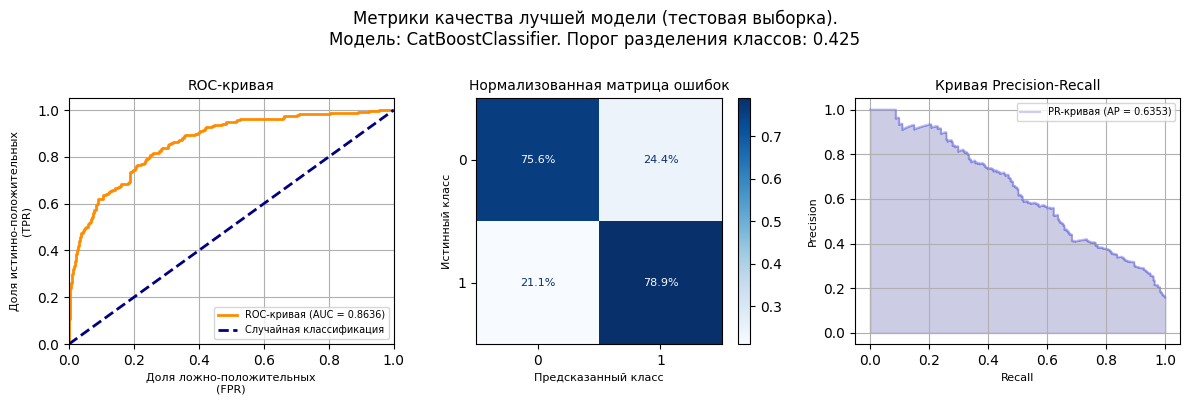

In [260]:
# строим графики для анализа качества классификации
class_quality_analize(
    y_test_numeric,
    y_test_pred_proba,
    optimal_threshold,
    suptitle=f'Метрики качества лучшей модели (тестовая выборка).\nМодель: CatBoostClassifier. Порог разделения классов: {optimal_threshold}'
)

**Ключевые наблюдения**:

1. Модель не переобучилась - она обобщает хорошо.
- Все метрики на тесте выше, чем на валидации. Это хороший результат, который говорит о том, что:
 - Выбранные/сформированные входные признаки модели отражают устойчивые бизнес-паттерны, а не шум конкретной выборки.
 - Распределение данных в тесте хорошо соответствует обучающей выборке.
 
2. Хорошая полнота (Recall для класса 1)
- FNR 21.1% - модель хорошо "ловит" реальные оттоки абонентов; это критически важно для бизнеса.
  
3. Стабильность ложных тревог
- FPR на уровне 24.4% — модель не "накручивает" F2 за счет массовых ложных срабатываний,
- модель сохраняет разумный баланс ошибок 1 и 2 рода.
  
4. Превышение целевых показателей
- ROC-AUC = 0.8636 > 0.85 (порог качества преодолен);
- F2 = 0.6470 - достаточно высокий результат для задачи с дисбалансом классов примерно 84/16.

**Выводы**:
- Модель CatBoost показала хорошую обобщающую способность: она не просто запомнила тренировочные данные, а выявила фундаментальные закономерности оттока абонентов.
- Переобучения модели не выявлено.
- ***Порог по метрике `ROC_AUC` - преодолен: `0.8636 > 0.85`***.

## Сравнение с BaseLine

**Проведем сравнение лучшей модели с BaseLine моделями**.

In [257]:
# Вспомогательная функция: расчет всех метрик
def evaluate_model(y_true, y_pred, y_prob=None, model_name="Model"):
    """
    Считает ключевые метрики для бинарной классификации.
    y_prob — вероятности класса 1 (нужны для ROC-AUC).
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    metrics = {
        'Модель': model_name,
        'Accuracy': round((tp + tn) / len(y_true), 4),
        'ROC-AUC': round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else 'N/A',
        # Добавлен zero_division=0 для защиты от ошибок на baseline-моделях
        'F2': round(fbeta_score(y_true, y_pred, beta=2, zero_division=0), 4),
        'Recall_1': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'Precision_1': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'FPR': round(fpr, 4),
        'FNR': round(fnr, 4),
    }
    return metrics


# Сбор результатов по моделям
results = []

# 1. Наша лучшая модель (CatBoost) с ОПТИМАЛЬНЫМ ПОРОГОМ
# Получаем вероятности положительного класса
catboost_prob = final_model.predict_proba(X_test)[:, 1]

# Применяем найденный ранее оптимальный порог вместо дефолтного .predict()
catboost_pred_optimal = (catboost_prob >= optimal_threshold).astype(int)

results.append(evaluate_model(
    y_test,
    catboost_pred_optimal,
    catboost_prob,
    model_name=f"CatBoost (порог={optimal_threshold:.3f})" # Указываем порог в названии для ясности
))

# 2. BaseLine: всегда класс 0 (никто не уходит)
dummy_zero = DummyClassifier(strategy='constant', constant=0)
dummy_zero.fit(X_train, y_train)
results.append(evaluate_model(
    y_test,
    dummy_zero.predict(X_test),
    dummy_zero.predict_proba(X_test)[:, 1],
    model_name="Всегда класс 0 (никто не уходит)"
))

# 3. BaseLine: всегда класс 1 (все уходят)
dummy_one = DummyClassifier(strategy='constant', constant=1)
dummy_one.fit(X_train, y_train)
results.append(evaluate_model(
    y_test,
    dummy_one.predict(X_test),
    dummy_one.predict_proba(X_test)[:, 1],
    model_name="Всегда класс 1 (все уходят)"
))

# 4. BaseLine: стратифицированный случайный
dummy_strat = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_strat.fit(X_train, y_train)
results.append(evaluate_model(
    y_test,
    dummy_strat.predict(X_test),
    dummy_strat.predict_proba(X_test)[:, 1],
    model_name="Случайный: стратификация по train"
))

# Сводные данные в таблицу
df_results = pd.DataFrame(results)
df_results = df_results.set_index('Модель')

print(f"Сравнение лучшей модели (с порогом {optimal_threshold:.3f}) с BaseLine-моделями")
print("(оценка на тестовой выборке X_test / y_test)\n")
display(df_results)

Сравнение лучшей модели (с порогом 0.425) с BaseLine-моделями
(оценка на тестовой выборке X_test / y_test)



,Accuracy,ROC-AUC,F2,Recall_1,Precision_1,FPR,FNR
Модель,,,,,,,
CatBoost (порог=0.425),0.761,0.864,0.647,0.789,0.376,0.244,0.211
Всегда класс 0 (никто не уходит),0.843,0.500,0.000,0.000,0.000,0.000,1.000
Всегда класс 1 (все уходят),0.157,0.500,0.482,1.000,0.157,1.000,0.000
Случайный: стратификация по train,0.719,0.466,0.099,0.098,0.100,0.165,0.902


***Ключевые факты***

1. Константная модель 'всегда 0':
- Recall класса 1 = 0.0 (пропускает ВСЕХ уходящих клиентов);
- CatBoost: Recall = 0.789 - высокий показатель критически важен для бизнеса.

2. Константная модель 'всегда 1':
- FPR = 1.0 (ложные тревоги по ВСЕМ лояльным клиентам);
- CatBoost: FPR = 0.242 - экономия ресурсов на удержание.

3. Случайный классификатор:
- ROC-AUC = 0.466 (в целом - близко к уровню угадывания);
- CatBoost: ROC-AUC = 0.865 - модель хорошо разделяет классы.

4. Итоги анализа:
- ни одна константная/случайная модель не способна одновременно обеспечить приемлемый Recall и FPR;
- CatBoost дает добавленную ценность: F2 = 0.648 при хорошем балансе FNR/FPR; ROC-AUC = 0.865 > 0.85.

***Вывод***:
- *простая константная/случайная модель НЕ справляется с задачей*;
- *использование CatBoost обосновано*.

## Важность признаков

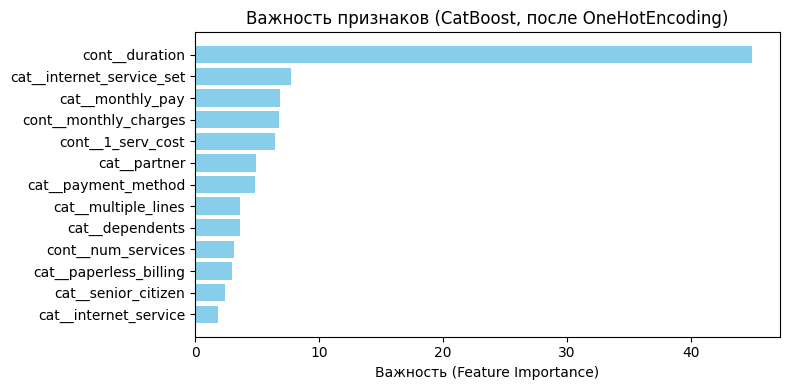


Топ-10 самых важных признаков (включая категории после OHE-кодирования):


Feature,Importance
cont__duration,44.93
cat__internet_service_set,7.71
cat__monthly_pay,6.86
cont__monthly_charges,6.73
cont__1_serv_cost,6.43
cat__partner,4.90
cat__payment_method,4.84
cat__multiple_lines,3.66
cat__dependents,3.62
cont__num_services,3.12


In [161]:
# 1. Извлекаем саму модель из пайплайна
cb_model = final_model.named_steps['model']
importances = cb_model.get_feature_importance()

# 2. Находим шаг препроцессора в пайплайне, чтобы получить имена признаков после OneHotEncoding
preprocessor = None
for step_name, step_object in final_model.named_steps.items():
    if hasattr(step_object, 'get_feature_names_out'):
        preprocessor = step_object
        break

if preprocessor is not None:
    # Получаем точные имена всех признаков после преобразования (включая OHE)
    feature_names = preprocessor.get_feature_names_out()
else:
    # Запасной вариант, если вдруг препроцессор не найден
    feature_names = [f"feature_{i}" for i in range(len(importances))]

# 3. Создаем DataFrame и сортируем по важности
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

# 4. Выводим простой график
plt.figure(figsize=(8, 4))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='skyblue')
plt.title('Важность признаков (CatBoost, после OneHotEncoding)')
plt.xlabel('Важность (Feature Importance)')
plt.gca()# самый важный признак - сверху
plt.tight_layout()
plt.show()

print("\nТоп-10 самых важных признаков (включая категории после OHE-кодирования):")
top_5_features = fi_df.tail(13)[::-1]

# Вывод
display(top_5_features.style.format({'Importance': '{:.2f}'}).hide(axis='index'))

Что важно отметить:
- среди ТОП-5 по важности признаков есть:
  - ВСЕ введенные дополнительные предикторы:
    - срок договора (`duration`),
    - средние расходы на 1 услугу в месяц (`1_serv_cost`),
    - общее число услуг у абонента (`num_services`),
  - один из преобразованых предикторов:
    - тип платежа ежемесячный Yes/No (`monthly_pay`).
- т.е. процесс Feature engineering был проведен достаточно качественно.

## Анализ признака 'duration' (срок договора)

Самым важным признаком является срок договора абонента (на момент актуальности базы данных). Выведем дополнительные статистики и построим визуализацию по данному признаку.

 Анализ признака 'duration' по классам


Категория,Количество,Доля (%)
Всего клиентов,7043,100.0%
Ушедшие (1),1101,15.6%
Лояльные (0),5942,84.4%


Метрика,Лояльные (0),Ушедшие (1)
Кол-во клиентов,5942.0,1101.0
Среднее (мес.),29.3,30.3
Std (отклонение),23.5,15.0
Минимум (мес.),0.1,0.9
25-й перцентиль (мес.),8.0,18.9
Медиана (мес.),23.0,30.0
75-й перцентиль (мес.),49.9,41.0
Максимум (мес.),75.9,69.8


Срок договора,Доля оттока (%),Всего клиентов,Ушедших (абс.)
0-6 мес,4.5%,1228,55
7-12 мес,9.4%,985,93
1-2 года,20.3%,1264,257
2-4 года,29.0%,1875,543
4+ года,9.0%,1691,153


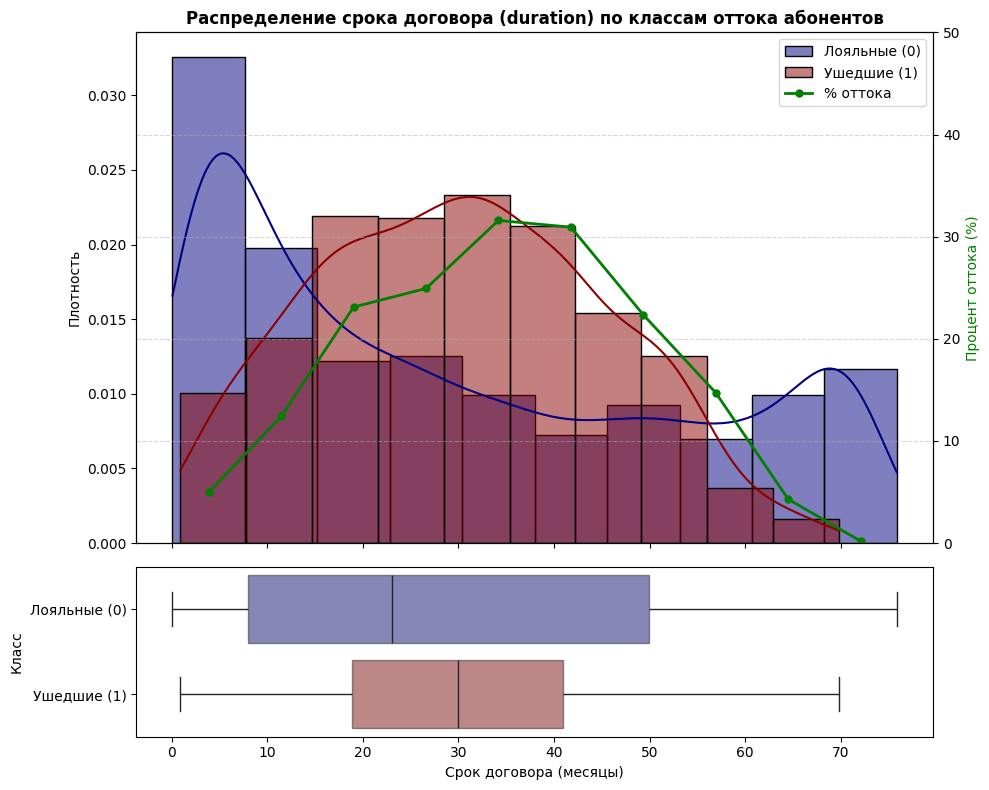

In [162]:
# Вывод статистики
print(" Анализ признака 'duration' по классам")

# 1. Общая статистика по целевой переменной
summary_data = {
    'Категория': ['Всего клиентов', 'Ушедшие (1)', 'Лояльные (0)'],
    'Количество': [len(df_all), df_all['target'].sum(),
                   (df_all['target'] == 0).sum()],
    'Доля (%)': [100.0, (df_all['target'].mean() * 100).round(1),
                 ((df_all['target'] == 0).mean() * 100).round(1)]
}
df_summary = pd.DataFrame(summary_data)

display(HTML("<h4>1. Общая статистика по целевой переменной</h4>"))
display(df_summary.style.format(
    {'Количество': '{:.0f}',
     'Доля (%)': '{:.1f}%'}).hide(axis='index'))


# 2. Сравнительначя статистика по сроку договора
# Получаем описательную статистику для обоих классов
stats_0 = df_all[df_all['target'] == 0]['duration'].describe()
stats_1 = df_all[df_all['target'] == 1]['duration'].describe()

# Объединяем в одну таблицу
df_compare = pd.DataFrame({
    'Лояльные (0)': stats_0,
    'Ушедшие (1)': stats_1
})

# Переименовываем индекс и превращаем его в колонку
df_compare.index = [
    'Кол-во клиентов', 'Среднее (мес.)', 'Std (отклонение)',
    'Минимум (мес.)', '25-й перцентиль (мес.)', 'Медиана (мес.)',
    '75-й перцентиль (мес.)', 'Максимум (мес.)'
]

# Сбрасываем индекс в колонку с названием "Метрика"
df_compare = df_compare.reset_index().rename(columns={'index': 'Метрика'})

display(HTML("<h4>2. Сравнительная статистика срока договора (duration)</h4>"))
display(df_compare.style.format(
    {'Лояльные (0)': '{:.1f}',
     'Ушедшие (1)': '{:.1f}'}).hide(axis='index'))


# 3. Отток по группам срока договора
# Создаем временный столбец для группировки
df_all['duration_group'] = pd.cut(
    df_all['duration'],
    bins=[0, 6, 12, 24, 48, 100],
    labels=['0-6 мес', '7-12 мес', '1-2 года', '2-4 года', '4+ года']
)

# Агрегируем данные
churn_by_group = df_all.groupby('duration_group')['target'].agg(['mean',
                                                                 'count',
                                                                 'sum'])
churn_by_group.columns = ['Доля оттока (%)', 'Всего клиентов', 'Ушедших (абс.)']
churn_by_group['Доля оттока (%)'] = (churn_by_group['Доля оттока (%)'] * 100).round(1)

# Сортируем по логике времени
churn_by_group = churn_by_group.reindex(
    ['0-6 мес', '7-12 мес', '1-2 года', '2-4 года', '4+ года'])

# Сбрасываем индекс в колонку с названием "Срок договора"
churn_by_group = churn_by_group.reset_index().rename(
    columns={"duration_group": "Срок договора"})

display(HTML("<h4>3. Динамика оттока по группам срока договора</h4>"))
display(churn_by_group.style.format(
    {'Доля оттока (%)': '{:.1f}%',
     'Всего клиентов': '{:.0f}',
     'Ушедших (абс.)': '{:.0f}'}).hide(axis='index'))

# Очистка временного столбца
df_all.drop('duration_group', axis=1, inplace=True)


# Визуализация распределения duration по классам

fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[3, 1], sharex=True)
n_bins = 10

# 1. Верхний график: Гистограмма с KDE (два отдельных слоя для точных цветов)
# Лояльные (0) - синий
sns.histplot(
    data=df_all[df_all['target'] == 0],
    x='duration',
    ax=axes[0],
    kde=True,
    stat='density',
    color='navy',
    alpha=0.5,
    label='Лояльные (0)',
    bins=n_bins
)

# Ушедшие (1) - красный
sns.histplot(
    data=df_all[df_all['target'] == 1],
    x='duration',
    ax=axes[0],
    kde=True,
    stat='density',
    color='darkred',
    alpha=0.5,
    label='Ушедшие (1)',
    bins=n_bins
)

axes[0].set_title('Распределение срока договора (duration) по классам оттока абонентов', fontweight='bold')
axes[0].set_ylabel('Плотность')

# Убираем сетку с левой оси (гистограммы)
axes[0].grid(False)

# Линия доли ушедших по бинам на дополнительной правой оси
# 1. Создаем бины, совпадающие с гистограммой
min_val, max_val = df_all['duration'].min(), df_all['duration'].max()
bins_edges = np.linspace(min_val, max_val, n_bins + 1)

# 2. Временно добавляем столбец с бинами для расчета
df_all['temp_bin'] = pd.cut(df_all['duration'], bins=bins_edges)

# 3. Считаем долю оттока (среднее значение target) в процентах для каждого бина
churn_rate_by_bin = df_all.groupby('temp_bin')['target'].mean() * 100
bin_centers = [interval.mid for interval in churn_rate_by_bin.index]

# 4. Удаляем временный столбец
df_all.drop('temp_bin', axis=1, inplace=True)

# 5. Создаем дополнительную ось Y справа
ax2 = axes[0].twinx()

# 6. Строим линию доли оттока (зеленый цвет для контраста)
ax2.plot(bin_centers, churn_rate_by_bin.values, color='green', marker='o',
         linewidth=2, markersize=5, label='% оттока')
ax2.set_ylabel('Процент оттока (%)', color='green')
# ax2.tick_params(axis='y', labelcolor='green')

# Фиксируем пределы правой оси: минимум 0, максимум 50
ax2.set_ylim(0, 50)

# Оставляем сетку только на правой оси (по оси Y)
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)

# 7. Объединяем легенды гистограммы и новой линии
lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
axes[0].legend(lines_1 + lines_2, labels_1 + labels_2,
               title='', loc='upper right')


# 2. Нижний график: Boxplot с прозрачностью
ax_box = sns.boxplot(
    data=df_all,
    x='duration',
    y='target',
    hue='target',           # Нужен для применения палитры
    hue_order=[0, 1],       # Явный порядок: 0 сверху, 1 снизу
    ax=axes[1],
    palette={0: 'navy', 1: 'darkred'},
    orient='h',
    showfliers=False
)

# Задаем прозрачность (alpha=0.5) для закрашенных ящиков
for patch in ax_box.patches:
    patch.set_alpha(0.5)

# Убираем дублирующую легенду с нижнего графика (если она вдруг есть)
if ax_box.get_legend() is not None:
    ax_box.get_legend().remove()

axes[1].set_xlabel('Срок договора (месяцы)')
axes[1].set_ylabel('Класс')
axes[1].set_yticklabels(['Лояльные (0)', 'Ушедшие (1)'])

# Финальная компоновка
plt.tight_layout()
plt.show()

**Анализ и наблюдения**

1. Общая закономерность

- Медианный срок у ушедших клиентов ВЫШЕ, чем у лояльных:
  - Ушедшие: 30.0 месяцев
  - Лояльные: 23.0 месяца
- Средний срок у обоих групп сопоставимый:
  - Ушедшие: 30.3 месяцев
  - Лояльные: 29.3 месяца
- Это означает, что присуствует опредленная проблема, но не в "раннем оттоке", а в потере клиентов на зрелой стадии отношений.

2. U-образная кривая оттока (перевернутая)

| Период | Доля оттока | Статус |
|:------:|:-----------:|:--------|
| 0-6 мес | 4.5% | 🟢 Зона стабильности |
| 7-12 мес | 9.4% | 🟡 Низкий риск |
| 1-2 года | 20.3% | 🟠 Растущий риск |
| 2-4 года | 29.0% | 🔴 КРИТИЧЕСКАЯ ЗОНА |
| 4+ года | 9.0% | 🟢 Сверхлояльные |

Пик оттока приходится на 2-4 года обслуживания.


3. Визуальная интерпретация графика

- Гистограмма (верхний график):

  - 🔵 Синие столбцы (лояльные): Два пика — в начале (0-10 мес.) и в конце (70+ мес.). Это "новички" и "ветераны".
  - 🔴 Красные столбцы (ушедшие): Концентрируются в диапазоне 20-40 месяцев - это "середняки", которые ушли после окончания выгодных условий.
  - Зеленая линия: Четко показывает рост оттока с 4.5% до пика ~32% на сроке 35-40 месяцев, затем идет падение.
- Boxplot (нижний график):
  - У лояльных клиентов межквартильный размах шире (8-50 мес.) - они приходят и остаются надолго.
  - У ушедших клиентов размах уже (19-41 мес.) - это однородная группа "середняков".
  
---
**Бизнес-гипотезы**

1. Гипотеза 1: "Ловушка контракта"

- Клиенты заключают договоры на 1-2 года с фиксированной выгодной ценой (возможно по промо-акциям). В первые месяцы они не могут уйти по каким-то причинам (например: из-за "скрытых" штрафов - если не предусмотрен возврат средств за неиспользованный период контракта). Когда контракт подходит к концу, начинается пролонгация на менее выгодных условиях, что может давать массовый отток абонентов.

2. Гипотеза 2: "Истечение промо-периода"

- Компания привлекает клиентов акциями (например: "первые 1-2 года по сниженной цене"). После окончания акции monthly_charges (ежемесячные расходы) резко растет, и клиенты уходят к конкурентам.

---
**Рекомендации для бизнеса**

1. Проактивное удержание на 18-24 месяцев

- За 3-6 месяцев до окончания 2-летнего контракта предлагать персональные скидки или апгрейд услуг.
- Внедрить триггерную рассылку: "Ваш контракт скоро истекает - вот специальное предложение".

2. Анализ ценообразования

- Проверить, не происходит ли резкий рост monthly_charges (ежемесячные расходы) после 24 месяцев.
- Внедрить программу лояльности для клиентов со стажем 2+ года.

3. Сегментация "ветеранов"

- Клиенты с сроком 4+ года имеют отток всего 9% - это самая ценная группа.
- Изучить их профиль: Какие услуги они используют? Почему остаются? Масштабировать этот опыт на "группу риска" (2-4 года).

# Этапы работы, итоги, выводы, рекомендации

## Описание проекта

**Аннотация**

Оператор связи «ТелеДом» хочет бороться с оттоком клиентов. Для этого его сотрудники начнут предлагать промокоды и специальные условия всем, кто планирует отказаться от услуг связи. Чтобы заранее находить таких пользователей, «ТелеДому» нужна модель, которая будет предсказывать, разорвёт ли абонент договор. Команда оператора собрала персональные данные о некоторых клиентах, информацию об их тарифах и услугах. Ставится задача — обучить на этих данных модель для прогноза оттока клиентов.

---
**Задачи исследования**

- Создать модель ML для предсказания оттока клиентов telecom-оператора.
- Решается задача бинарной классификации (класс 0/1), на выходе модели будет предсказываться вероятность оттока клиентов (вероятность принадлежности клиента к классу 1 - клиент уйдет к конкурентам).

---
**Таким образом, исследование содержит следующие шаги**:

- Загрузка данных, общий обзор таблиц;
- Предобработка данных;
- Исследовательский анализ данных (EDA);
- Формирование новых входных признаков;
- Формирование набора признаков для ML;
- Построение модели машинного обучения для предсказания вероятности ухода клиентов telecom-оператора;
- Итоговые выводы, рекомендации, мнение аналитика.

## Анализ исходной базы данных

---
Таблицы (`contract`, `personal`, `phone`, `internet`)

| Показатель | Факт (из данных) | Примечание |
|------------|------------------|------------|
| Наличие данных | Все таблицы содержат данные | --- |
| Внешние ключи | Отсутствуют во всех таблицах | --- |
| Число записей | Показатель различается: `contract`, `personal` - по 7043 записей,  `phone` - 6361 записей, `internet` - 5517 записей. | Это было учтено при объединении таблиц |
| Ключ для объединения таблиц | Поле `customerID` | --- |

---
*Общие выводы*:

- Структура данных в целом согласуется с описанием данных.
- Ключ для объединения таблиц: `customerID`, при этом:
  - число уникальных `customerID` в таблицах `phone`, `internet` равно между собой, но при этом больше, чем в таблицах `phone`, `internet`;
  - это связано с разным набором услуг у разных абонентов , <u>это было учтено при объединении таблиц - данные не были потеряны</u>.

## Предобработка данных

---
Таблицы (`contract`, `personal`, `phone`, `internet`)

| Таблица | Что сделано | Примечание |
|------------|------------------|------------|
| Все перечисленные выше таблицы | Названия столбцов приведены к `snake_case` | --- |
| `contract` | Поля `monthly_charges` и `total_charges` преобразованы в числовой тип; некорректные значения (11 шт.) заменены на `NaN`. Поля `begin_date` и `end_date` преобразованы в тип с датами; проставлена "заглушка" в поле `end_date` для действующих договоров. Явных/неявных дубликатов нет. | --- |
| `personal` | Значения в поле `senior_citizen` переведены в числовой формат. Явных/неявных дубликатов нет.| ---|
| `phone`, `internet` | Предобработка данных не требуется. Явных/неявных дубликатов нет. | --- |

---
*Общие выводы*:

- Предобработка данных (первичная) была произведена.
- Обработка пропусков/артефактов/выбросов в данных: производилась в процессе EDA.

## EDA - таблицы по отдельности

---
Таблицы (`contract`, `personal`, `phone`, `internet`)

| Таблица | Что отмечено | Примечание |
|------------|------------------|------------|
| `contract` | В поле `total_charges` есть 11 пропусков. Число пропусков пренебрежимо мало, эти записи будут удалены. Сильных дисбалансов классов в категориальных переменных не наблюдается; по переменной `payment_method`возможно объединение части категорий (например - объединить автоматические платежи в одну категорию). Поля с датами - проверены, некорректных записей не выявлено. | --- |
| `personal` | Заметные дисбалансы классов наблюдаются в переменных `senior_citizen`и `dependents`; в прочих переменных сильных дисбалансов классов нет. | ---|
| `internet` | Заметные дисбалансы классов наблюдаются в переменных `tech_support`и `online_security`; в прочих переменных сильных дисбалансов классов нет. | ---|
| `phone` | Сильного дисбаланса классов в переменной `multiple_lines` нет. | --- |

---
*Общие выводы*:

- Общий анализ данных произведен (в разрезе каждой из таблиц).
- Удаление пропусков в поле `total_charges` таблицы `contract`: производиться позднее - после объединения данных.

## EDA - объединенные данные

### Объединение данных

Таблицы с данными имеют разную размерность. Число уникальных `customer_id` (строк) в таблицах приведено ниже.

Объединение таблиц произведено по полю `customer_id`.

Исходя из особенностей телекоммуникационного бизнеса, данные были объединены без потери строк, чтобы получить полный профиль абонента. Это связано с тем, что:
- *Отсутствие интернета или телефонии не означает отсутствие клиента*: многие клиенты могут пользоваться только телефонной связью без интернета (или наоборот); такие клиенты все равно представляют ценность и могут иметь признаки оттока, отличные от клиентов с полным пакетом услуг.
- *Анализ поведения и удержания важен для всех клиентов*: цель анализа - понять, какие факторы влияют на отток; клиенты без интернета или телефонии могут составлять отдельный сегмент с особым поведением, исключение их из анализа исказит результат исследования.
- *Возможность заполнения пропусков*: пропуски в колонках, связанных с отсутствием услуг (например, если нет самой услуги интернета - значит: OnlineSecurity = No internet service), были логично интерпретированы и заполнены.
- *Полнота данных для моделирования*: для построения универсальной модели прогноза оттока абонентов важно учитывать все сценарии взаимодействия клиента с компанией, включая частичное использование услуг.

### Трансформация переменных

Для единообразия часть переменных была трансформирована в Yes/No, а именно:
- переменная `senior_citizen` как: 0 - No / 1 - Yes;
- переменная `gender` переименована в `is_male` и переформатирована ка:к No - Female / Yes - Male.

### Новые предикторы, целевая переменная

***Целевая переменная***:

- целевая переменная (`target`):
  - если в дате окончания договора *стоит* "заглушка", то:
    - `target` = 0 (абонент не ушел, класс 0);
  - если в дате окончания договора *не стоит* "заглушка", то:
    - `target` = 1 (абонент ушел, класс 1).

***Признаки, которые были сгенерированы на основе имеющихся данных***:

1. Длина контракта в месяцах/годах: как разница между датой начала и датой окончания договора (или датой актуальности базы для действующих договоров):
- далее отслеживалось, чтобы в иных признаках не было утечки из этого признака.

2. Количество подключенных услуг - как сумма всех признаков признаков, относящихся к набору услуг у абонента:
- возможно использовать как некоторый легитимный агрегат, и далле от него можно посчитать производные признаки.

3. Расходы на 1 услугу в месяц у абонента:
- отношение ежемесячных расходов к общему числу подключенных услуг (агрегат из п.2).

### Целевая переменная VS предикторы

Целевая переменная принимает значения 0/1 (абонент обслуживается/абонент ушел).

Был произведен графический анализ доли ушедших абонентов в разделении по категориям/переменным (т.е. усреднение внутри категории целевой переменной `target`, которая сама по себе принимает значения 0/1).

В результате были объединены некоторые категории внутри ряда переменных:
- Переменная `type`:
  - объединены в одну категории One Year и Two Year;
  - переменная `type` стала бинарной:
    - новое имя переменной - `monthly_pay`;
    - значения переменной No/Yes: тип платежей ежемесячный нет (No) / да (Yes).
- Переменная `payment_method`:
  - объединены в одну категории с автоматическими платежами;
  - новое название категории - `automatic_pay`;
  - переменная `payment_method` остается категориальной (3 уникальных значения).


### Корреляционный анализ

---
**Резюме**:
- принято решение удалить из набора признаков следующие предикторы:
  - `total_charges`:  утечка данных из признака `duration`;
  - `is_male`: малозначимый для таргета/бесполезный шум;
- кандидатами на удаление рассматривались следующие предикторы:
  - `num_services`, `monthly_charges`;
  - данные переменные были оставлены в наборе предикторов.

---
***Главные выводы - анализ корреляций***:

- Часть входных признаков были исключены из модели (как утечка данных из иных признаков и как незначимые для таргета).
- Существенная мультиколлинеарность набора входных признаков (после удаления части признаков) является фактором настораживающим. *Однако, для нелинейных моделей фактор мультиколлинеарности не играет решающей роли для обобщающей спобности моделей*.

### Удаление дубликатов

*Дубликаты в данных для  моделирования*:
- после исключения части полей в таблице появились дубликаты в данных;
- дубликаты были удалены, объем удаленных строк составляет 0,65% , что в целом незначительно.

## Построение моделей ML

### Описание процесса построения моделей ML

---
**Цель**:
- построить модель машинного обучения (ML) для предсказания вероятности оттока абонентов telecom-компании (предоставление услуг домашнего интернета и стационарной телефонной связи).

---
**Описание решения**:

- Целевая переменная: target — бинарная переменная (0/1) где 1 означает, что абонент покинул компанию.
- Задача: Решается задача бинарной классификации.
- Методы: Модели ML строятся с использованием следующих алгоритмов:
  - Случайный лес (RandomForestClassifier).
  - CatBoost (CatBoostClassifier);
  - Полносвязная нейронная сеть.
- Подбор гиперпараметров:
  - для первых двух моделей используется пайплайн, объединяющий предобработку данных и обучение, с последующим перебором гиперпараметров (через RandomizedSearchCV);
  - для нейронной сети также используется препроцессор; параметры полносвязной нейронной сети подбираются эмпирически (опытным путем).
- Оценка качества:
  - Обучение и подбор гиперпараметров проводятся с использованием кросс-валидации (для случайного лес аи бустинга); для нейронной сети из обучающих данных выделяется валидационная выборка.

### Выбор метрики для оптимизации при обучении

---
**Что задано в ТЗ**:
- итоговая модель должна иметь метрику `ROC_AUC` не ниже 0.85.

---
**Выбор метрики - для оптимизации при обучении моделей ML**:

1. *Метрика при обучении*:
- при обучении моделей на основе деревьев и бустинга используется метрика `ROC_AUC`;
- при обучении моделей на основе FCN используется метрика `B_C_E` с учетом дисбаланса классов;
- метрика `ROC_AUC` отражает "общее качество ранжирования" - она одинаково хорошо оценивает модель и на классе 0, и на классе 1;
- у нас присуствует дисбаланс классов в целевой переменной примерно в соотношении 83/17 это означает:
  - модель при обучении "видит" кратно больше лояльных клиентов, чем уходящих;
  - модели проще улучшить ROC-AUC, просто научившись разделять 83% лояльных, чем "мучиться" с 17% уходящими;
  - метрика не чувствительна к порогу классификации - она оценивает общее ранжирование по классам, а не итоговые предсказания.

2. *Дополнительная метрика и подбор порога разделения классов*:
- рассматривается дополнительная `F2_beta` с `beta=2`, которая:
  - при β = 2 recall (полнота — ловля уходящих абонентов) получает в кратно больший вес, чем precision (точность);
  - учитывает, что пропуск уходящего клиента (FN) для компании в разы дороже ложной тревоги (FP);
  - работает с бинарным порогом (в отличие от ROC-AUC);
  - оптимум `F2` автоматически сдвигает порог в сторону "лучше перестраховаться";
  - это в целом "стандартная" метрика в задачах оттока клиентов для индустрии telecom;
- после обучения моделей *подбирается порог разделения классов исходя из максимизации метрики* `F2_beta`.

---
**Вывод**:
- при обучении моделей на основе деревьев и бустинга используется метрика `ROC_AUC`;
- при обучении моделей на основе FCN используется метрика `B_C_E` с учетом дисбаланса классов;
- после обучения моделей *подбирается порог разделения классов исходя из максимизации метрики* `F2_beta`.

### Какие модели были обучены, лучшая модель

Были обучены следующие модели:
- Случайный лес (RandomForestClassifier) с перебором основных гиперпараметров;
- CatBoost (CatBoostClassifier) - в двух вариантах:
  - CatBoost с перебором основных гиперпараметров;
  - CatBoost-modify: приняты гиперпараметры модели CatBoost (обученной ранее)  добавлен перебор вариантов гиперпараметра бинирования числовых предикторов;
- FCN (полносвязная нейронная сеть) перебор парметров архитектуры сети и гиперпараметров обучения сети - проводился эмпирически.

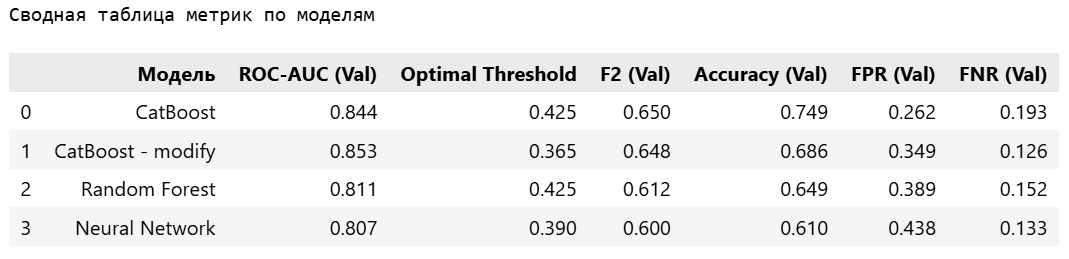

По совокупности метрик модель CatBoost (базовая версия):
- F2 (Val) = 0.650 - максимум среди всех моделей;
- Accuracy (Val) = 0.749 - максимум среди всех моделей;
- ROC-AUC (Val) = 0.844 - 2-е место среди всех моделей;
- FPR (Val) = 0.262, FNR (Val) = 0.193 - оптимальный баланс ошибок 1 и 2 рода.

**Вывод**:
- лучшей моделью признается базовая модель `CatBoost`.

### Тестирование лучшей модели

Показатели модели на тестовых данных.

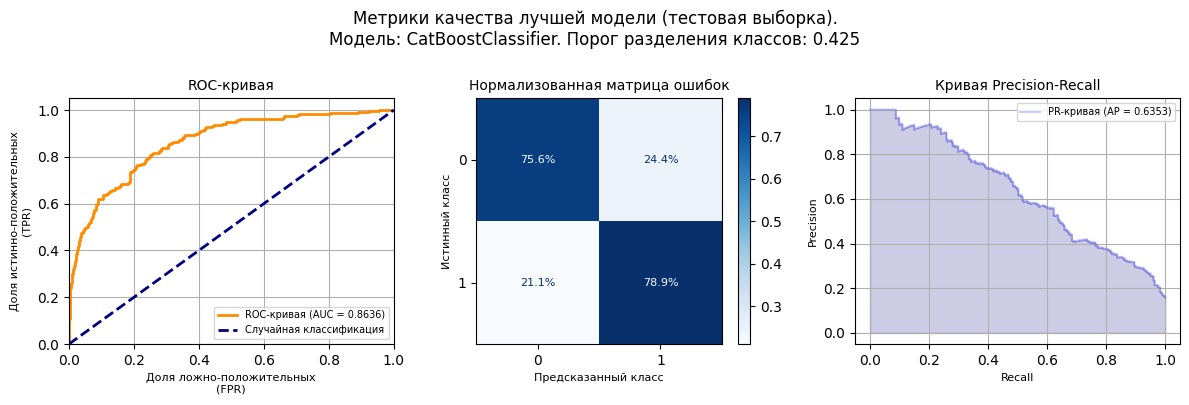

**Ключевые наблюдения**:

1. Модель не переобучилась - она обобщает хорошо.
- Все метрики на тесте выше, чем на валидации. Это хороший результат, который говорит о том, что:
 - Выбранные/сформированные вхолные признаки модели отражают устойчивые бизнес-паттерны, а не шум конкретной выборки.
 - Распределение данных в тесте хорошо соответствует обучающей выборке.
 
2. Хорошая полнота (Recall для класса 1)
- FNR 21.1% - модель хорошо "ловит" реальные оттоки абонентов; это критически важно для бизнеса.
  
3. Стабильность ложных тревог
- FPR на уровне ~24% — модель не "накручивает" F2 за счет массовых ложных срабатываний,
- модель сохраняет разумный баланс ошибок 1 и 2 рода.
  
4. Превышение целевых показателей
- ROC-AUC = 0.8636 > 0.85 (порог качества преодолен);
- F2 = 0.6470 - достаточно высокий результат для задачи с дисбалансом классов примерно 84/16.

**Выводы**:
- Модель CatBoost показала хорошую обобщающую способность: она не просто запомнила тренировочные данные, а выявила фундаментальные закономерности оттока.
- Переобучения модели не выявлено.
- ***Порог по метрике `ROC_AUC` - преодолен: `0.8636 > 0.85`***.

## Дополнительные исследования

### Важность признаков

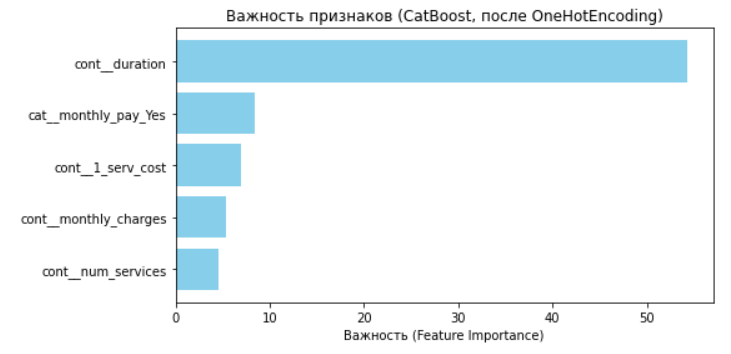

Что важно отметить:
- среди ТОП-5 по важности признаков есть:
  - ВСЕ введенные дополнительные предикторы:
    - срок договора (`duration`),
    - средние расходы на 1 услугу в месяц (`1_serv_cost`),
    - общее число услуг у абонента (`num_services`),
  - однин из преобразованых предикторов:
    - тип платежа ежемесячный Yes/No (`monthly_pay`).
- т.е. процесс Feature engineering был проведен достаточно качественно.

### Анализ признака 'duration' (срок договора)

Самым важным признаком является срок договора абонента (на момент актуальности базы данных). Были исследованы дополнительные статистики и построена визуализация по данному признаку.

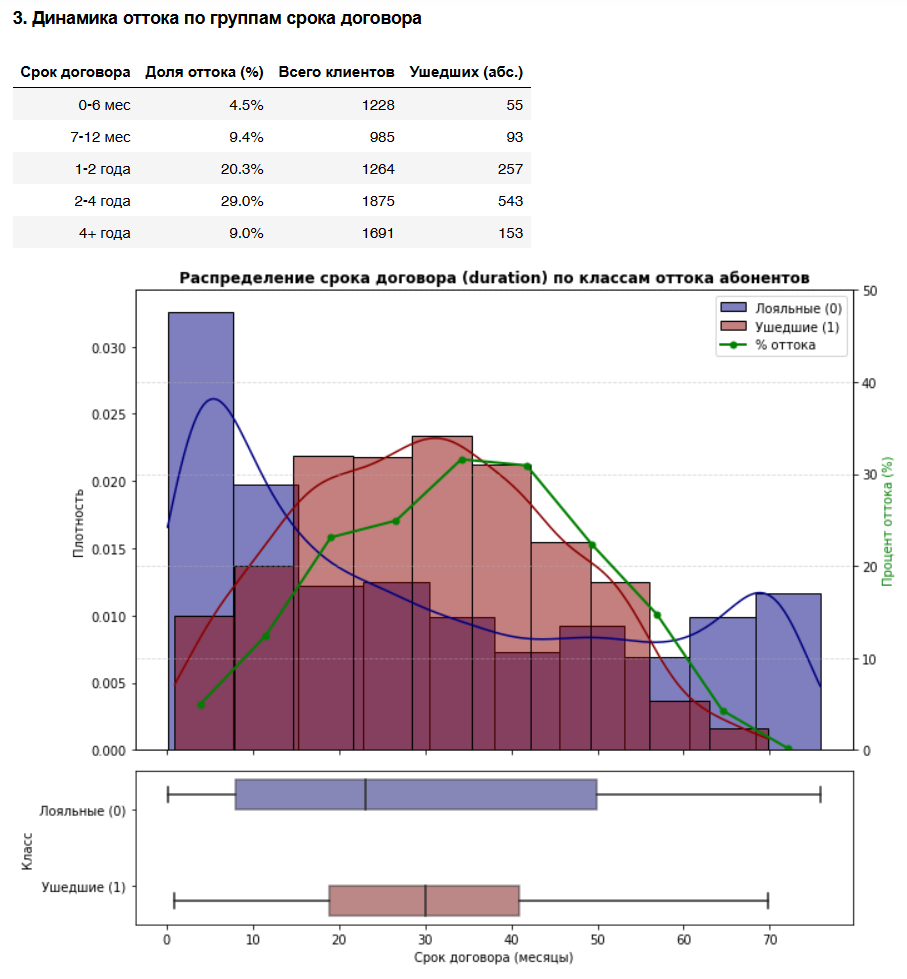

**Анализ и наблюдения**

1. Общая закономерность

- Медианный срок у ушедших клиентов ВЫШЕ, чем у лояльных:
  - Ушедшие: 30.0 месяцев
  - Лояльные: 23.0 месяца
- Средний срок у обоих групп сопоставимый:
  - Ушедшие: 30.3 месяцев
  - Лояльные: 29.3 месяца
- Это означает, что присуствует опредленная проблема, но не в "раннем оттоке", а в потере клиентов на зрелой стадии отношений.

2. U-образная кривая оттока (перевернутая)

| Период | Доля оттока | Статус |
|:------:|:-----------:|:--------|
| 0-6 мес | 4.5% | 🟢 Зона стабильности |
| 7-12 мес | 9.4% | 🟡 Низкий риск |
| 1-2 года | 20.3% | 🟠 Растущий риск |
| 2-4 года | 29.0% | 🔴 КРИТИЧЕСКАЯ ЗОНА |
| 4+ года | 9.0% | 🟢 Сверхлояльные |

Пик оттока приходится на 2-4 года обслуживания.


3. Визуальная интерпретация графика

- Гистограмма (верхний график):

  - 🔵 Синие столбцы (лояльные): Два пика — в начале (0-10 мес.) и в конце (70+ мес.). Это "новички" и "ветераны".
  - 🔴 Красные столбцы (ушедшие): Концентрируются в диапазоне 20-40 месяцев - это "середняки", которые ушли после окончания выгодных условий.
  - Зеленая линия: Четко показывает рост оттока с 4.5% до пика ~32% на сроке 35-40 месяцев, затем идет падение.
- Boxplot (нижний график):
  - У лояльных клиентов межквартильный размах шире (8-50 мес.) - они приходят и остаются надолго.
  - У ушедших клиентов размах уже (19-41 мес.) - это однородная группа "середняков".
  
---
**Бизнес-гипотезы**

1. Гипотеза 1: "Ловушка контракта"

- Клиенты заключают договоры на 1-2 года с фиксированной выгодной ценой (возможно по промо-акциям). В первые месяцы они не могут уйти по каким-то причинам (например: из-за "скрытых" штрафов - если не предусмотрен возврат средств за неиспользованный период контракта). Когда контракт подходит к концу, начинается пролонгация на менее выгодных условиях, что может давать массовый отток абонентов.

2. Гипотеза 2: "Истечение промо-периода"

- Компания привлекает клиентов акциями (например: "первые 1-2 года по сниженной цене"). После окончания акции monthly_charges (ежемесячные расходы) резко растет, и клиенты уходят к конкурентам.

## Бизнес-рекомендации

**По итогам анализа влияния срока договора на показатель оттока абонентов выработаны следующие рекомендации для бизнеса**:

1. Проактивное удержание абонентов на 18-24 месяцев (по сроку договора):

- За 3-6 месяцев до окончания "длинного" (1-2-летнего контракта) предлагать персональные скидки или апгрейд услуг.
- Внедрить триггерную рассылку: "Ваш контракт скоро истекает - вот специальное предложение".

2. Анализ ценообразования:

- Проверить, не происходит ли резкий рост monthly_charges (ежемесячные расходы) после 12-24 месяцев.
- Внедрить программу лояльности для клиентов со стажем 2+ года.

3. Сегментация "ветеранов":

- Клиенты с сроком 4+ года имеют отток всего 9% - это самая ценная группа.
- Изучить их профиль: Какие услуги они используют? Почему остаются? Масштабировать этот опыт на "группу риска" (2-4 года).